# 07 · LONG paper trades 2026 — the fixed system, simulated left to right

Every trading day of 2026 is replayed the way the live system would have run it, **one 5-minute bar at a
time**, and every trade is shown with the chart the system was looking at when it entered, and what happened next.

**No look-ahead — how it is guaranteed** (`backtester/causal_engine.py`)
* Each day starts with only history (the pre-market watchlist uses days before today).
* Bars are released from the parquet files **one at a time**; at each bar close every strategy is recomputed on
  the bars released so far — nothing is ever computed on the full day.
* Stocks are ranked on the votes cast *so far*; the entry is the close of the bar that confirmed the signal.
* After entry the position is managed on the bars that follow, one at a time (stop checked before target inside a bar).
* Section 1 **proves** it: sample days are re-run with every bar after the decision **deleted** — the trade must come
  out identical — and every trade is checked for signal ≤ decision bar < entry < exit.

**The system as it runs live, with these fixes** (all in `Config` below; change them and re-run)
| | Fixed version (this notebook) | Live today |
|---|---|---|
| stock choice | votes cast so far (like live) | same |
| entry | **at the close of the bar that confirmed the signal** | ~3 min later, after the scan |
| drift gate ("don't chase") | **off** — take the trade | skips if price ≥0.30% past the level |
| stop | **1%** (strategy stop, never farther than 1%) | same |
| target / exit | strategy target, trailing lock (+1% → trail 0.5%), square-off 14:50 | same |
| fill | **at the chosen price, full size** (liquid stocks) | book walk |
| trades | 1 LONG per day, ₹2,00,000 | same (paper sized ~₹5L) |

Costs: brokerage, STT, exchange, SEBI, GST and stamp duty; slippage 0 (section 2 also shows 0.05% per side).

**Running it**: kernel *TRAIAGENT (venv)*. The first run simulates the year on 8 worker processes
(~30–60 min) and caches each day in `reports/causal/`; later runs load the cache in seconds. Data is read from
`data/stocks/` and `data/index/` through `data_pipeline.bars.normalize_bars` (session bars 09:15–15:25, IST).

In [1]:
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT)); warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from datetime import date
from backtester.causal_engine import Config, run_period, trades_frame, verify_no_lookahead, costs
from analysis import trade_charts as tc
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30); pd.set_option("display.max_colwidth", 80)

YEAR = 2026
CFG = Config()            # e.g. Config(drift_gate_pct=0.30) for live's gate, Config(weights="uniform") for no weights
display(pd.Series(CFG.__dict__, name="config").to_frame())
END = date(YEAR, 12, 31) if YEAR < 2026 else date(2026, 9, 18)
res = run_period(date(YEAR, 1, 1), END, CFG, workers=8)
T = trades_frame(res)
T["net_pct"] = T.pnl_rs / (T.entry * T.qty) * 100
print(f"{len(res)} trading days simulated, {len(T)} trades")

,config
weights,wf5
entry,bar_close
drift_gate_pct,None
viability_gate,True
stop_pct,1.0
stop_mode,cap
target,strategy
trail,True
trail_trigger_pct,1.0
trail_pct,0.5


177 trading days simulated, 177 trades


## 1 · Proof there is no look-ahead

**Re-run test**: for a random sample of traded days, the whole day is simulated again with **every bar after the
decision bar deleted from the data**. If any decision had used a later bar, the stock, entry time or entry price
would change. **Ordering test**: for every trade, the signal bar ≤ the last bar the decision used < the entry time
< the exit time.

In [2]:
V = verify_no_lookahead(res, CFG, sample=15)
display(V)
assert V.identical.all(), "a decision changed when future bars were removed — look-ahead!"
hm = lambda s: int(s[:2]) * 60 + int(s[3:5])
ok = T.apply(lambda t: hm(t.signal_time) <= hm(t.decision_bar) < hm(t.entry_time) <= hm(t.exit_time), axis=1)
assert ok.all(), T[~ok]
print(f"re-run test: {V.identical.sum()}/{len(V)} identical | ordering test: all {len(T)} trades pass")

,date,symbol,entry_time,entry,rerun_symbol,rerun_entry_time,rerun_entry,identical
0,2026-01-16,MARICO,09:20,757.65,MARICO,09:20,757.65,True
1,2026-02-20,SAMMAANCAP,09:20,153.30,SAMMAANCAP,09:20,153.30,True
2,2026-03-23,ONGC,09:45,268.15,ONGC,09:45,268.15,True
3,2026-04-10,TATASTEEL,09:20,208.19,TATASTEEL,09:20,208.19,True
4,2026-04-21,PARADEEP,09:25,128.80,PARADEEP,09:25,128.80,True
5,2026-04-28,GRASIM,09:20,2824.00,GRASIM,09:20,2824.00,True
6,2026-05-19,URBANCO,09:25,124.12,URBANCO,09:25,124.12,True
7,2026-05-29,IFCI,09:20,69.18,IFCI,09:20,69.18,True
8,2026-06-05,JYOTICNC,09:20,611.10,JYOTICNC,09:20,611.10,True
9,2026-06-11,SAILIFE,09:25,1197.00,SAILIFE,09:25,1197.00,True


re-run test: 15/15 identical | ordering test: all 177 trades pass


## 2 · The year in numbers

trades 177 | winners 46.9% | net ₹-24,190 at ₹2L per trade | mean -0.068% per trade (t -0.91) | worst drawdown ₹-41,329
with 0.05% slippage per side instead of 0: net ₹-59,314 (-0.168% per trade)
days with no LONG trade: 0 of 177

by month


,trades,win_pct,net_rs,avg_net_pct,trading_days
month,,,,,
2026-01,20,50.0,2077,0.050,20
2026-02,21,57.1,5836,0.155,21
2026-03,19,31.6,-15299,-0.404,19
2026-04,20,35.0,-13012,-0.327,20
2026-05,19,52.6,7483,0.199,19
2026-06,21,52.4,-3825,-0.091,21
2026-07,23,39.1,-10429,-0.235,23
2026-08,21,57.1,-1134,-0.029,21
2026-09,13,46.2,4114,0.157,13


by exit reason


,trades,net_rs,avg_net_pct
exit_reason,,,
PROFIT_LOCK_STOP,65,118484.62,0.92
STOP_HIT,85,-161785.04,-0.96
TARGET_HIT,3,8018.25,1.34
TIME_EXIT,24,11091.86,0.23


by driver strategy


,trades,win_pct,net_rs,avg_net_pct
driver,,,,
CAMARILLA,77,53.25,9711.23,0.06
VPOC,53,39.62,-23940.85,-0.22
FIRST-CANDLE,37,45.95,-10618.67,-0.14
GAP-CONT,5,40.00,108.88,0.02
MACD,2,50.00,821.28,0.21
SUPERTREND,2,50.00,1325.92,0.33
STOCHASTIC,1,0.00,-1598.10,-0.80


by entry time


,trades,win_pct,avg_net_pct
entry_slot,,,
09:20-09:30,162,48.15,-0.05
09:35-09:45,15,33.33,-0.21


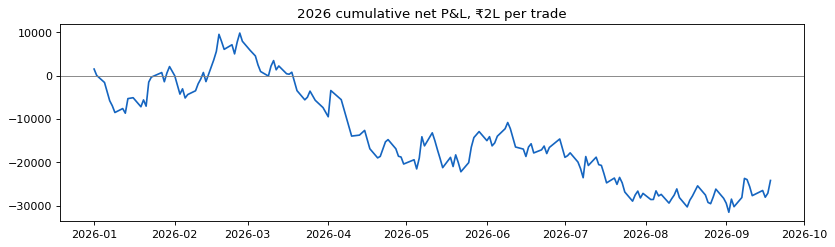

In [3]:
n = len(T); m = T.net_pct.mean(); se = T.net_pct.std() / np.sqrt(n)
eq = T.sort_values("date").pnl_rs.cumsum()
print(f"trades {n} | winners {100*(T.pnl_rs>0).mean():.1f}% | net ₹{T.pnl_rs.sum():+,.0f} at ₹2L per trade | "
      f"mean {m:+.3f}% per trade (t {m/se:+.2f}) | worst drawdown ₹{(eq - eq.cummax()).min():,.0f}")
slip = T.apply(lambda t: t.pnl_rs - costs(t.entry*t.qty, t.exit*t.qty, 0.05) + costs(t.entry*t.qty, t.exit*t.qty, 0.0), axis=1)
print(f"with 0.05% slippage per side instead of 0: net ₹{slip.sum():+,.0f} ({(slip / (T.entry*T.qty) * 100).mean():+.3f}% per trade)")
print(f"days with no LONG trade: {sum(1 for r in res if not r.get('trade'))} of {len(res)}")
print("\nby month"); display(tc.month_table(res))
print("by exit reason"); display(T.groupby("exit_reason").agg(trades=("pnl_rs","size"), net_rs=("pnl_rs","sum"), avg_net_pct=("net_pct","mean")).round(2))
print("by driver strategy"); display(T.groupby("driver").agg(trades=("pnl_rs","size"), win_pct=("pnl_rs", lambda x: 100*(x>0).mean()), net_rs=("pnl_rs","sum"), avg_net_pct=("net_pct","mean")).round(2).sort_values("trades", ascending=False))
print("by entry time"); T["entry_slot"] = pd.cut(T.entry_time.map(hm), [0, 570, 585, 600, 660, 900], labels=["09:20-09:30", "09:35-09:45", "09:50-10:00", "10:05-11:00", "after 11:00"])
display(T.groupby("entry_slot", observed=True).agg(trades=("pnl_rs","size"), win_pct=("pnl_rs", lambda x: 100*(x>0).mean()), avg_net_pct=("net_pct","mean")).round(2))
fig, ax = plt.subplots(figsize=(12, 3.2), dpi=80)
ax.plot(pd.to_datetime(T.sort_values("date").date), eq.values, color="#1565c0"); ax.axhline(0, color="grey", lw=0.8)
ax.set_title(f"{YEAR} cumulative net P&L, ₹2L per trade"); plt.show()

### Compared with what live actually traded (Jun 15 – Sep 18)
Same days, same rules except the fixes above. Live's own P&L is as sized live (~₹5L); the fixed system's is at ₹2L.
Differences in the stock picked come from live's broken inputs (volume feed, opening bar), live's drift gate and
~3-minute scan delay.

In [4]:
L = pd.read_csv(ROOT / "data" / "trade_logs" / "live_paper_trades.csv", parse_dates=["date"])
L = L[L.direction == "LONG"][["date", "symbol", "entry_time", "entry_price", "exit_reason", "pnl_rs"]]
L["date"] = L.date.dt.strftime("%Y-%m-%d")
C = T[T.date >= "2026-06-15"][["date", "symbol", "entry_time", "entry", "exit_reason", "pnl_rs", "net_pct"]]
cmp_ = L.merge(C, on="date", how="outer", suffixes=("_live", "_fixed")).sort_values("date")
cmp_["same_stock"] = cmp_.symbol_live == cmp_.symbol_fixed
display(cmp_)
print(f"same stock on {cmp_.same_stock.sum()} of {cmp_.date.nunique()} days | live net ₹{cmp_.pnl_rs_live.sum():+,.0f} (at ~₹5L) | "
      f"fixed system net ₹{cmp_.pnl_rs_fixed.sum():+,.0f} (at ₹2L, {cmp_.net_pct.mean():+.3f}% per trade)")

,date,symbol_live,entry_time_live,entry_price,exit_reason_live,pnl_rs_live,symbol_fixed,entry_time_fixed,entry,exit_reason_fixed,pnl_rs_fixed,net_pct,same_stock
0,2026-06-15,GROWW,NaN,200.096939,TARGET_HIT,12333.14,INDHOTEL,09:20,693.20,TIME_EXIT,-479.65,-0.240256,False
1,2026-06-15,STARHEALTH,NaN,524.395000,TIME_EXIT,2847.11,INDHOTEL,09:20,693.20,TIME_EXIT,-479.65,-0.240256,False
2,2026-06-16,DIXON,09:35,12206.000000,TIME_EXIT,-479.89,CDSL,09:20,1275.50,STOP_HIT,-1704.01,-0.856381,False
3,2026-06-17,CARTRADE,09:55,2606.000000,TARGET_HIT,21317.20,COFORGE,09:20,1473.30,PROFIT_LOCK_STOP,2176.20,1.094142,False
4,2026-06-18,MFSL,09:55,1657.000000,TARGET_HIT,4936.13,SYRMA,09:20,1317.00,PROFIT_LOCK_STOP,756.07,0.380189,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,2026-09-11,ATHERENERG,09:38,1651.940000,PROFIT_LOCK_STOP,1571.81,IDEA,09:35,15.12,STOP_HIT,-2103.35,-1.051716,False
66,2026-09-15,GODREJCP,09:33,872.450000,STOP_HIT,-5767.20,SAGILITY,09:25,45.83,PROFIT_LOCK_STOP,1188.65,0.594455,False
67,2026-09-16,GODREJCP,09:27,868.900000,STOP_HIT,-4434.20,GODREJCP,09:25,868.70,STOP_HIT,-1554.59,-0.778069,True
68,2026-09-17,LAURUSLABS,09:27,1933.060000,PROFIT_LOCK_STOP,3528.24,GESHIP,09:20,1403.40,PROFIT_LOCK_STOP,946.49,0.474948,False


same stock on 10 of 68 days | live net ₹-37,921 (at ~₹5L) | fixed system net ₹-6,235 (at ₹2L, -0.048% per trade)


## 3 · Every trade, month by month

For each trade: the **decision card** (the stock, the strategy that drove it and why, the signal bar, the last bar
the decision used, entry price vs the strategy's level, stop, target, which strategies voted, the higher-ranked
stocks skipped at that scan and why, the exit and the P&L), then two charts:
* **left — what the system knew at the entry**: only the bars up to the decision; yellow = the signal bar; blue dashed =
  the strategy's level; black triangle = the entry (close of the confirming bar); red / green = stop / target.
* **right — what happened after**: the trailing stop as it moved up, the exit (X); grey bars after the exit are shown for
  context only and were never used.

### January 2026

2026-01: 20 trading days, 20 trades, 10 winners, net ₹+2,077

2026-01-01  RELIANCE   driver FIRST-CANDLE — FIRST-CANDLE: break above first candle high=1579.00
  signal bar 09:20 | decided on bars up to 09:20 | ENTRY 09:25 @ 1579.50  (strategy level 1579.00, entry +0.03% vs level)
  stop 1572.30 (-0.46%)   target 1592.40 (+0.82%)   RR 1.79   rank 2
  votes: 7 agreeing, score 21.0, predicted win 49.0% — ADX-FILTER, ASC-TRI, DAILY-BIAS, DBL-BTM, FIRST-CANDLE, MACD, PDH-PDL
  higher-ranked stocks skipped at this scan: TARIL (FAIL Predicted win pct 50.3% in 50-55% danger zone)
  EXIT 09:35 @ 1592.40 (TARGET_HIT)   move +0.82%   P&L ₹+1,505 net (+0.76%) on 126 shares


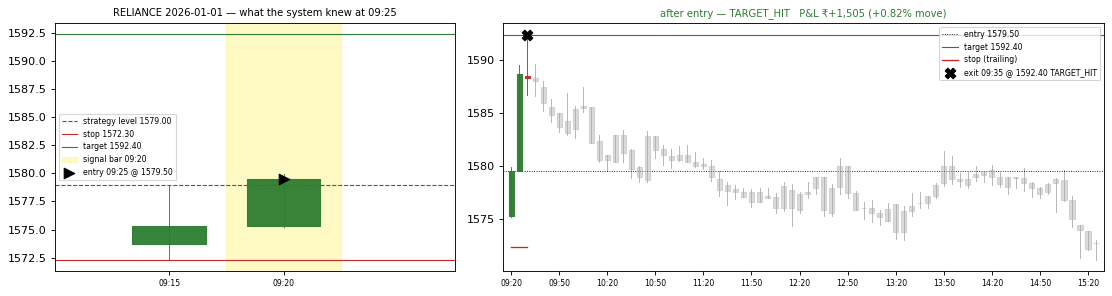


2026-01-02  MOTHERSON   driver CAMARILLA — CAMARILLA: breakout above H4=124.15
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 124.19  (strategy level 124.15, entry +0.03% vs level)
  stop 123.35 (-0.68%)   target 127.35 (+2.54%)   RR 3.76   rank 2
  votes: 7 agreeing, score 21.0, predicted win 50.0% — ADX-FILTER, ASC-TRI, CAMARILLA, DAILY-BIAS, DBL-BTM, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: SBILIFE (SKIP viability (stop 0.23x ATR < 0.3))
  EXIT 10:25 @ 123.35 (STOP_HIT)   move -0.68%   P&L ₹-1,472 net (-0.74%) on 1610 shares


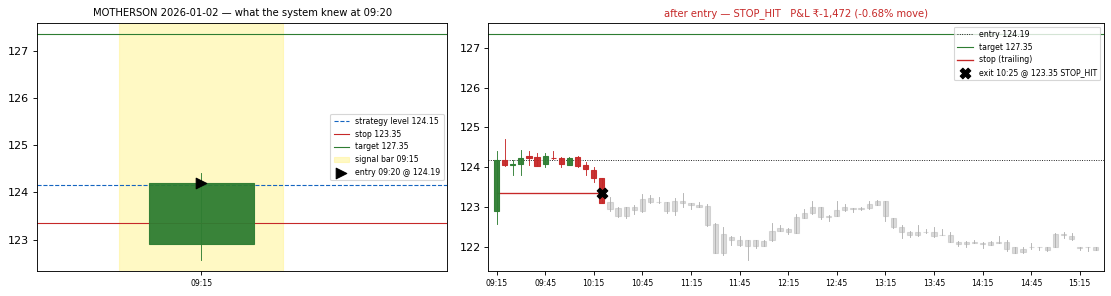


2026-01-05  ONGC   driver GAP-CONT — GAP-CONT: gap 2.0%, pullback to VWAP=239.05
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 238.90  (strategy level 239.05, entry -0.06% vs level)
  stop 237.10 (-0.75%)   target 242.95 (+1.70%)   RR 2.25   rank 6
  votes: 6 agreeing, score 18.0, predicted win 49.0% — ADX-FILTER, DAILY-BIAS, DBL-BTM, GAP-CONT, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: RELIANCE (SKIP viability (stop 0.30x ATR < 0.3)); AUBANK (SKIP RR 0.15 < 1.5 at entry price); PAYTM (SKIP RR 0.96 < 1.5 at entry price); BANKBARODA (FAIL Predicted win pct 50.3% in 50-55% danger zone)
  EXIT 09:30 @ 237.10 (STOP_HIT)   move -0.75%   P&L ₹-1,626 net (-0.81%) on 837 shares


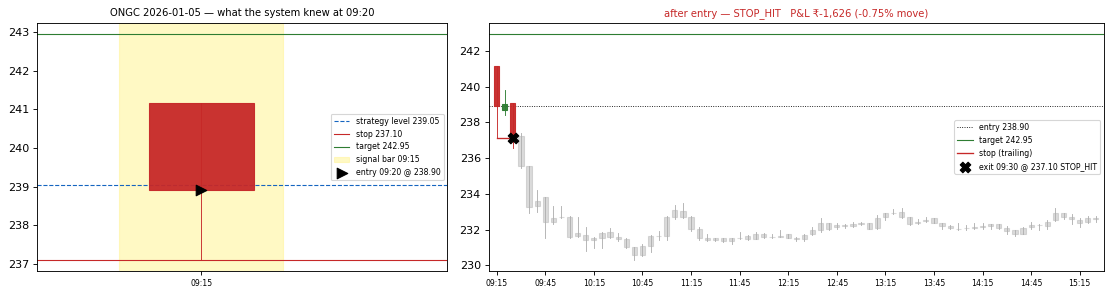


2026-01-06  GODREJPROP   driver VPOC — VPOC: breakout above VAH=2127.06
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 2128.50  (strategy level 2127.06, entry +0.07% vs level)
  stop 2107.22 (-1.00%)   target 2187.74 (+2.78%)   RR 2.34   rank 16
  votes: 4 agreeing, score 12.0, predicted win 48.7% — ADX-FILTER, DAILY-BIAS, DBL-BTM, VPOC
  higher-ranked stocks skipped at this scan: KOTAKBANK (SKIP RR 1.45 < 1.5 at entry price); MUTHOOTFIN (SKIP viability (stop 0.24x ATR < 0.3)); ICICIBANK (FAIL Predicted win pct 50.3% in 50-55% danger zone); ABCAPITAL (SKIP RR 1.34 < 1.5 at entry price)
  EXIT 11:25 @ 2107.22 (STOP_HIT)   move -1.00%   P&L ₹-2,098 net (-1.06%) on 93 shares


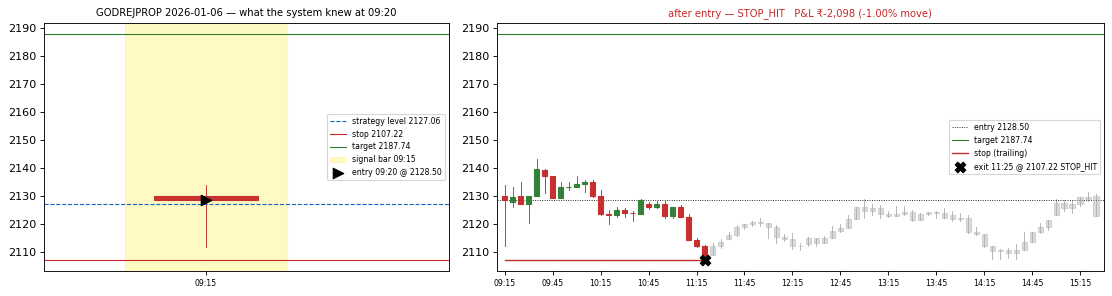


2026-01-07  KALYANKJIL   driver CAMARILLA — CAMARILLA: breakout above H4=505.63
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 508.50  (strategy level 505.63, entry +0.57% vs level)
  stop 503.42 (-1.00%)   target 517.90 (+1.85%)   RR 1.59   rank 2
  votes: 7 agreeing, score 21.0, predicted win 49.6% — ADX-FILTER, CAMARILLA, DAILY-BIAS, DBL-BTM, GAP-CONT, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: BRITANNIA (SKIP RR 0.40 < 1.5 at entry price)
  EXIT 09:30 @ 503.42 (STOP_HIT)   move -1.00%   P&L ₹-2,116 net (-1.06%) on 393 shares


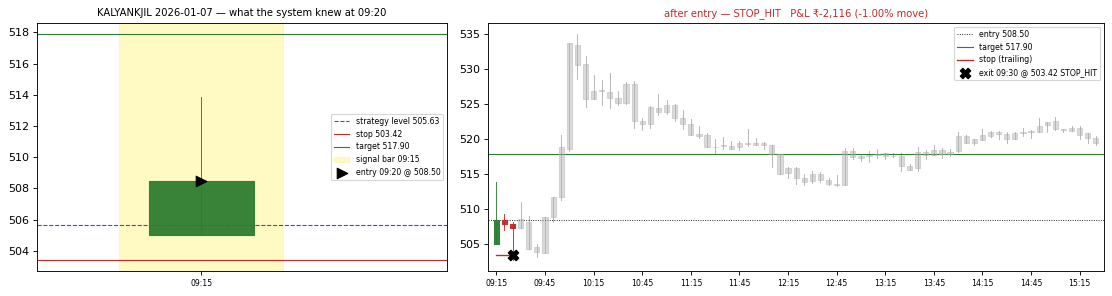


2026-01-08  HAL   driver CAMARILLA — CAMARILLA: breakout above H4=4555.80
  signal bar 09:15 | decided on bars up to 09:20 | ENTRY 09:25 @ 4564.70  (strategy level 4555.80, entry +0.20% vs level)
  stop 4540.40 (-0.53%)   target 4617.40 (+1.15%)   RR 2.17   rank 1
  votes: 8 agreeing, score 24.0, predicted win 49.8% — ADX-FILTER, CAMARILLA, CPR, DAILY-BIAS, DBL-BTM, PDH-PDL, SR-BREAK, VPOC
  higher-ranked stocks skipped at this scan: none
  EXIT 09:35 @ 4540.40 (STOP_HIT)   move -0.53%   P&L ₹-1,163 net (-0.59%) on 43 shares


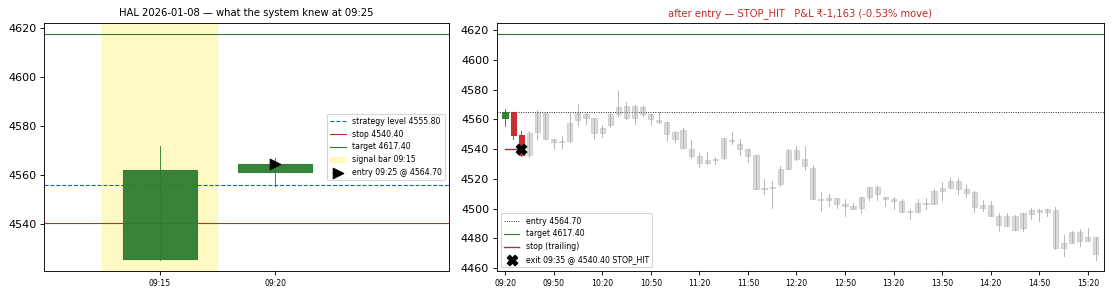


2026-01-09  IDFCFIRSTB   driver VPOC — VPOC: breakout above VAH=86.26
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 86.66  (strategy level 86.26, entry +0.46% vs level)
  stop 86.04 (-0.72%)   target 88.83 (+2.50%)   RR 3.50   rank 5
  votes: 5 agreeing, score 15.0, predicted win 49.9% — ASC-TRI, DAILY-BIAS, DBL-BTM, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: INDUSTOWER (SKIP RR 0.05 < 1.5 at entry price); ASIANPAINT (SKIP geometry (stop 0.09%, target 0.41%)); BEL (FAIL Predicted win pct 50.3% in 50-55% danger zone); IDEA (SKIP price already past stop/target)
  EXIT 09:30 @ 86.04 (STOP_HIT)   move -0.71%   P&L ₹-1,550 net (-0.78%) on 2307 shares


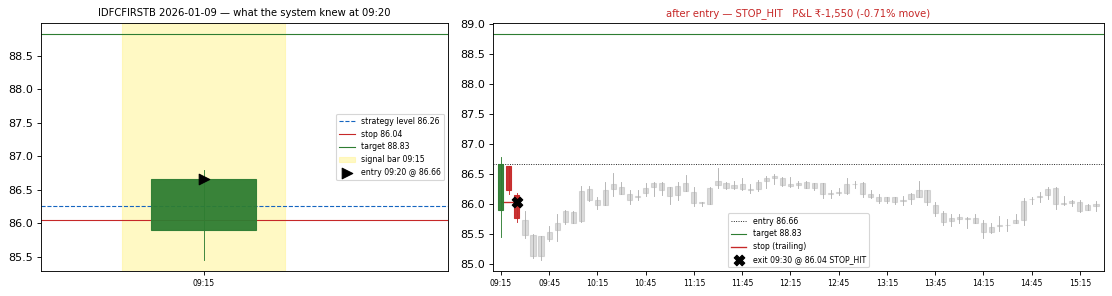


2026-01-12  AUBANK   driver FIRST-CANDLE — FIRST-CANDLE: break above first candle high=999.10
  signal bar 09:35 | decided on bars up to 09:35 | ENTRY 09:40 @ 999.90  (strategy level 999.10, entry +0.08% vs level)
  stop 992.10 (-0.78%)   target 1013.10 (+1.32%)   RR 1.69   rank 1
  votes: 6 agreeing, score 21.03, predicted win 48.2% — BOLLINGER, CAMARILLA, DAILY-BIAS, DBL-BTM, FIRST-CANDLE, PIN-BAR, RSI-EXT, VPOC
  higher-ranked stocks skipped at this scan: none
  EXIT 14:50 @ 1005.05 (TIME_EXIT)   move +0.52%   P&L ₹+910 net (+0.45%) on 200 shares


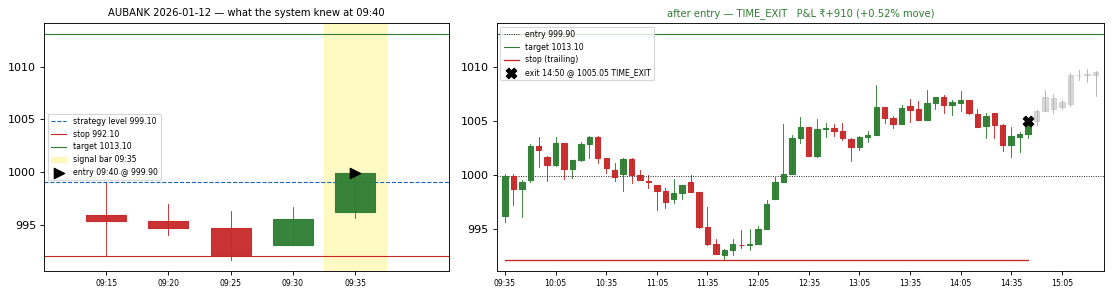


2026-01-13  HDFCBANK   driver VPOC — VPOC: breakout above VAH=940.99
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 943.60  (strategy level 940.99, entry +0.28% vs level)
  stop 939.09 (-0.48%)   target 952.12 (+0.90%)   RR 1.89   rank 13
  votes: 5 agreeing, score 15.0, predicted win 49.9% — CAMARILLA, CPR, GAP-CONT, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: AXISBANK (SKIP geometry (stop 0.07%, target 0.14%)); EICHERMOT (SKIP price already past stop/target); ASIANPAINT (SKIP geometry (stop 3.17%, target 3.17%)); HAL (SKIP RR 1.16 < 1.5 at entry price)
  EXIT 12:35 @ 939.09 (STOP_HIT)   move -0.48%   P&L ₹-1,071 net (-0.54%) on 211 shares


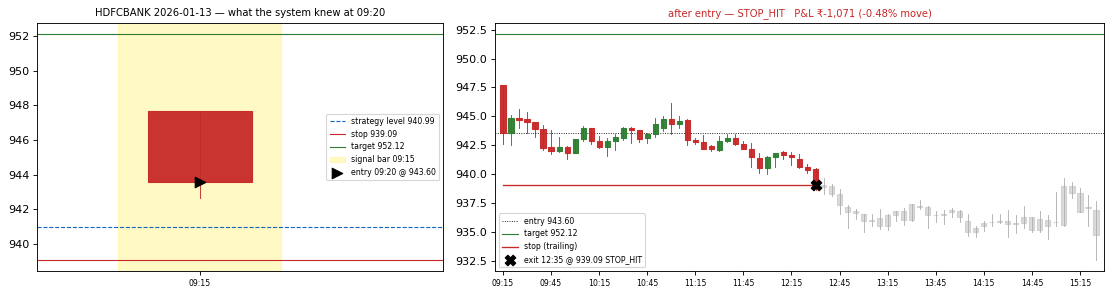


2026-01-14  INDUSTOWER   driver CAMARILLA — CAMARILLA: breakout above H4=432.69
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 433.90  (strategy level 432.69, entry +0.28% vs level)
  stop 429.85 (-0.93%)   target 444.08 (+2.35%)   RR 2.51   rank 3
  votes: 6 agreeing, score 18.0, predicted win 49.9% — ADX-FILTER, CAMARILLA, DAILY-BIAS, GAP-CONT, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: HINDZINC (SKIP RR 1.30 < 1.5 at entry price); PNB (FAIL Predicted win pct 50.3% in 50-55% danger zone)
  EXIT 11:40 @ 441.48 (PROFIT_LOCK_STOP)   move +1.75%   P&L ₹+3,366 net (+1.69%) on 460 shares


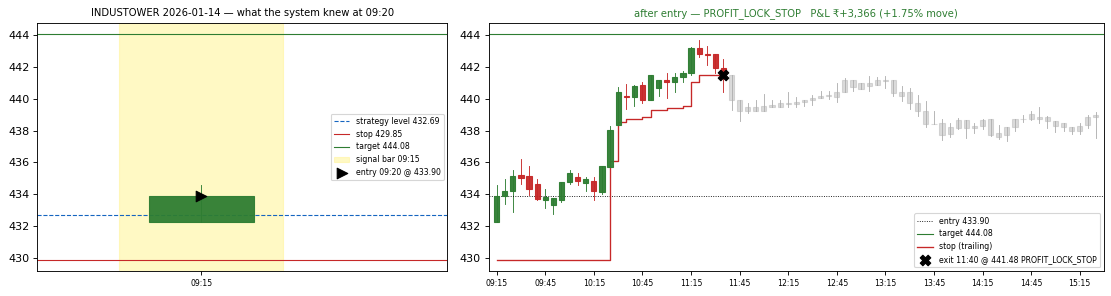


2026-01-16  MARICO   driver CAMARILLA — CAMARILLA: breakout above H4=755.22
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 757.65  (strategy level 755.22, entry +0.32% vs level)
  stop 752.11 (-0.73%)   target 767.65 (+1.32%)   RR 1.81   rank 2
  votes: 6 agreeing, score 18.0, predicted win 48.8% — ADX-FILTER, CAMARILLA, DAILY-BIAS, DBL-BTM, GAP-CONT, VPOC
  higher-ranked stocks skipped at this scan: BSE (FAIL Predicted win pct 50.2% in 50-55% danger zone)
  EXIT 14:50 @ 758.90 (TIME_EXIT)   move +0.17%   P&L ₹+209 net (+0.10%) on 263 shares


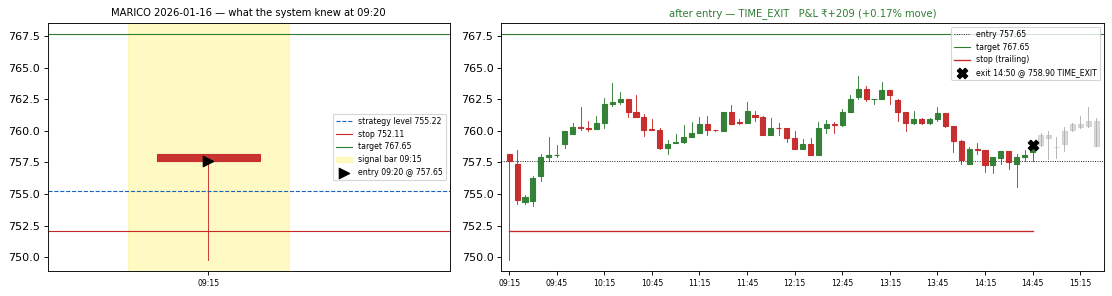


2026-01-19  POLYCAB   driver CAMARILLA — CAMARILLA: breakout above H4=7239.73
  signal bar 09:15 | decided on bars up to 09:20 | ENTRY 09:25 @ 7305.00  (strategy level 7239.73, entry +0.90% vs level)
  stop 7231.95 (-1.00%)   target 7613.18 (+4.22%)   RR 1.94   rank 6
  votes: 6 agreeing, score 18.0, predicted win 48.7% — ADX-FILTER, CAMARILLA, FIRST-CANDLE, GAP-CONT, MACD, VPOC
  higher-ranked stocks skipped at this scan: COLPAL (SKIP geometry (stop 0.03%, target 0.31%)); HINDZINC (SKIP RR 0.74 < 1.5 at entry price); TECHM (FAIL Predicted win pct 50.4% in 50-55% danger zone); AXISBANK (FAIL Predicted win pct 51.2% in 50-55% danger zone)
  EXIT 09:40 @ 7231.95 (STOP_HIT)   move -1.00%   P&L ₹-2,091 net (-1.06%) on 27 shares


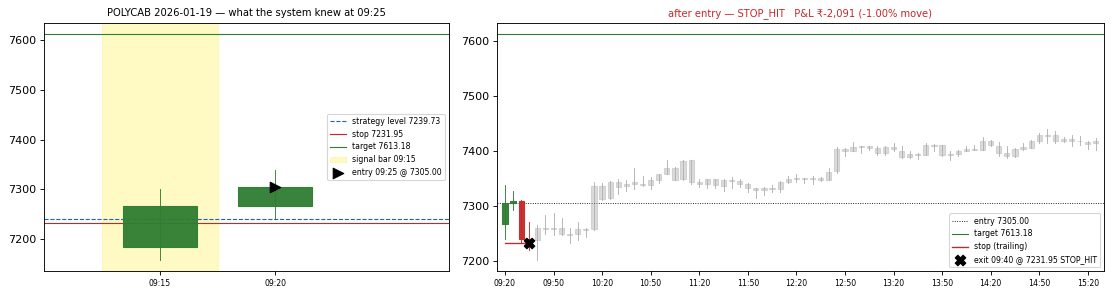


2026-01-20  DALBHARAT   driver CAMARILLA — CAMARILLA: breakout above H4=2178.11
  signal bar 09:15 | decided on bars up to 09:30 | ENTRY 09:35 @ 2194.00  (strategy level 2178.11, entry +0.73% vs level)
  stop 2172.06 (-1.00%)   target 2246.53 (+2.39%)   RR 1.59   rank 1
  votes: 10 agreeing, score 27.53, predicted win 49.0% — ADX-FILTER, ASC-TRI, CAMARILLA, DAILY-BIAS, DBL-BTM, EMA-CROSS, MACD, PDH-PDL, SR-BREAK, VPOC
  higher-ranked stocks skipped at this scan: none
  EXIT 14:50 @ 2212.70 (TIME_EXIT)   move +0.85%   P&L ₹+1,581 net (+0.79%) on 91 shares


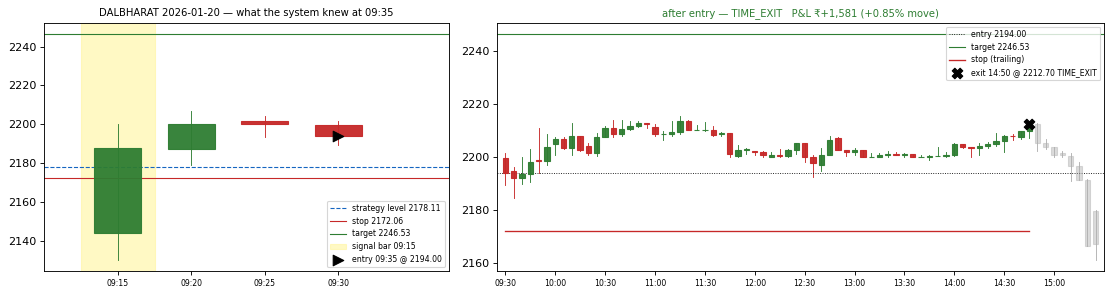


2026-01-21  SBILIFE   driver CAMARILLA — CAMARILLA: breakout above H4=2063.80
  signal bar 09:20 | decided on bars up to 09:20 | ENTRY 09:25 @ 2067.70  (strategy level 2063.80, entry +0.19% vs level)
  stop 2053.90 (-0.67%)   target 2103.40 (+1.73%)   RR 2.59   rank 4
  votes: 5 agreeing, score 15.0, predicted win 49.6% — CAMARILLA, DAILY-BIAS, FIRST-CANDLE, MACD, VPOC
  higher-ranked stocks skipped at this scan: MUTHOOTFIN (FAIL Predicted win pct 50.2% in 50-55% danger zone); PIRAMALFIN (SKIP viability (stop 0.22x ATR < 0.3)); DALBHARAT (SKIP geometry (stop 0.21%, target 0.42%))
  EXIT 10:25 @ 2053.90 (STOP_HIT)   move -0.67%   P&L ₹-1,444 net (-0.73%) on 96 shares


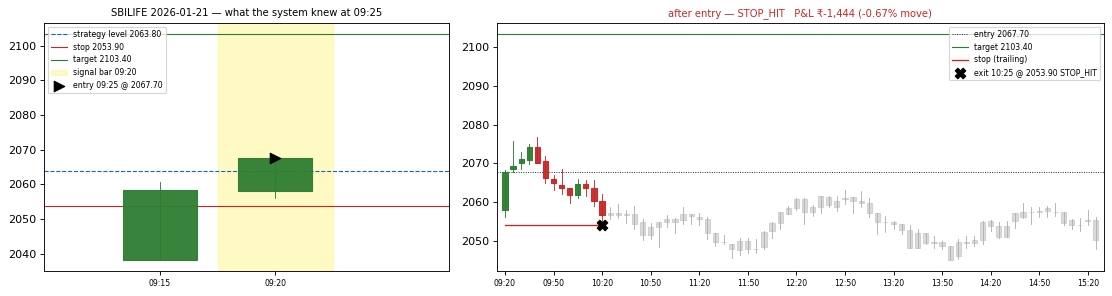


2026-01-22  SAIL   driver CAMARILLA — CAMARILLA: breakout above H4=148.52
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 148.91  (strategy level 148.52, entry +0.26% vs level)
  stop 147.42 (-1.00%)   target 152.92 (+2.69%)   RR 2.69   rank 1
  votes: 7 agreeing, score 21.0, predicted win 49.5% — ADX-FILTER, CAMARILLA, CPR, DAILY-BIAS, GAP-CONT, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: none
  EXIT 09:45 @ 153.13 (PROFIT_LOCK_STOP)   move +2.83%   P&L ₹+5,546 net (+2.77%) on 1343 shares


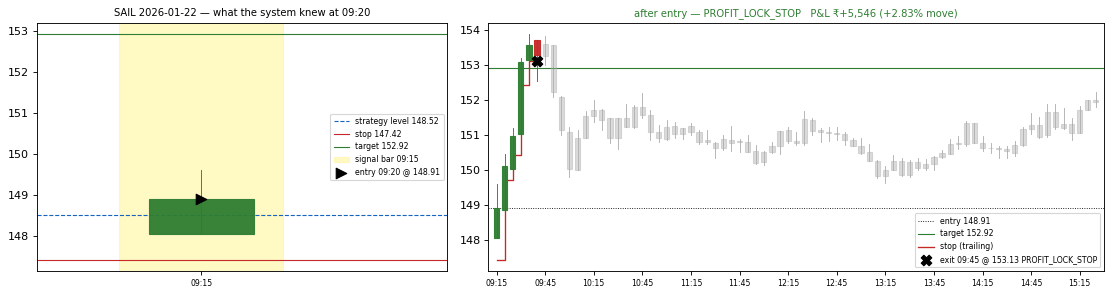


2026-01-23  HINDZINC   driver CAMARILLA — CAMARILLA: breakout above H4=687.14
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 694.95  (strategy level 687.14, entry +1.14% vs level)
  stop 688.00 (-1.00%)   target 732.63 (+5.42%)   RR 1.96   rank 1
  votes: 7 agreeing, score 21.0, predicted win 49.6% — ADX-FILTER, CAMARILLA, DAILY-BIAS, DBL-BTM, GAP-CONT, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: none
  EXIT 09:30 @ 699.39 (PROFIT_LOCK_STOP)   move +0.64%   P&L ₹+1,154 net (+0.58%) on 287 shares


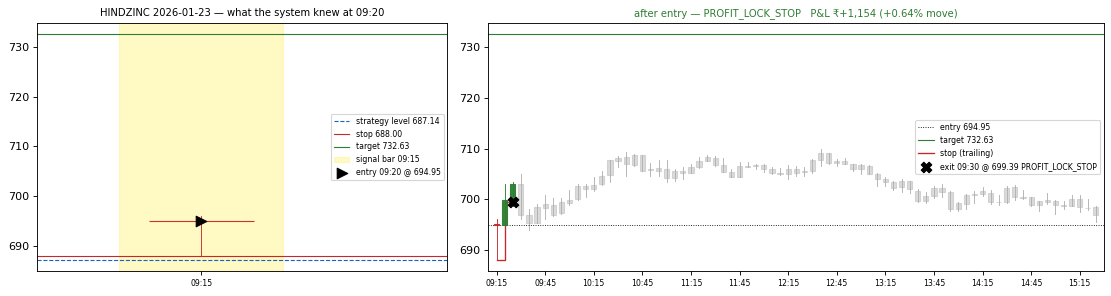


2026-01-27  VEDL   driver CAMARILLA — CAMARILLA: breakout above H4=363.66
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 366.05  (strategy level 363.66, entry +0.66% vs level)
  stop 362.39 (-1.00%)   target 373.78 (+2.11%)   RR 1.57   rank 2
  votes: 6 agreeing, score 18.0, predicted win 49.9% — ADX-FILTER, CAMARILLA, DAILY-BIAS, GAP-CONT, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: MCX (SKIP viability (stop 0.21x ATR < 0.3))
  EXIT 14:50 @ 368.20 (TIME_EXIT)   move +0.59%   P&L ₹+1,054 net (+0.53%) on 546 shares


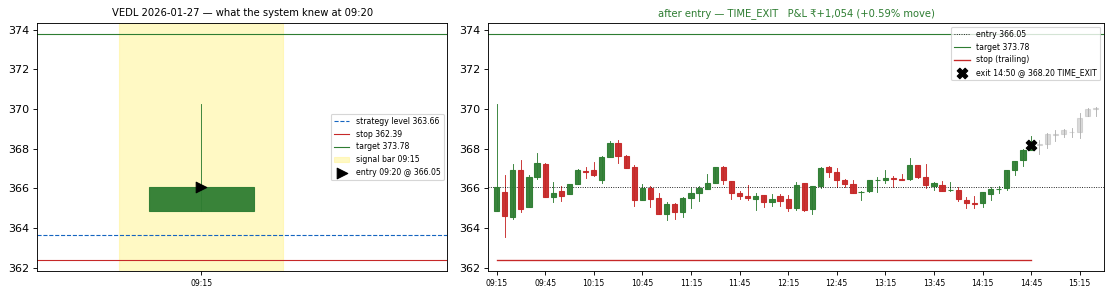


2026-01-28  AXISBANK   driver CAMARILLA — CAMARILLA: breakout above H4=1352.14
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 1359.70  (strategy level 1352.14, entry +0.56% vs level)
  stop 1346.10 (-1.00%)   target 1412.42 (+3.88%)   RR 2.33   rank 4
  votes: 6 agreeing, score 18.0, predicted win 49.8% — CAMARILLA, DAILY-BIAS, DBL-BTM, GAP-CONT, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: ANGELONE (FAIL Predicted win pct 50.3% in 50-55% danger zone); HINDCOPPER (FAIL Predicted win pct 50.3% in 50-55% danger zone); ONGC (FAIL Predicted win pct 50.3% in 50-55% danger zone)
  EXIT 10:00 @ 1346.10 (STOP_HIT)   move -1.00%   P&L ₹-2,118 net (-1.06%) on 147 shares


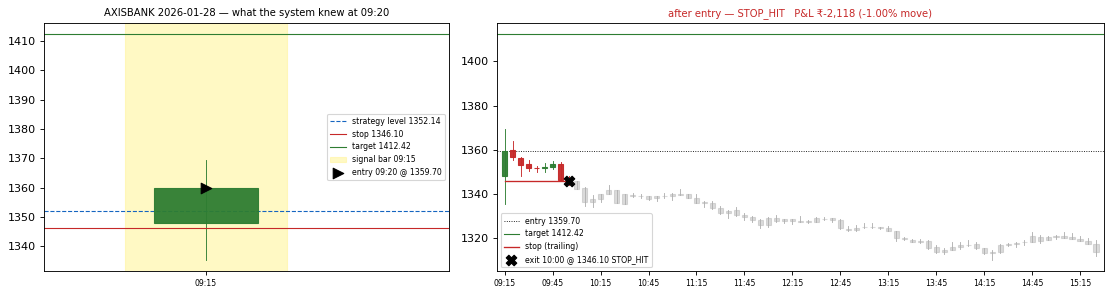


2026-01-29  SAIL   driver VPOC — VPOC: breakout above VAH=157.36
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 157.51  (strategy level 157.36, entry +0.10% vs level)
  stop 155.93 (-1.00%)   target 161.63 (+2.62%)   RR 2.10   rank 5
  votes: 6 agreeing, score 18.0, predicted win 49.4% — ASC-TRI, CPR, DAILY-BIAS, DBL-BTM, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: MUTHOOTFIN (SKIP RR 0.83 < 1.5 at entry price); GRSE (SKIP RR 1.31 < 1.5 at entry price); JSL (SKIP RR 0.47 < 1.5 at entry price); HAL (SKIP viability (stop 0.28x ATR < 0.3))
  EXIT 09:40 @ 159.20 (PROFIT_LOCK_STOP)   move +1.07%   P&L ₹+2,024 net (+1.01%) on 1269 shares


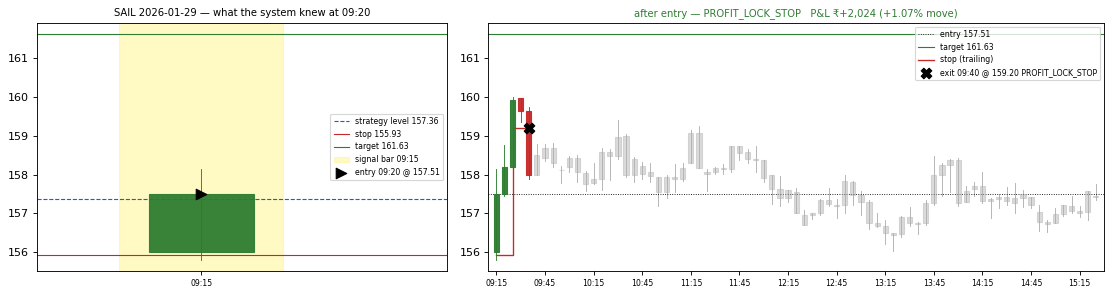


2026-01-30  FORTIS   driver FIRST-CANDLE — FIRST-CANDLE: break above first candle high=846.95
  signal bar 09:25 | decided on bars up to 09:25 | ENTRY 09:30 @ 847.10  (strategy level 846.95, entry +0.02% vs level)
  stop 838.63 (-1.00%)   target 864.85 (+2.10%)   RR 1.95   rank 10
  votes: 5 agreeing, score 12.63, predicted win 48.8% — CAMARILLA, CPR, FIRST-CANDLE, MACD, SUPERTREND
  higher-ranked stocks skipped at this scan: DIXON (FAIL Predicted win pct 50.1% in 50-55% danger zone); AXISBANK (FAIL Predicted win pct 50.1% in 50-55% danger zone); M&MFIN (SKIP geometry (stop 2.90%, target 3.84%)); NESTLEIND (FAIL Predicted win pct 51.7% in 50-55% danger zone)
  EXIT 12:05 @ 853.86 (PROFIT_LOCK_STOP)   move +0.80%   P&L ₹+1,475 net (+0.74%) on 236 shares


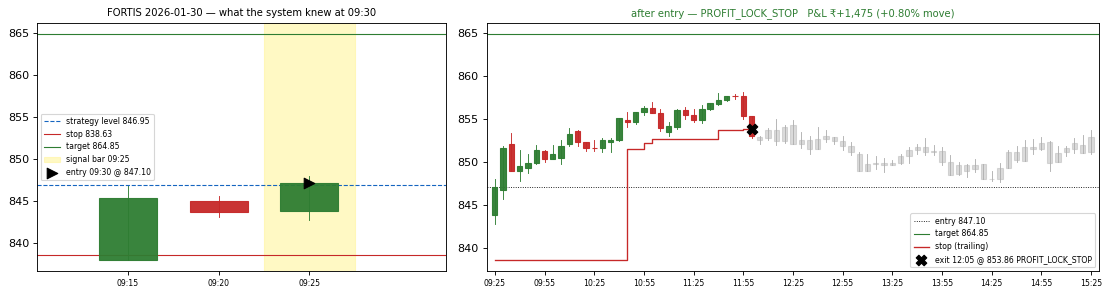

In [5]:
tc.show_month(res, "2026-01")

### February 2026

2026-02: 21 trading days, 21 trades, 12 winners, net ₹+5,836

2026-02-01  DELHIVERY   driver GAP-CONT — GAP-CONT: gap 1.4%, pullback to VWAP=428.92
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 428.75  (strategy level 428.92, entry -0.04% vs level)
  stop 424.46 (-1.00%)   target 444.75 (+3.73%)   RR 2.06   rank 4
  votes: 5 agreeing, score 15.0, predicted win 49.3% — ADX-FILTER, DAILY-BIAS, GAP-CONT, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: BAJAJ-AUTO (SKIP RR 0.13 < 1.5 at entry price); IFCI (SKIP price already past stop/target); AXISBANK (FAIL Predicted win pct 50.2% in 50-55% danger zone)
  EXIT 09:40 @ 424.46 (STOP_HIT)   move -1.00%   P&L ₹-2,118 net (-1.06%) on 466 shares


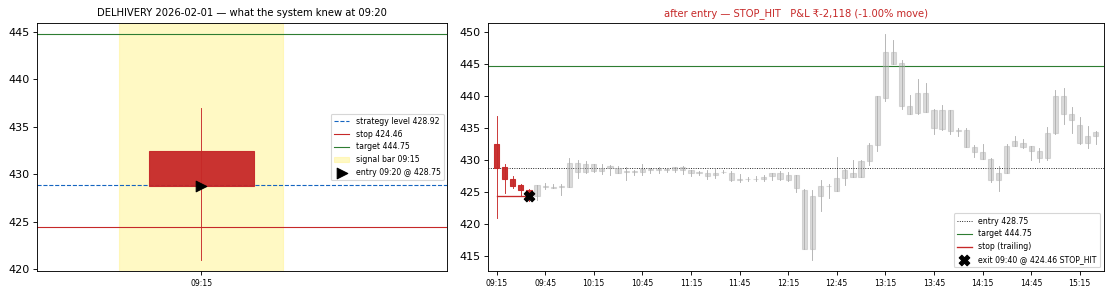


2026-02-02  BEL   driver GAP-CONT — GAP-CONT: gap 2.4%, pullback to VWAP=434.25
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 435.05  (strategy level 434.25, entry +0.18% vs level)
  stop 430.70 (-1.00%)   target 444.75 (+2.23%)   RR 1.60   rank 1
  votes: 4 agreeing, score 12.0, predicted win 47.4% — ADX-FILTER, DAILY-BIAS, DBL-BTM, GAP-CONT
  higher-ranked stocks skipped at this scan: none
  EXIT 09:30 @ 430.70 (STOP_HIT)   move -1.00%   P&L ₹-2,116 net (-1.06%) on 459 shares


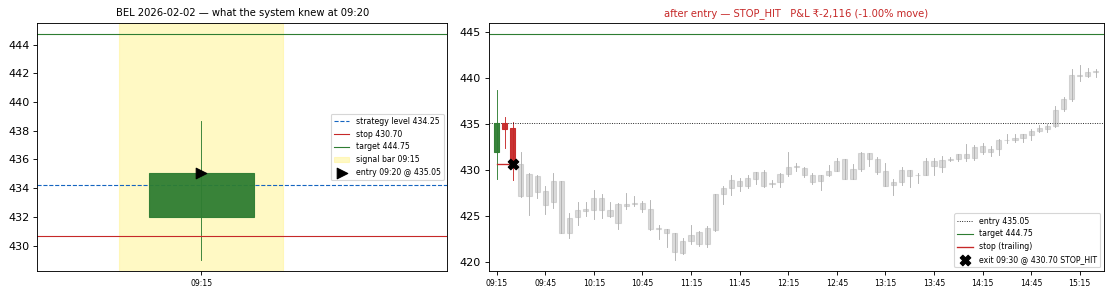


2026-02-03  SBIN   driver CAMARILLA — CAMARILLA: breakout above H4=1051.21
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 1057.70  (strategy level 1051.21, entry +0.62% vs level)
  stop 1047.12 (-1.00%)   target 1096.64 (+3.68%)   RR 2.18   rank 2
  votes: 7 agreeing, score 21.0, predicted win 49.6% — ADX-FILTER, CAMARILLA, DAILY-BIAS, DBL-BTM, GAP-CONT, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: JSWSTEEL (SKIP price already past stop/target)
  EXIT 09:40 @ 1047.12 (STOP_HIT)   move -1.00%   P&L ₹-2,119 net (-1.06%) on 189 shares


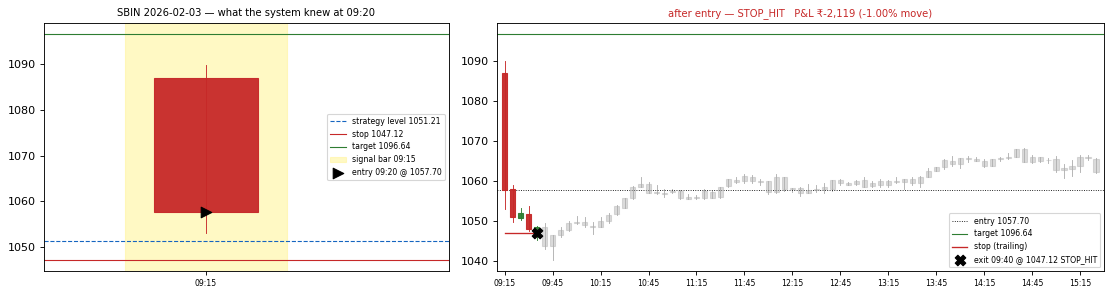


2026-02-04  IOC   driver CAMARILLA — CAMARILLA: breakout above H4=169.45
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 170.00  (strategy level 169.45, entry +0.33% vs level)
  stop 168.30 (-1.00%)   target 174.17 (+2.45%)   RR 2.41   rank 1
  votes: 7 agreeing, score 21.0, predicted win 49.9% — ADX-FILTER, CAMARILLA, CPR, DAILY-BIAS, DBL-BTM, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: none
  EXIT 09:35 @ 171.14 (PROFIT_LOCK_STOP)   move +0.67%   P&L ₹+1,220 net (+0.61%) on 1176 shares


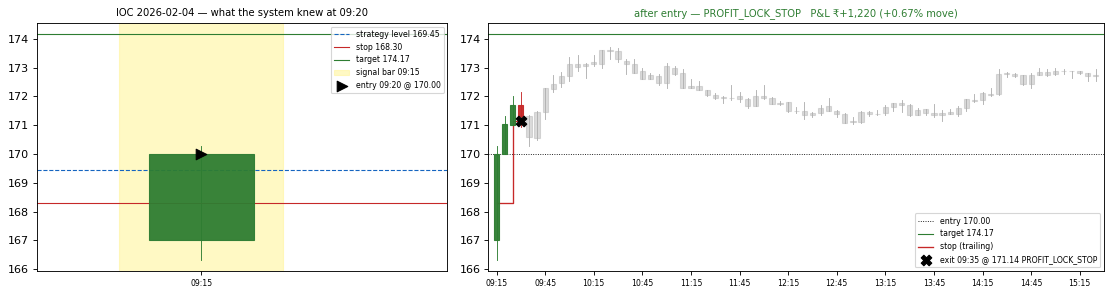


2026-02-05  SWIGGY   driver FIRST-CANDLE — FIRST-CANDLE: break above first candle high=322.80
  signal bar 09:25 | decided on bars up to 09:25 | ENTRY 09:30 @ 323.30  (strategy level 322.80, entry +0.15% vs level)
  stop 320.07 (-1.00%)   target 331.60 (+2.57%)   RR 1.69   rank 39
  votes: 4 agreeing, score 9.63, predicted win 48.5% — FIRST-CANDLE, MACD, SUPERTREND, VPOC
  higher-ranked stocks skipped at this scan: M&MFIN (FAIL Predicted win pct 51.0% in 50-55% danger zone); FORTIS (SKIP viability (stop 0.19x ATR < 0.3)); IDFCFIRSTB (SKIP price already past stop/target); CHENNPETRO (SKIP RR 0.09 < 1.5 at entry price)
  EXIT 09:50 @ 320.07 (STOP_HIT)   move -1.00%   P&L ₹-2,115 net (-1.06%) on 618 shares


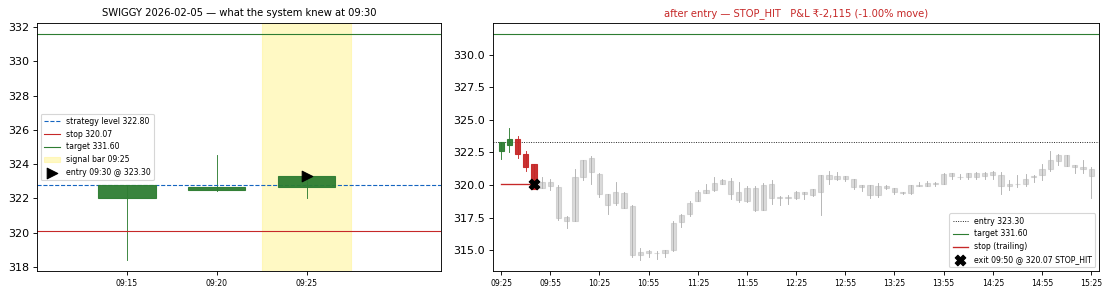


2026-02-06  MRF   driver FIRST-CANDLE — FIRST-CANDLE: break above first candle high=135850.00
  signal bar 09:20 | decided on bars up to 09:25 | ENTRY 09:30 @ 136155.00  (strategy level 135850.00, entry +0.23% vs level)
  stop 134793.45 (-1.00%)   target 140070.00 (+2.88%)   RR 1.62   rank 30
  votes: 4 agreeing, score 9.63, predicted win 47.8% — ADX-FILTER, FIRST-CANDLE, MACD, SUPERTREND
  higher-ranked stocks skipped at this scan: TMPV (FAIL Predicted win pct 50.9% in 50-55% danger zone); BAJFINANCE (SKIP price already past stop/target); IOC (FAIL Predicted win pct 50.1% in 50-55% danger zone); LICI (FAIL Predicted win pct 50.5% in 50-55% danger zone)
  EXIT 10:25 @ 137046.33 (PROFIT_LOCK_STOP)   move +0.66%   P&L ₹+794 net (+0.58%) on 1 shares


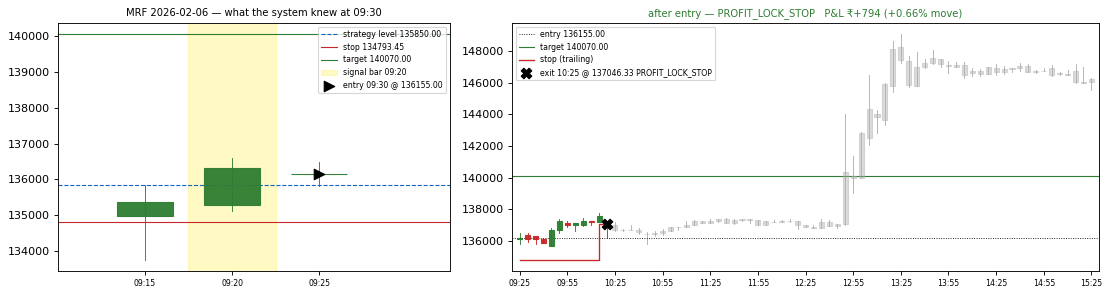


2026-02-09  MAZDOCK   driver CAMARILLA — CAMARILLA: breakout above H4=2447.49
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 2465.30  (strategy level 2447.49, entry +0.73% vs level)
  stop 2440.65 (-1.00%)   target 2538.46 (+2.97%)   RR 1.80   rank 21
  votes: 6 agreeing, score 18.0, predicted win 49.6% — ADX-FILTER, CAMARILLA, CPR, GAP-CONT, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: DRREDDY (SKIP viability (stop 0.22x ATR < 0.3)); MOTHERSON (SKIP RR 1.49 < 1.5 at entry price); BSE (SKIP RR 0.65 < 1.5 at entry price); FORCEMOT (SKIP price already past stop/target)
  EXIT 09:40 @ 2477.55 (PROFIT_LOCK_STOP)   move +0.50%   P&L ₹+872 net (+0.44%) on 81 shares


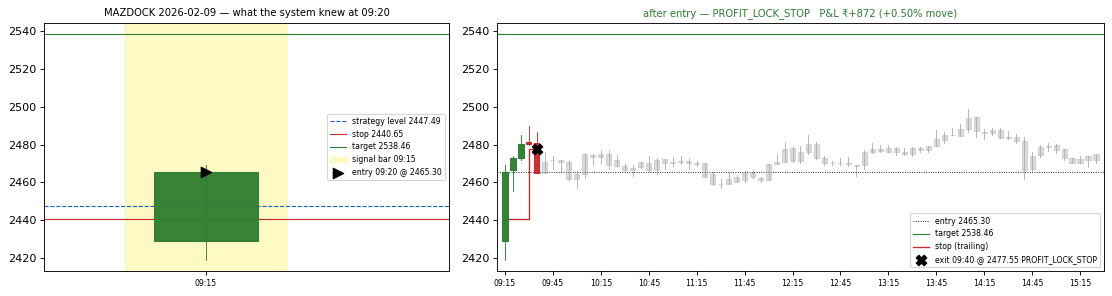


2026-02-10  NTPC   driver FIRST-CANDLE — FIRST-CANDLE: break above first candle high=364.10
  signal bar 09:20 | decided on bars up to 09:20 | ENTRY 09:25 @ 364.40  (strategy level 364.10, entry +0.08% vs level)
  stop 361.25 (-0.86%)   target 369.80 (+1.48%)   RR 1.71   rank 8
  votes: 6 agreeing, score 18.0, predicted win 48.5% — ADX-FILTER, DAILY-BIAS, DBL-BTM, FIRST-CANDLE, MACD, VPOC
  higher-ranked stocks skipped at this scan: BAJAJ-AUTO (FAIL Predicted win pct 50.7% in 50-55% danger zone); AMBER (FAIL Predicted win pct 50.4% in 50-55% danger zone); KFINTECH (FAIL Predicted win pct 50.1% in 50-55% danger zone); BANDHANBNK (FAIL Predicted win pct 50.2% in 50-55% danger zone)
  EXIT 14:50 @ 367.55 (TIME_EXIT)   move +0.86%   P&L ₹+1,606 net (+0.80%) on 548 shares


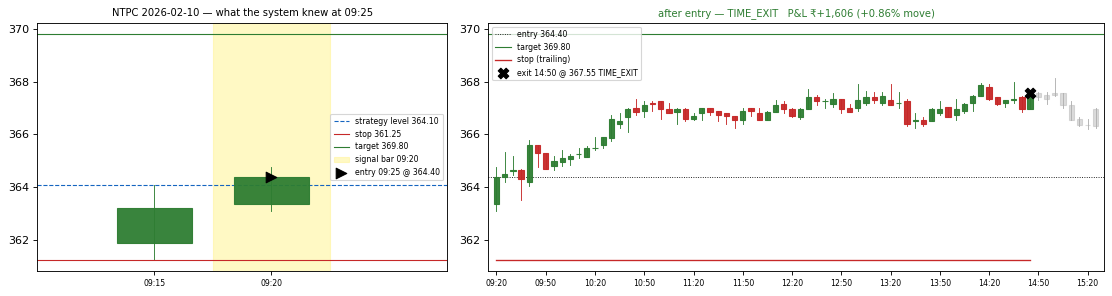


2026-02-11  JKCEMENT   driver MACD — MACD: histogram flipped positive, MACD=-11.530
  signal bar 09:20 | decided on bars up to 09:20 | ENTRY 09:25 @ 5852.50  (strategy level 5852.50, entry +0.00% vs level)
  stop 5793.98 (-1.00%)   target 5998.81 (+2.50%)   RR 1.67   rank 20
  votes: 4 agreeing, score 12.0, predicted win 46.9% — ADX-FILTER, DAILY-BIAS, DBL-BTM, MACD
  higher-ranked stocks skipped at this scan: EICHERMOT (FAIL Predicted win pct 50.4% in 50-55% danger zone); HEG (SKIP viability (stop 0.20x ATR < 0.3)); SAIL (SKIP viability (stop 0.17x ATR < 0.3)); NESTLEIND (FAIL Predicted win pct 50.2% in 50-55% danger zone)
  EXIT 13:35 @ 5888.41 (PROFIT_LOCK_STOP)   move +0.61%   P&L ₹+1,101 net (+0.55%) on 34 shares


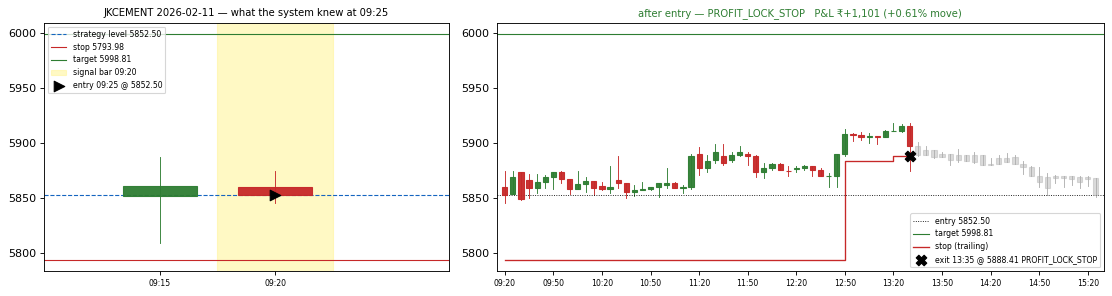


2026-02-12  BRITANNIA   driver SUPERTREND — SUPERTREND: flipped bullish, ST=5991.62
  signal bar 09:20 | decided on bars up to 09:20 | ENTRY 09:25 @ 6045.00  (strategy level 6045.00, entry +0.00% vs level)
  stop 5984.55 (-1.00%)   target 6175.73 (+2.16%)   RR 2.00   rank 22
  votes: 4 agreeing, score 9.63, predicted win 48.0% — ADX-FILTER, DAILY-BIAS, DBL-BTM, SUPERTREND
  higher-ranked stocks skipped at this scan: ICICIBANK (FAIL Predicted win pct 50.4% in 50-55% danger zone); NTPC (FAIL Predicted win pct 50.2% in 50-55% danger zone); JSWSTEEL (SKIP geometry (stop 3.79%, target 9.18%)); EICHERMOT (FAIL Predicted win pct 50.2% in 50-55% danger zone)
  EXIT 10:45 @ 6094.38 (PROFIT_LOCK_STOP)   move +0.82%   P&L ₹+1,509 net (+0.76%) on 33 shares


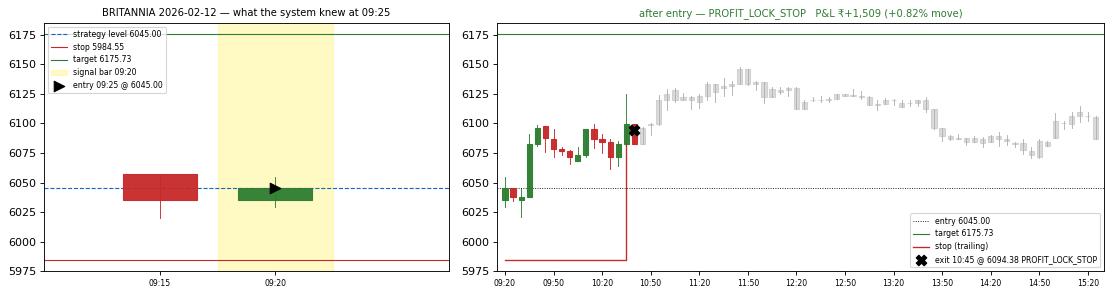


2026-02-13  BHARATFORG   driver VPOC — VPOC: breakout above VAH=1745.69
  signal bar 09:15 | decided on bars up to 09:25 | ENTRY 09:30 @ 1755.90  (strategy level 1745.69, entry +0.58% vs level)
  stop 1738.34 (-1.00%)   target 1854.97 (+5.64%)   RR 2.33   rank 6
  votes: 5 agreeing, score 15.0, predicted win 49.3% — ADX-FILTER, DAILY-BIAS, GAP-CONT, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: TORNTPOWER (SKIP RR 1.06 < 1.5 at entry price); MAXHEALTH (FAIL Predicted win pct 50.9% in 50-55% danger zone); CUMMINSIND (SKIP viability (stop 0.15x ATR < 0.3)); MFSL (FAIL Predicted win pct 51.0% in 50-55% danger zone)
  EXIT 09:40 @ 1738.34 (STOP_HIT)   move -1.00%   P&L ₹-2,103 net (-1.06%) on 113 shares


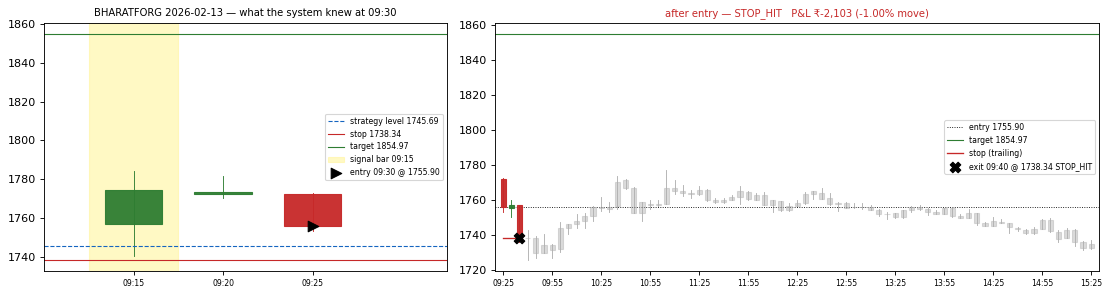


2026-02-16  FORCEMOT   driver VPOC — VPOC: breakout above VAH=24014.20
  signal bar 09:20 | decided on bars up to 09:20 | ENTRY 09:25 @ 24119.00  (strategy level 24014.20, entry +0.44% vs level)
  stop 23877.81 (-1.00%)   target 24840.73 (+2.99%)   RR 1.57   rank 12
  votes: 5 agreeing, score 15.0, predicted win 48.7% — ADX-FILTER, DAILY-BIAS, FIRST-CANDLE, MACD, VPOC
  higher-ranked stocks skipped at this scan: TORNTPHARM (FAIL Predicted win pct 50.1% in 50-55% danger zone); DATAPATTNS (SKIP geometry (stop 3.03%, target 6.05%)); CGPOWER (SKIP viability (stop 0.17x ATR < 0.3)); SYRMA (FAIL Predicted win pct 50.2% in 50-55% danger zone)
  EXIT 09:40 @ 24759.58 (PROFIT_LOCK_STOP)   move +2.66%   P&L ₹+5,006 net (+2.59%) on 8 shares


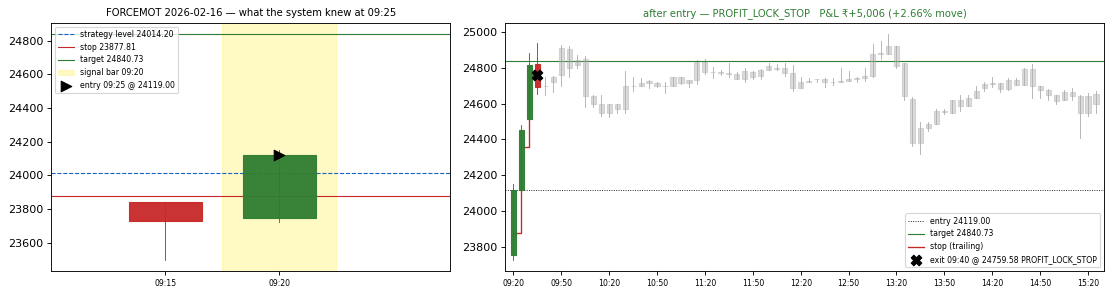


2026-02-17  AMBER   driver FIRST-CANDLE — FIRST-CANDLE: break above first candle high=7769.50
  signal bar 09:20 | decided on bars up to 09:25 | ENTRY 09:30 @ 7786.00  (strategy level 7769.50, entry +0.21% vs level)
  stop 7708.14 (-1.00%)   target 7936.50 (+1.93%)   RR 1.50   rank 2
  votes: 7 agreeing, score 18.63, predicted win 49.1% — CAMARILLA, CPR, DAILY-BIAS, FIRST-CANDLE, MACD, SUPERTREND, VPOC
  higher-ranked stocks skipped at this scan: HDFCAMC (FAIL Predicted win pct 50.3% in 50-55% danger zone)
  EXIT 10:45 @ 7869.45 (PROFIT_LOCK_STOP)   move +1.07%   P&L ₹+1,968 net (+1.01%) on 25 shares


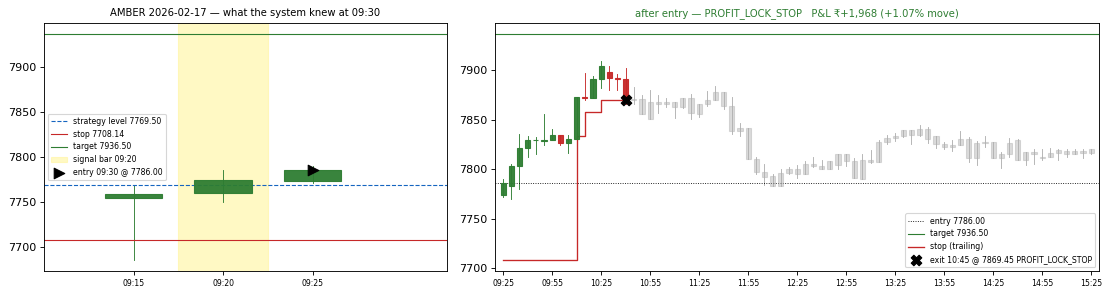


2026-02-18  COLPAL   driver VPOC — VPOC: breakout above VAH=2154.94
  signal bar 09:15 | decided on bars up to 09:20 | ENTRY 09:25 @ 2161.00  (strategy level 2154.94, entry +0.28% vs level)
  stop 2142.40 (-0.86%)   target 2189.56 (+1.32%)   RR 1.54   rank 15
  votes: 5 agreeing, score 15.0, predicted win 49.5% — ADX-FILTER, CPR, DAILY-BIAS, FIRST-CANDLE, VPOC
  higher-ranked stocks skipped at this scan: GODREJPROP (FAIL Predicted win pct 50.2% in 50-55% danger zone); POWERINDIA (FAIL Predicted win pct 50.8% in 50-55% danger zone); JSWSTEEL (FAIL Predicted win pct 50.7% in 50-55% danger zone); MARICO (FAIL Predicted win pct 50.7% in 50-55% danger zone)
  EXIT 14:50 @ 2205.00 (TIME_EXIT)   move +2.04%   P&L ₹+3,927 net (+1.98%) on 92 shares


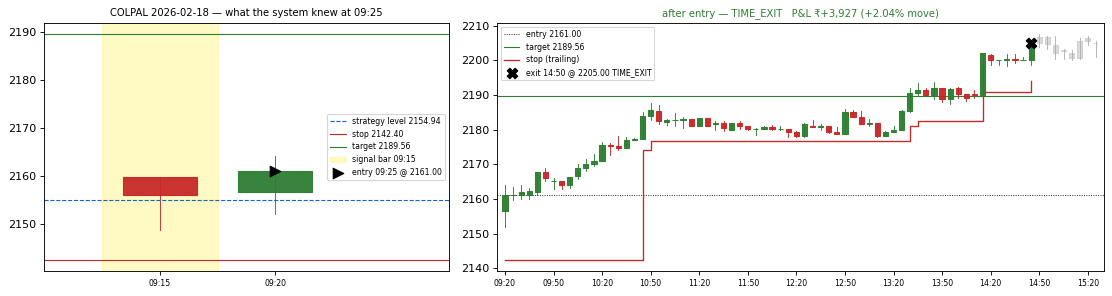


2026-02-19  COLPAL   driver VPOC — VPOC: breakout above VAH=2206.40
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 2219.30  (strategy level 2206.40, entry +0.58% vs level)
  stop 2202.19 (-0.77%)   target 2258.09 (+1.75%)   RR 2.27   rank 2
  votes: 6 agreeing, score 18.0, predicted win 49.5% — ADX-FILTER, ASC-TRI, DAILY-BIAS, DBL-BTM, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: SAMMAANCAP (SKIP RR 0.78 < 1.5 at entry price)
  EXIT 11:30 @ 2202.19 (STOP_HIT)   move -0.77%   P&L ₹-1,659 net (-0.83%) on 90 shares


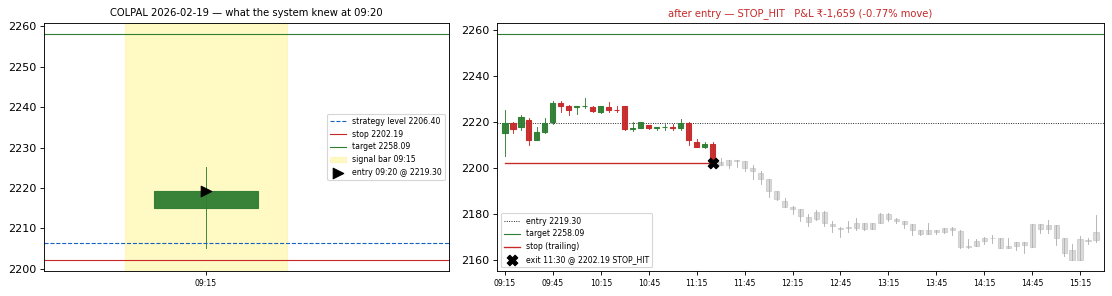


2026-02-20  SAMMAANCAP   driver CAMARILLA — CAMARILLA: breakout above H4=152.82
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 153.30  (strategy level 152.82, entry +0.31% vs level)
  stop 152.01 (-0.84%)   target 156.07 (+1.81%)   RR 2.15   rank 1
  votes: 7 agreeing, score 21.0, predicted win 50.0% — ADX-FILTER, ASC-TRI, CAMARILLA, DAILY-BIAS, DBL-BTM, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: none
  EXIT 09:30 @ 152.01 (STOP_HIT)   move -0.84%   P&L ₹-1,802 net (-0.90%) on 1304 shares


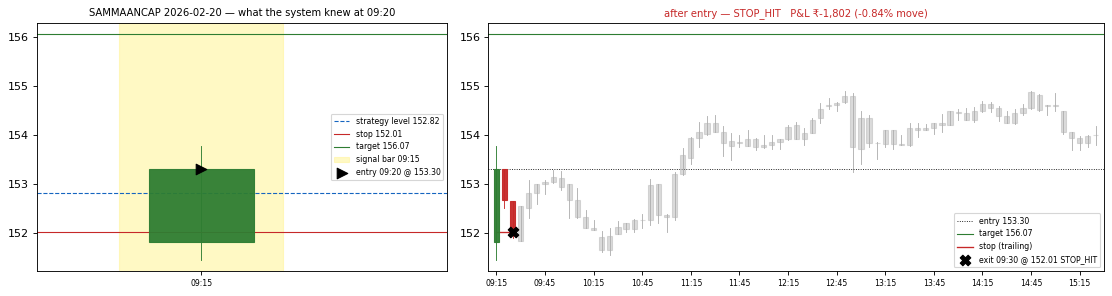


2026-02-23  BAJAJHLDNG   driver VPOC — VPOC: breakout above VAH=11200.59
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 11234.00  (strategy level 11200.59, entry +0.30% vs level)
  stop 11148.63 (-0.76%)   target 11424.84 (+1.70%)   RR 2.24   rank 7
  votes: 5 agreeing, score 15.0, predicted win 49.7% — CPR, DAILY-BIAS, DBL-BTM, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: AXISBANK (SKIP RR 0.43 < 1.5 at entry price); LTF (FAIL Predicted win pct 50.2% in 50-55% danger zone); MAXHEALTH (SKIP RR 1.37 < 1.5 at entry price); APOLLOHOSP (SKIP RR 0.61 < 1.5 at entry price)
  EXIT 12:10 @ 11303.20 (PROFIT_LOCK_STOP)   move +0.62%   P&L ₹+1,059 net (+0.55%) on 17 shares


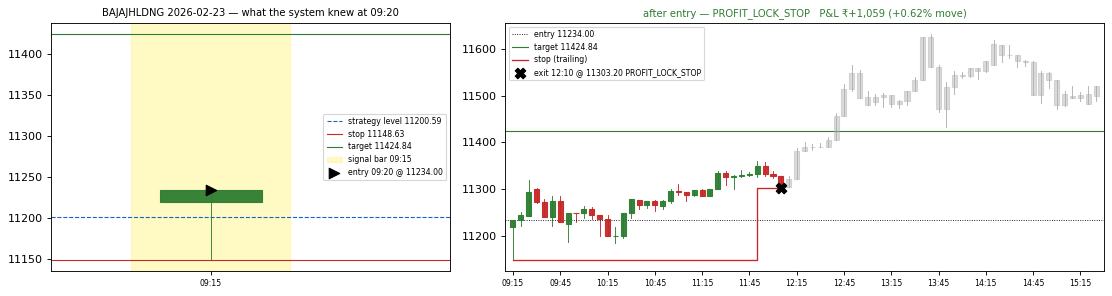


2026-02-24  ICICIAMC   driver VPOC — VPOC: breakout above VAH=3137.03
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 3154.00  (strategy level 3137.03, entry +0.54% vs level)
  stop 3122.46 (-1.00%)   target 3249.61 (+3.03%)   RR 2.33   rank 4
  votes: 6 agreeing, score 18.0, predicted win 49.5% — ADX-FILTER, ASC-TRI, DAILY-BIAS, DBL-BTM, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: NTPC (SKIP viability (stop 0.20x ATR < 0.3)); PETRONET (SKIP viability (stop 0.16x ATR < 0.3)); KARURVYSYA (FAIL Predicted win pct 50.4% in 50-55% danger zone)
  EXIT 09:40 @ 3122.46 (STOP_HIT)   move -1.00%   P&L ₹-2,106 net (-1.06%) on 63 shares


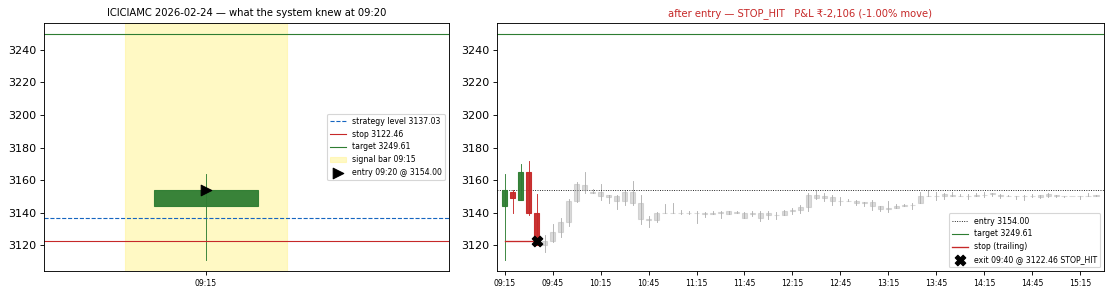


2026-02-25  KEI   driver CAMARILLA — CAMARILLA: breakout above H4=4831.55
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 4845.30  (strategy level 4831.55, entry +0.28% vs level)
  stop 4800.77 (-0.92%)   target 4954.64 (+2.26%)   RR 2.46   rank 1
  votes: 7 agreeing, score 21.0, predicted win 49.5% — ADX-FILTER, CAMARILLA, CPR, DAILY-BIAS, GAP-CONT, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: none
  EXIT 11:05 @ 4914.21 (PROFIT_LOCK_STOP)   move +1.42%   P&L ₹+2,705 net (+1.36%) on 41 shares


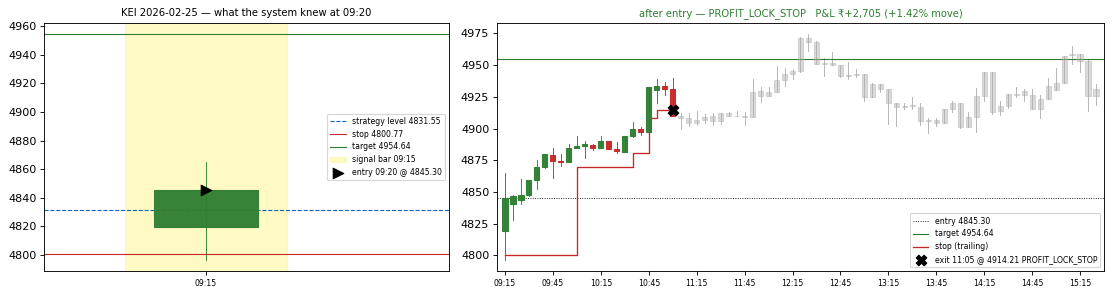


2026-02-26  LUPIN   driver VPOC — VPOC: breakout above VAH=2295.12
  signal bar 09:20 | decided on bars up to 09:25 | ENTRY 09:30 @ 2306.00  (strategy level 2295.12, entry +0.47% vs level)
  stop 2292.83 (-0.57%)   target 2331.77 (+1.12%)   RR 1.96   rank 20
  votes: 5 agreeing, score 15.0, predicted win 50.0% — DAILY-BIAS, FIRST-CANDLE, MACD, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: INDUSINDBK (FAIL Predicted win pct 50.3% in 50-55% danger zone); BANDHANBNK (FAIL Predicted win pct 50.2% in 50-55% danger zone); BANKINDIA (FAIL Predicted win pct 50.9% in 50-55% danger zone); GVT&D (SKIP geometry (stop 10.00%, target 30.58%))
  EXIT 09:50 @ 2331.77 (TARGET_HIT)   move +1.12%   P&L ₹+2,096 net (+1.06%) on 86 shares


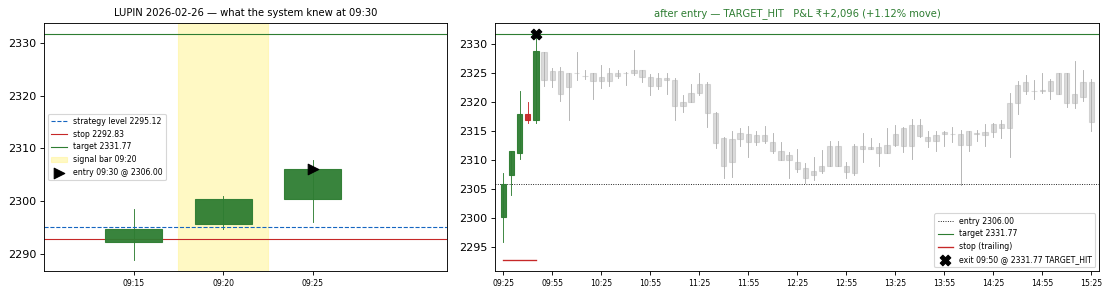


2026-02-27  TMPV   driver VPOC — VPOC: breakout above VAH=392.22
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 392.60  (strategy level 392.22, entry +0.10% vs level)
  stop 389.12 (-0.89%)   target 399.23 (+1.69%)   RR 1.91   rank 6
  votes: 4 agreeing, score 12.0, predicted win 48.8% — ASC-TRI, DAILY-BIAS, DBL-BTM, VPOC
  higher-ranked stocks skipped at this scan: BHARATFORG (FAIL RR=1.37 < 1.5); TVSMOTOR (SKIP RR 0.72 < 1.5 at entry price); ASHOKLEY (SKIP geometry (stop 0.01%, target 0.47%)); GVT&D (SKIP viability (stop 0.08x ATR < 0.3))
  EXIT 09:45 @ 389.12 (STOP_HIT)   move -0.89%   P&L ₹-1,891 net (-0.95%) on 509 shares


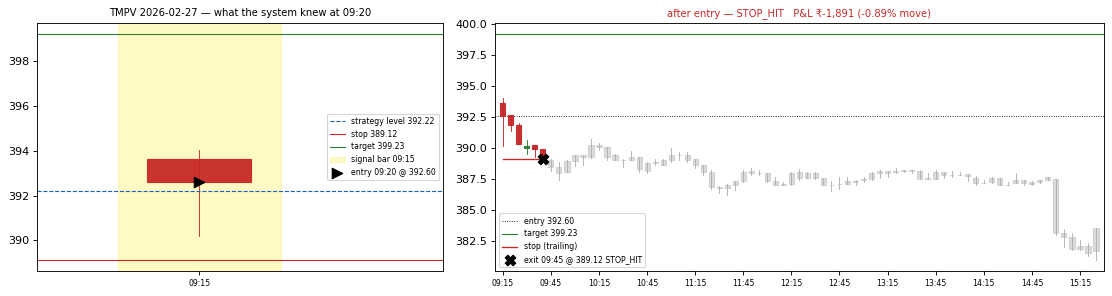

In [6]:
tc.show_month(res, "2026-02")

### March 2026

2026-03: 19 trading days, 19 trades, 6 winners, net ₹-15,299

2026-03-02  COLPAL   driver FIRST-CANDLE — FIRST-CANDLE: break above first candle high=2236.20
  signal bar 09:30 | decided on bars up to 09:35 | ENTRY 09:40 @ 2236.50  (strategy level 2236.20, entry +0.01% vs level)
  stop 2214.13 (-1.00%)   target 2311.00 (+3.33%)   RR 1.98   rank 12
  votes: 5 agreeing, score 17.53, predicted win 48.3% — BOLLINGER, CAMARILLA, DAILY-BIAS, DBL-BTM, FIRST-CANDLE, SR-BREAK
  higher-ranked stocks skipped at this scan: SAIL (SKIP geometry (stop 3.56%, target 7.12%)); MCX (SKIP geometry (stop 5.65%, target 15.03%)); JBCHEPHARM (SKIP RR 0.91 < 1.5 at entry price); BDL (SKIP geometry (stop 5.16%, target 10.33%))
  EXIT 12:20 @ 2214.13 (STOP_HIT)   move -1.00%   P&L ₹-2,110 net (-1.06%) on 89 shares


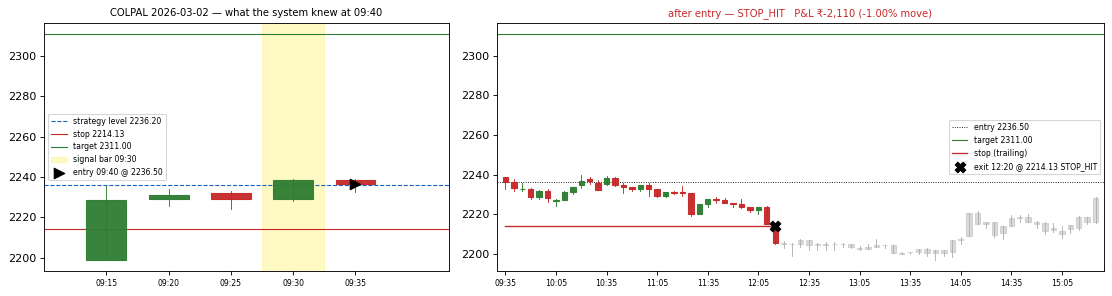


2026-03-04  BEL   driver VPOC — VPOC: breakout above VAH=454.56
  signal bar 09:15 | decided on bars up to 09:40 | ENTRY 09:45 @ 454.90  (strategy level 454.56, entry +0.07% vs level)
  stop 452.26 (-0.58%)   target 460.07 (+1.14%)   RR 1.96   rank 7
  votes: 6 agreeing, score 18.0, predicted win 47.3% — ADX-FILTER, ASC-TRI, DAILY-BIAS, GAP-CONT, STOCHASTIC, VPOC
  higher-ranked stocks skipped at this scan: OLAELEC (SKIP price already past stop/target); LGEINDIA (FAIL Predicted win pct 50.6% in 50-55% danger zone); SOLARINDS (SKIP geometry (stop 2.50%, target 4.99%)); NATCOPHARM (FAIL Predicted win pct 51.0% in 50-55% danger zone)
  EXIT 10:05 @ 452.26 (STOP_HIT)   move -0.58%   P&L ₹-1,278 net (-0.64%) on 439 shares


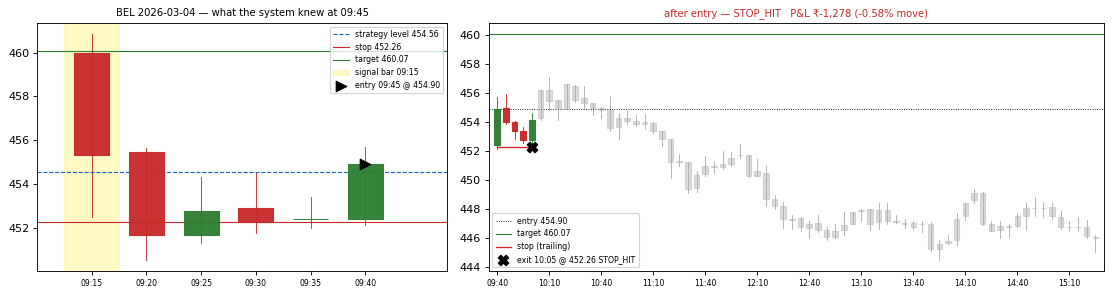


2026-03-05  SOLARINDS   driver CAMARILLA — CAMARILLA: breakout above H4=14933.50
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 14943.00  (strategy level 14933.50, entry +0.06% vs level)
  stop 14793.57 (-1.00%)   target 15604.50 (+4.43%)   RR 3.73   rank 3
  votes: 6 agreeing, score 18.0, predicted win 49.9% — ADX-FILTER, CAMARILLA, DAILY-BIAS, GAP-CONT, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: GVT&D (SKIP RR 1.14 < 1.5 at entry price); BHARATFORG (SKIP RR 0.72 < 1.5 at entry price)
  EXIT 09:30 @ 14793.57 (STOP_HIT)   move -1.00%   P&L ₹-2,060 net (-1.06%) on 13 shares


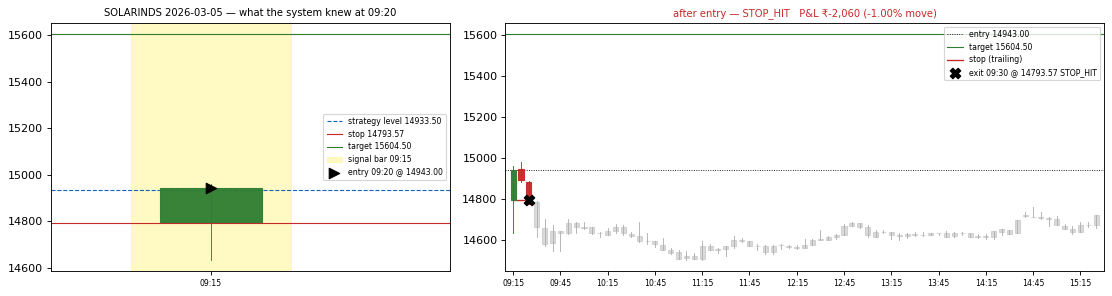


2026-03-06  CIPLA   driver FIRST-CANDLE — FIRST-CANDLE: break above first candle high=1329.50
  signal bar 09:20 | decided on bars up to 09:20 | ENTRY 09:25 @ 1330.50  (strategy level 1329.50, entry +0.07% vs level)
  stop 1321.10 (-0.71%)   target 1346.30 (+1.19%)   RR 1.68   rank 47
  votes: 4 agreeing, score 12.0, predicted win 49.0% — CAMARILLA, CPR, FIRST-CANDLE, MACD
  higher-ranked stocks skipped at this scan: BELRISE (SKIP price already past stop/target); DIVISLAB (FAIL Predicted win pct 50.7% in 50-55% danger zone); ACUTAAS (SKIP geometry (stop 2.21%, target 4.41%)); LGEINDIA (FAIL Predicted win pct 50.1% in 50-55% danger zone)
  EXIT 10:40 @ 1321.10 (STOP_HIT)   move -0.71%   P&L ₹-1,529 net (-0.77%) on 150 shares


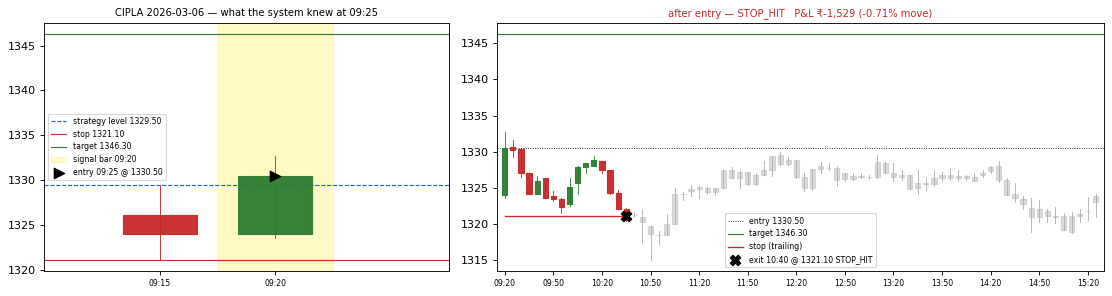


2026-03-09  SUNPHARMA   driver CAMARILLA — CAMARILLA: reversal at L3=1784.20, target H3=1802.80
  signal bar 09:15 | decided on bars up to 09:40 | ENTRY 09:45 @ 1783.20  (strategy level 1784.20, entry -0.06% vs level)
  stop 1774.91 (-0.46%)   target 1802.80 (+1.10%)   RR 2.36   rank 4
  votes: 4 agreeing, score 15.03, predicted win 47.3% — BOLLINGER, CAMARILLA, DAILY-BIAS, REL-STR, RSI-EXT, SR-BREAK
  higher-ranked stocks skipped at this scan: DMART (SKIP RR 1.40 < 1.5 at entry price); DATAPATTNS (SKIP geometry (stop 4.00%, target 7.99%)); MCX (SKIP RR 0.69 < 1.5 at entry price)
  EXIT 10:35 @ 1774.91 (STOP_HIT)   move -0.47%   P&L ₹-1,048 net (-0.52%) on 112 shares


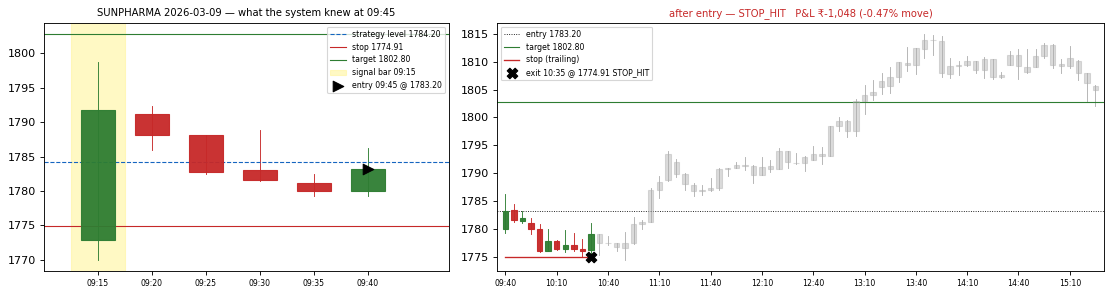


2026-03-10  ACUTAAS   driver CAMARILLA — CAMARILLA: breakout above H4=2211.54
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 2229.60  (strategy level 2211.54, entry +0.82% vs level)
  stop 2207.30 (-1.00%)   target 2313.62 (+3.77%)   RR 1.93   rank 1
  votes: 7 agreeing, score 21.0, predicted win 49.6% — ADX-FILTER, CAMARILLA, DAILY-BIAS, DBL-BTM, GAP-CONT, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: none
  EXIT 10:25 @ 2256.60 (PROFIT_LOCK_STOP)   move +1.21%   P&L ₹+2,283 net (+1.15%) on 89 shares


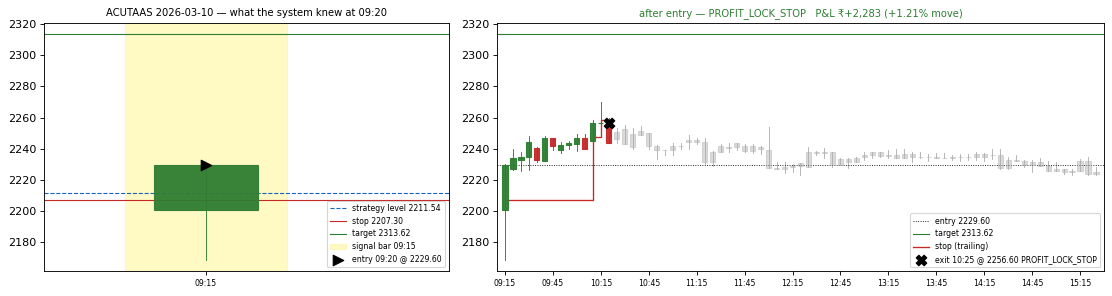


2026-03-11  ASTRAL   driver CAMARILLA — CAMARILLA: breakout above H4=1688.43
  signal bar 09:15 | decided on bars up to 09:25 | ENTRY 09:30 @ 1695.40  (strategy level 1688.43, entry +0.41% vs level)
  stop 1678.45 (-1.00%)   target 1735.29 (+2.35%)   RR 2.13   rank 1
  votes: 8 agreeing, score 24.0, predicted win 50.0% — ADX-FILTER, CAMARILLA, DAILY-BIAS, DBL-BTM, FIRST-CANDLE, GAP-CONT, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: none
  EXIT 13:20 @ 1707.42 (PROFIT_LOCK_STOP)   move +0.71%   P&L ₹+1,287 net (+0.65%) on 117 shares


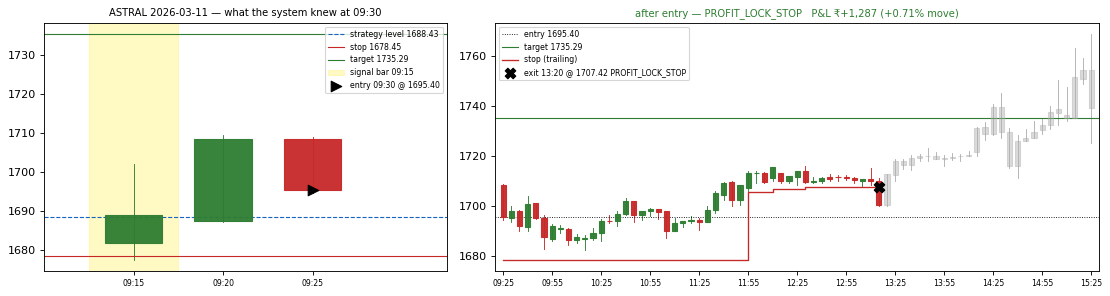


2026-03-12  PARADEEP   driver VPOC — VPOC: breakout above VAH=114.62
  signal bar 09:20 | decided on bars up to 09:20 | ENTRY 09:25 @ 114.65  (strategy level 114.62, entry +0.03% vs level)
  stop 113.50 (-1.00%)   target 121.07 (+5.60%)   RR 3.91   rank 3
  votes: 4 agreeing, score 9.63, predicted win 49.9% — CPR, FIRST-CANDLE, SUPERTREND, VPOC
  higher-ranked stocks skipped at this scan: CARTRADE (SKIP viability (stop 0.20x ATR < 0.3)); VEDL (FAIL Only 3 strategy agreed (need 4))
  EXIT 09:35 @ 113.50 (STOP_HIT)   move -1.00%   P&L ₹-2,125 net (-1.06%) on 1744 shares


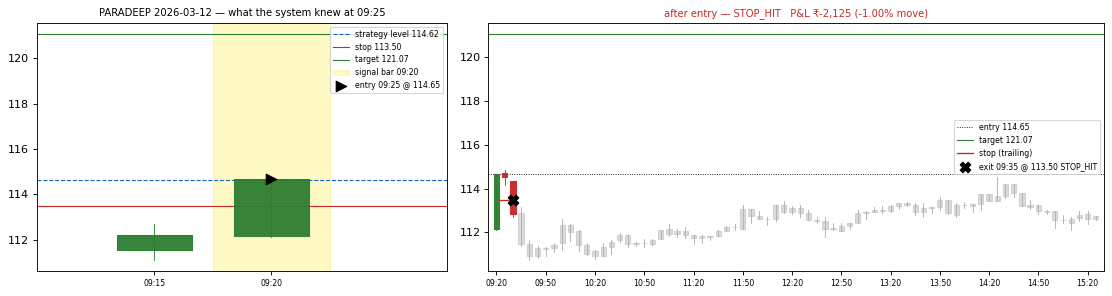


2026-03-13  ABB   driver VPOC — VPOC: breakout above VAH=6423.71
  signal bar 09:15 | decided on bars up to 09:20 | ENTRY 09:25 @ 6467.00  (strategy level 6423.71, entry +0.67% vs level)
  stop 6402.33 (-1.00%)   target 6678.29 (+3.27%)   RR 2.61   rank 3
  votes: 5 agreeing, score 15.0, predicted win 49.8% — ADX-FILTER, DAILY-BIAS, DBL-BTM, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: NTPC (SKIP viability (stop 0.12x ATR < 0.3)); SUNPHARMA (SKIP geometry (stop 0.22%, target 0.44%))
  EXIT 09:40 @ 6500.34 (PROFIT_LOCK_STOP)   move +0.52%   P&L ₹+882 net (+0.45%) on 30 shares


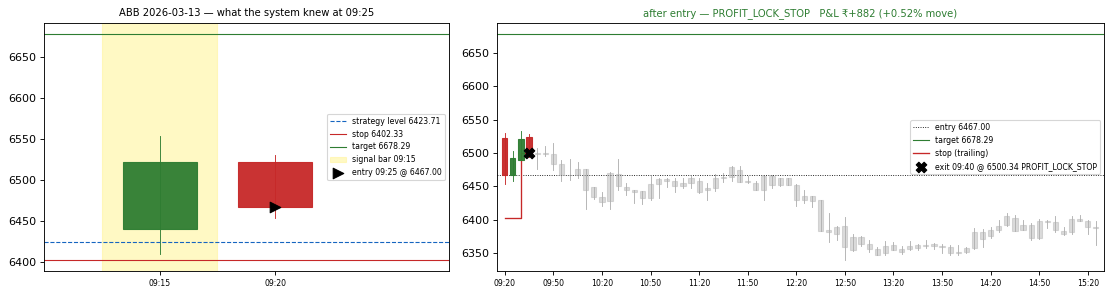


2026-03-16  BANKINDIA   driver VPOC — VPOC: rejection below VPOC=146.77
  signal bar 09:40 | decided on bars up to 09:40 | ENTRY 09:45 @ 146.48  (strategy level 146.48, entry +0.00% vs level)
  stop 145.25 (-0.84%)   target 149.17 (+1.84%)   RR 2.19   rank 4
  votes: 6 agreeing, score 18.16, predicted win 47.6% — BOLLINGER, CAMARILLA, FIRST-CANDLE, MACD, REL-STR, SUPERTREND, VPOC
  higher-ranked stocks skipped at this scan: CHENNPETRO (SKIP geometry (stop 3.87%, target 7.75%)); IDEA (FAIL Predicted win pct 51.4% in 50-55% danger zone); KIRLOSENG (SKIP RR 0.45 < 1.5 at entry price)
  EXIT 10:20 @ 145.25 (STOP_HIT)   move -0.84%   P&L ₹-1,798 net (-0.90%) on 1365 shares


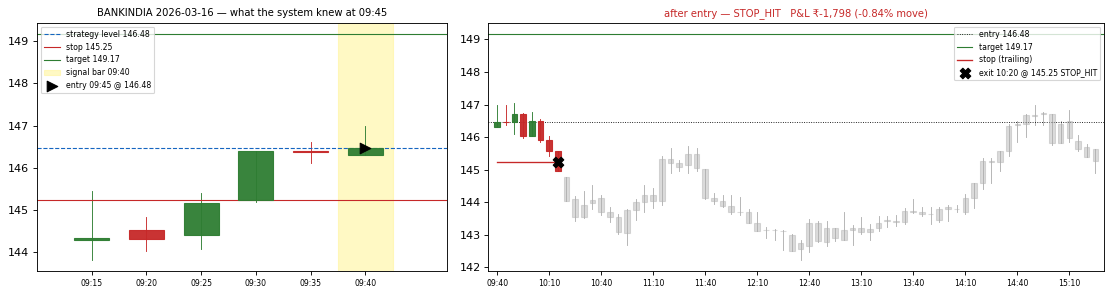


2026-03-17  AUROPHARMA   driver FIRST-CANDLE — FIRST-CANDLE: break above first candle high=1286.80
  signal bar 09:20 | decided on bars up to 09:25 | ENTRY 09:30 @ 1288.10  (strategy level 1286.80, entry +0.10% vs level)
  stop 1275.22 (-1.00%)   target 1310.20 (+1.72%)   RR 1.70   rank 8
  votes: 5 agreeing, score 12.63, predicted win 47.4% — DAILY-BIAS, FIRST-CANDLE, GAP-CONT, MACD, SUPERTREND
  higher-ranked stocks skipped at this scan: BSE (SKIP RR 0.57 < 1.5 at entry price); MCX (SKIP viability (stop 0.19x ATR < 0.3)); SUNPHARMA (SKIP viability (stop 0.20x ATR < 0.3)); ACUTAAS (SKIP geometry (stop 2.60%, target 4.78%))
  EXIT 14:50 @ 1288.20 (TIME_EXIT)   move +0.01%   P&L ₹-104 net (-0.05%) on 155 shares


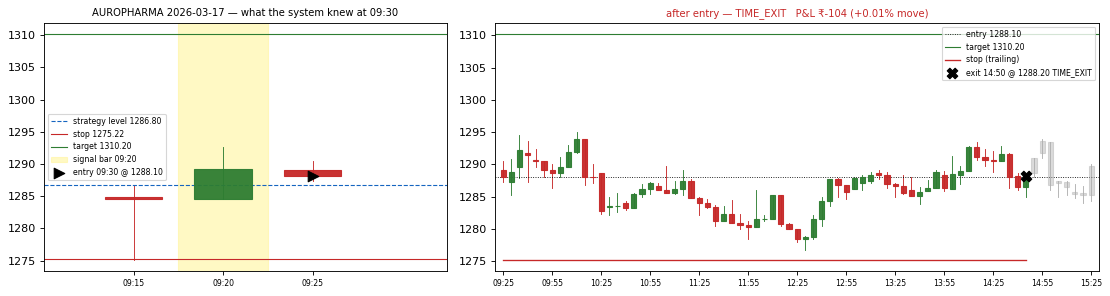


2026-03-18  NYKAA   driver CAMARILLA — CAMARILLA: breakout above H4=241.72
  signal bar 09:20 | decided on bars up to 09:20 | ENTRY 09:25 @ 242.75  (strategy level 241.72, entry +0.42% vs level)
  stop 240.32 (-1.00%)   target 248.87 (+2.52%)   RR 2.18   rank 2
  votes: 8 agreeing, score 21.63, predicted win 49.7% — ADX-FILTER, CAMARILLA, CPR, FIRST-CANDLE, MACD, PDH-PDL, SUPERTREND, VPOC
  higher-ranked stocks skipped at this scan: HAVELLS (SKIP viability (stop 0.18x ATR < 0.3))
  EXIT 14:50 @ 243.45 (TIME_EXIT)   move +0.29%   P&L ₹+456 net (+0.23%) on 823 shares


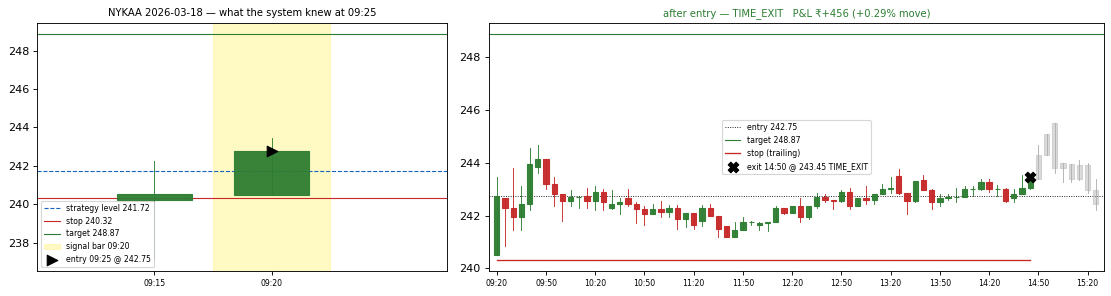


2026-03-19  PWL   driver VPOC — VPOC: breakout above VAH=87.49
  signal bar 09:25 | decided on bars up to 09:25 | ENTRY 09:30 @ 87.55  (strategy level 87.49, entry +0.07% vs level)
  stop 86.67 (-1.01%)   target 93.06 (+6.29%)   RR 3.15   rank 9
  votes: 5 agreeing, score 13.0, predicted win 49.9% — CAMARILLA, CPR, GAP-FADE, SR-BREAK, VPOC
  higher-ranked stocks skipped at this scan: DATAPATTNS (SKIP geometry (stop 2.70%, target 5.39%)); ABB (SKIP viability (stop 0.16x ATR < 0.3)); ACUTAAS (SKIP geometry (stop 3.99%, target 7.99%)); NATIONALUM (SKIP RR 1.25 < 1.5 at entry price)
  EXIT 09:40 @ 86.67 (STOP_HIT)   move -1.00%   P&L ₹-2,129 net (-1.06%) on 2284 shares


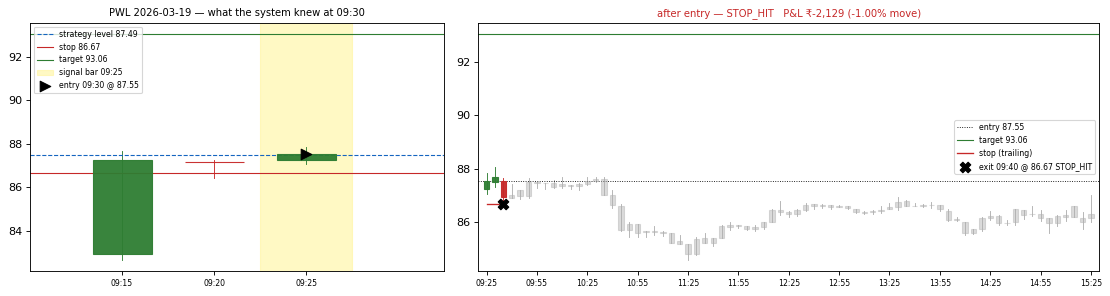


2026-03-20  JAINREC   driver CAMARILLA — CAMARILLA: breakout above H4=443.58
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 445.30  (strategy level 443.58, entry +0.39% vs level)
  stop 440.85 (-1.00%)   target 460.74 (+3.47%)   RR 2.57   rank 2
  votes: 6 agreeing, score 18.0, predicted win 49.9% — ADX-FILTER, CAMARILLA, DAILY-BIAS, GAP-CONT, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: JSWENERGY (SKIP RR 1.44 < 1.5 at entry price)
  EXIT 09:25 @ 440.85 (STOP_HIT)   move -1.00%   P&L ₹-2,117 net (-1.06%) on 449 shares


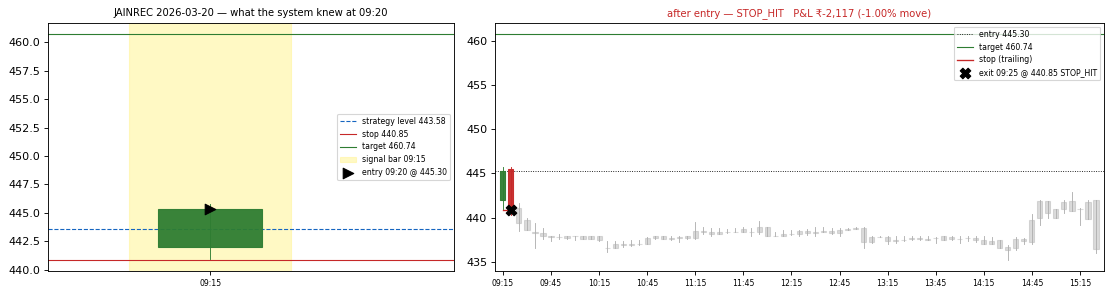


2026-03-23  ONGC   driver FIRST-CANDLE — FIRST-CANDLE: break above first candle high=267.95
  signal bar 09:20 | decided on bars up to 09:40 | ENTRY 09:45 @ 268.15  (strategy level 267.95, entry +0.07% vs level)
  stop 265.47 (-1.00%)   target 276.05 (+2.95%)   RR 1.86   rank 11
  votes: 4 agreeing, score 9.53, predicted win 49.8% — ADX-FILTER, EMA-CROSS, FIRST-CANDLE, REL-STR
  higher-ranked stocks skipped at this scan: TECHM (SKIP RR 0.62 < 1.5 at entry price); ACUTAAS (SKIP geometry (stop 2.56%, target 5.12%)); GMDCLTD (FAIL RR=0.43 < 1.5); COFORGE (FAIL Signal at 09:35 requires score >= 6 and 5+ agreements (got score=14.53, agreeing=4))
  EXIT 12:30 @ 265.47 (STOP_HIT)   move -1.00%   P&L ₹-2,116 net (-1.06%) on 745 shares


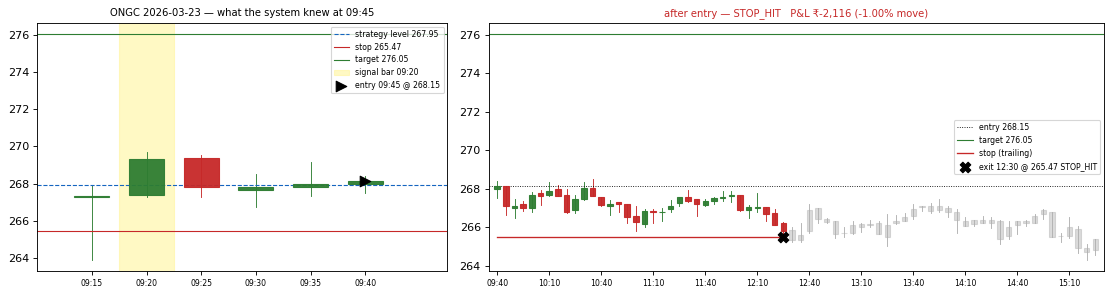


2026-03-24  KFINTECH   driver CAMARILLA — CAMARILLA: breakout above H4=895.77
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 902.00  (strategy level 895.77, entry +0.69% vs level)
  stop 892.98 (-1.00%)   target 941.31 (+4.36%)   RR 2.23   rank 9
  votes: 4 agreeing, score 12.0, predicted win 49.5% — CAMARILLA, FALL-WEDGE, GAP-CONT, VPOC
  higher-ranked stocks skipped at this scan: MEESHO (SKIP viability (stop 0.21x ATR < 0.3)); JAINREC (SKIP RR 1.36 < 1.5 at entry price); LUPIN (FAIL Predicted win pct 50.1% in 50-55% danger zone); CARTRADE (FAIL Predicted win pct 50.1% in 50-55% danger zone)
  EXIT 09:35 @ 905.25 (PROFIT_LOCK_STOP)   move +0.36%   P&L ₹+598 net (+0.30%) on 221 shares


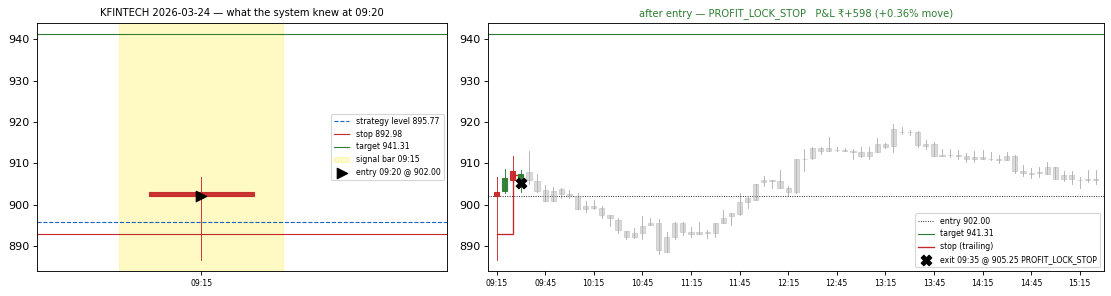


2026-03-25  BELRISE   driver VPOC — VPOC: breakout above VAH=196.35
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 197.80  (strategy level 196.35, entry +0.74% vs level)
  stop 195.82 (-1.00%)   target 205.97 (+4.13%)   RR 1.92   rank 7
  votes: 5 agreeing, score 15.0, predicted win 49.3% — ADX-FILTER, DAILY-BIAS, GAP-CONT, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: ABB (FAIL Predicted win pct 50.2% in 50-55% danger zone); LLOYDSME (SKIP RR 1.00 < 1.5 at entry price); NATCOPHARM (SKIP RR 0.66 < 1.5 at entry price); SYRMA (SKIP viability (stop 0.30x ATR < 0.3))
  EXIT 10:00 @ 199.31 (PROFIT_LOCK_STOP)   move +0.76%   P&L ₹+1,406 net (+0.70%) on 1011 shares


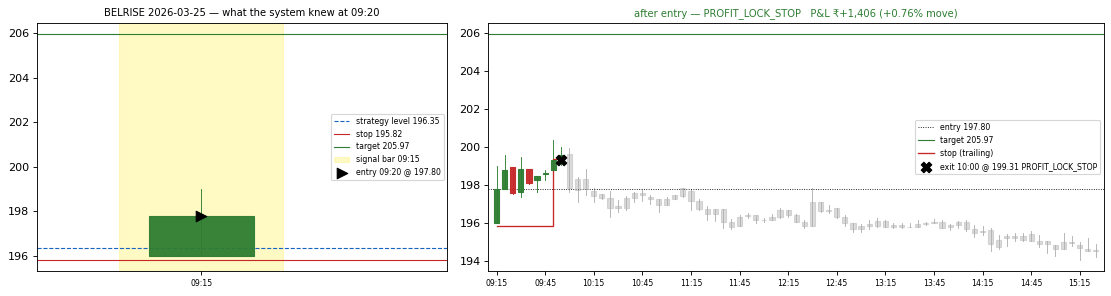


2026-03-27  HCLTECH   driver FIRST-CANDLE — FIRST-CANDLE: break above first candle high=1396.90
  signal bar 09:20 | decided on bars up to 09:25 | ENTRY 09:30 @ 1399.60  (strategy level 1396.90, entry +0.19% vs level)
  stop 1385.60 (-1.00%)   target 1440.10 (+2.89%)   RR 1.67   rank 10
  votes: 6 agreeing, score 15.63, predicted win 48.8% — ADX-FILTER, CPR, DAILY-BIAS, DBL-BTM, FIRST-CANDLE, SUPERTREND
  higher-ranked stocks skipped at this scan: ATGL (SKIP price already past stop/target); HFCL (SKIP RR 0.61 < 1.5 at entry price); PERSISTENT (SKIP viability (stop 0.16x ATR < 0.3)); OLAELEC (SKIP RR 1.10 < 1.5 at entry price)
  EXIT 10:45 @ 1385.60 (STOP_HIT)   move -1.00%   P&L ₹-2,107 net (-1.06%) on 142 shares


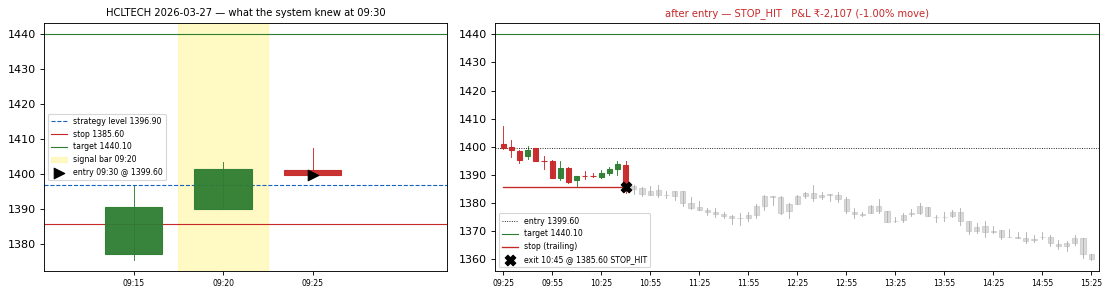


2026-03-30  ONGC   driver VPOC — VPOC: breakout above VAH=284.38
  signal bar 09:20 | decided on bars up to 09:20 | ENTRY 09:25 @ 286.45  (strategy level 284.38, entry +0.73% vs level)
  stop 283.59 (-1.00%)   target 294.99 (+2.98%)   RR 2.08   rank 6
  votes: 6 agreeing, score 15.63, predicted win 48.7% — ADX-FILTER, DAILY-BIAS, MACD, PDH-PDL, SUPERTREND, VPOC
  higher-ranked stocks skipped at this scan: NATCOPHARM (FAIL Predicted win pct 50.1% in 50-55% danger zone); ADANIPOWER (SKIP RR 1.27 < 1.5 at entry price); COALINDIA (SKIP viability (stop 0.26x ATR < 0.3)); NTPCGREEN (FAIL Predicted win pct 50.2% in 50-55% danger zone)
  EXIT 14:50 @ 284.20 (TIME_EXIT)   move -0.79%   P&L ₹-1,690 net (-0.85%) on 698 shares


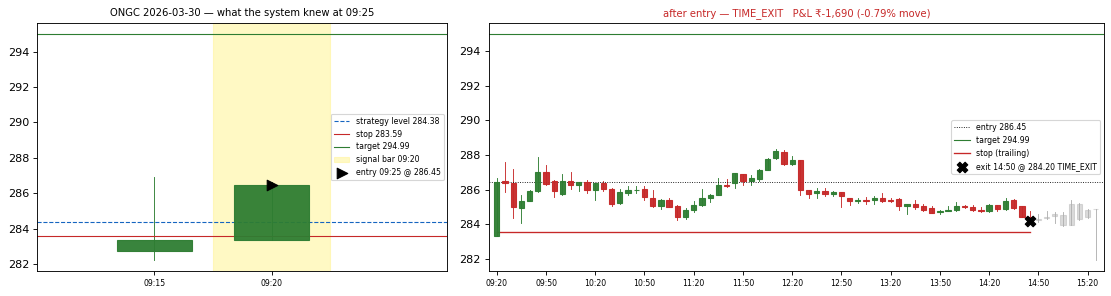

In [7]:
tc.show_month(res, "2026-03")

### April 2026

2026-04: 20 trading days, 20 trades, 7 winners, net ₹-13,012

2026-04-01  GMDCLTD   driver VPOC — VPOC: breakout above VAH=579.40
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 585.15  (strategy level 579.40, entry +0.99% vs level)
  stop 579.30 (-1.00%)   target 603.07 (+3.06%)   RR 1.70   rank 2
  votes: 7 agreeing, score 21.0, predicted win 49.5% — ADX-FILTER, CAMARILLA, CPR, DAILY-BIAS, GAP-CONT, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: JAINREC (SKIP RR 0.90 < 1.5 at entry price)
  EXIT 10:30 @ 579.30 (STOP_HIT)   move -1.00%   P&L ₹-2,114 net (-1.06%) on 341 shares


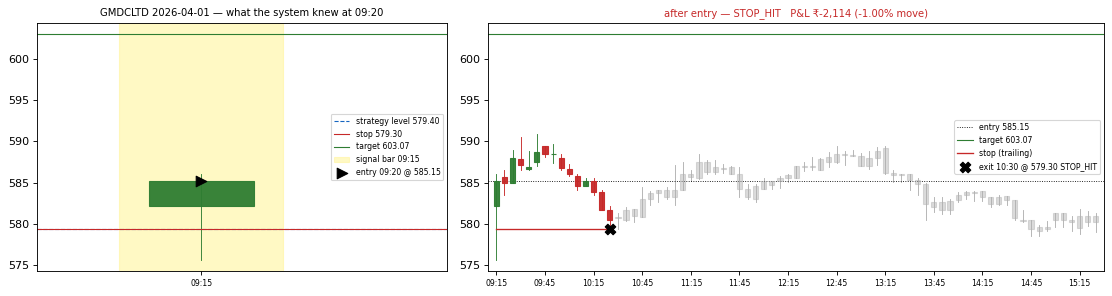


2026-04-02  TECHM   driver FIRST-CANDLE — FIRST-CANDLE: break above first candle high=1394.90
  signal bar 09:20 | decided on bars up to 09:35 | ENTRY 09:40 @ 1396.60  (strategy level 1394.90, entry +0.12% vs level)
  stop 1383.50 (-0.94%)   target 1417.70 (+1.51%)   RR 1.61   rank 1
  votes: 6 agreeing, score 20.53, predicted win 47.4% — BOLLINGER, CAMARILLA, DAILY-BIAS, DBL-BTM, FIRST-CANDLE, MACD, PIN-BAR
  higher-ranked stocks skipped at this scan: none
  EXIT 14:45 @ 1439.77 (PROFIT_LOCK_STOP)   move +3.09%   P&L ₹+6,052 net (+3.03%) on 143 shares


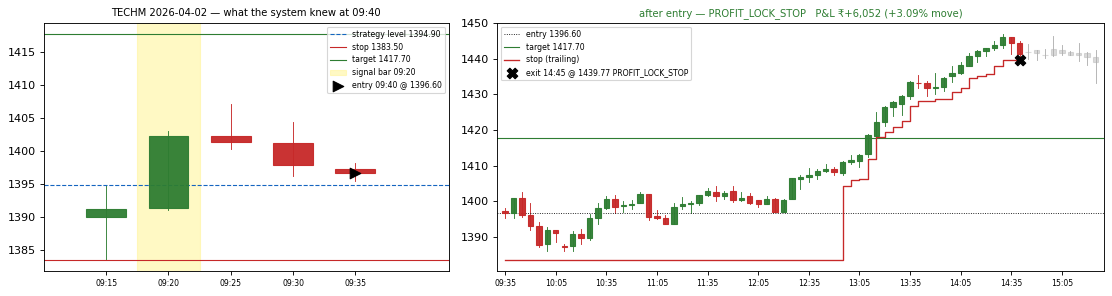


2026-04-06  DMART   driver VPOC — VPOC: breakout above VAH=4372.94
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 4417.80  (strategy level 4372.94, entry +1.03% vs level)
  stop 4373.62 (-1.00%)   target 4501.63 (+1.90%)   RR 1.79   rank 4
  votes: 5 agreeing, score 15.0, predicted win 49.3% — ADX-FILTER, DAILY-BIAS, GAP-CONT, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: URBANCO (SKIP geometry (stop 0.08%, target 0.15%)); INFY (SKIP viability (stop 0.26x ATR < 0.3)); ADANIPOWER (SKIP RR 1.23 < 1.5 at entry price)
  EXIT 09:45 @ 4373.62 (STOP_HIT)   move -1.00%   P&L ₹-2,107 net (-1.06%) on 45 shares


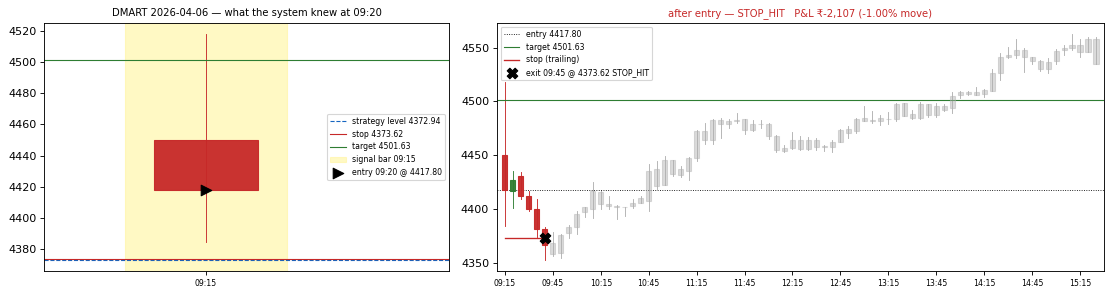


2026-04-07  KALYANKJIL   driver VPOC — VPOC: breakout above VAH=420.85
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 425.90  (strategy level 420.85, entry +1.20% vs level)
  stop 421.64 (-1.00%)   target 436.25 (+2.43%)   RR 1.76   rank 1
  votes: 5 agreeing, score 15.0, predicted win 49.3% — ADX-FILTER, DAILY-BIAS, GAP-CONT, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: none
  EXIT 09:40 @ 421.64 (STOP_HIT)   move -1.00%   P&L ₹-2,117 net (-1.06%) on 469 shares


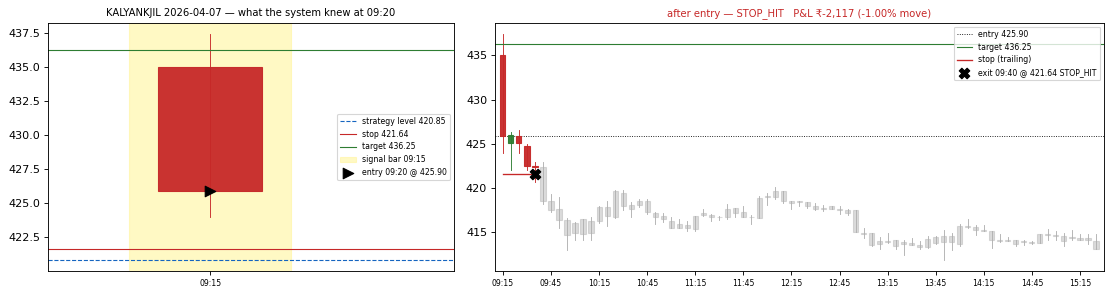


2026-04-08  ICICIAMC   driver CAMARILLA — CAMARILLA: breakout above H4=3144.99
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 3178.00  (strategy level 3144.99, entry +1.05% vs level)
  stop 3146.22 (-1.00%)   target 3334.96 (+4.94%)   RR 1.95   rank 9
  votes: 6 agreeing, score 18.0, predicted win 49.9% — ADX-FILTER, CAMARILLA, DAILY-BIAS, GAP-CONT, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: KAYNES (SKIP RR 1.01 < 1.5 at entry price); IEX (SKIP price already past stop/target); PAGEIND (SKIP RR 0.26 < 1.5 at entry price); RPOWER (SKIP price already past stop/target)
  EXIT 09:25 @ 3146.22 (STOP_HIT)   move -1.00%   P&L ₹-2,089 net (-1.06%) on 62 shares


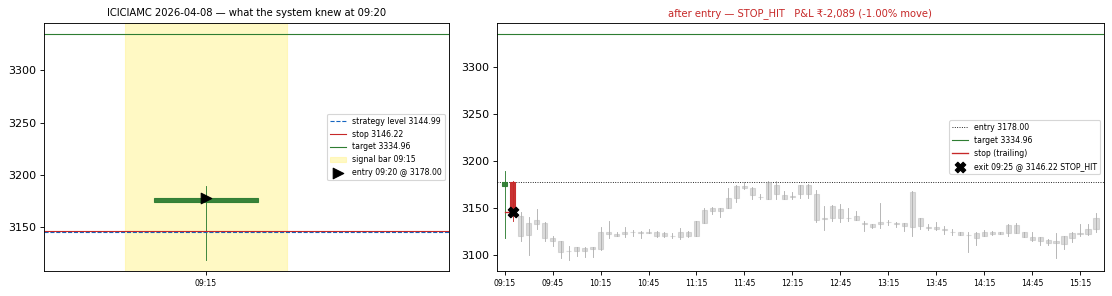


2026-04-09  GRAVITA   driver VPOC — VPOC: breakout above VAH=1506.00
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 1509.40  (strategy level 1506.00, entry +0.23% vs level)
  stop 1494.31 (-1.00%)   target 1570.33 (+4.04%)   RR 2.59   rank 37
  votes: 4 agreeing, score 12.0, predicted win 50.0% — ADX-FILTER, DBL-BTM, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: KAYNES (FAIL Predicted win pct 50.3% in 50-55% danger zone); BELRISE (FAIL Predicted win pct 50.2% in 50-55% danger zone); NTPC (SKIP RR 1.07 < 1.5 at entry price); APARINDS (FAIL Predicted win pct 50.7% in 50-55% danger zone)
  EXIT 09:50 @ 1494.31 (STOP_HIT)   move -1.00%   P&L ₹-2,111 net (-1.06%) on 132 shares


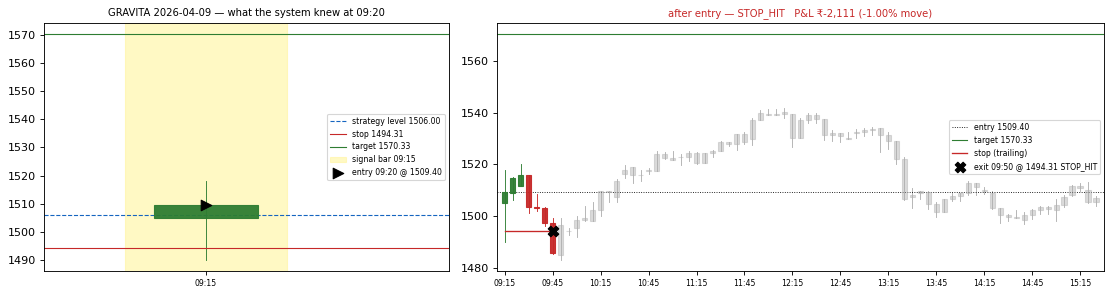


2026-04-10  TATASTEEL   driver CAMARILLA — CAMARILLA: breakout above H4=207.27
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 208.19  (strategy level 207.27, entry +0.44% vs level)
  stop 206.14 (-0.98%)   target 211.81 (+1.74%)   RR 1.77   rank 16
  votes: 5 agreeing, score 15.0, predicted win 48.9% — CAMARILLA, DAILY-BIAS, DBL-BTM, GAP-CONT, VPOC
  higher-ranked stocks skipped at this scan: JSL (SKIP RR 0.72 < 1.5 at entry price); WIPRO (SKIP RR 0.39 < 1.5 at entry price); GVT&D (FAIL Predicted win pct 50.3% in 50-55% danger zone); LENSKART (FAIL Predicted win pct 50.2% in 50-55% danger zone)
  EXIT 10:10 @ 206.14 (STOP_HIT)   move -0.98%   P&L ₹-2,087 net (-1.04%) on 960 shares


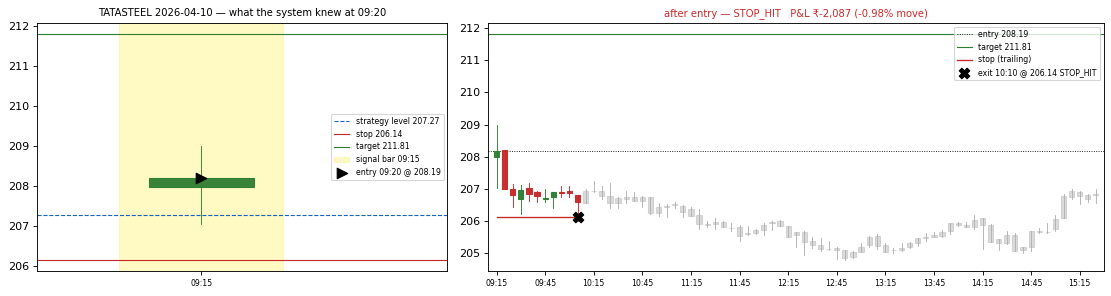


2026-04-13  MARICO   driver FIRST-CANDLE — FIRST-CANDLE: break above first candle high=756.90
  signal bar 09:20 | decided on bars up to 09:20 | ENTRY 09:25 @ 757.55  (strategy level 756.90, entry +0.09% vs level)
  stop 749.97 (-1.00%)   target 783.40 (+3.41%)   RR 1.86   rank 10
  votes: 4 agreeing, score 14.53, predicted win 47.9% — BOLLINGER, DAILY-BIAS, FIRST-CANDLE, SR-BREAK, VPOC
  higher-ranked stocks skipped at this scan: PREMIERENE (SKIP geometry (stop 2.22%, target 4.43%)); NATIONALUM (FAIL Predicted win pct 51.3% in 50-55% danger zone); ADANIENSOL (SKIP geometry (stop 2.26%, target 4.53%)); AMBER (SKIP RR 0.80 < 1.5 at entry price)
  EXIT 14:50 @ 758.85 (TIME_EXIT)   move +0.17%   P&L ₹+223 net (+0.11%) on 264 shares


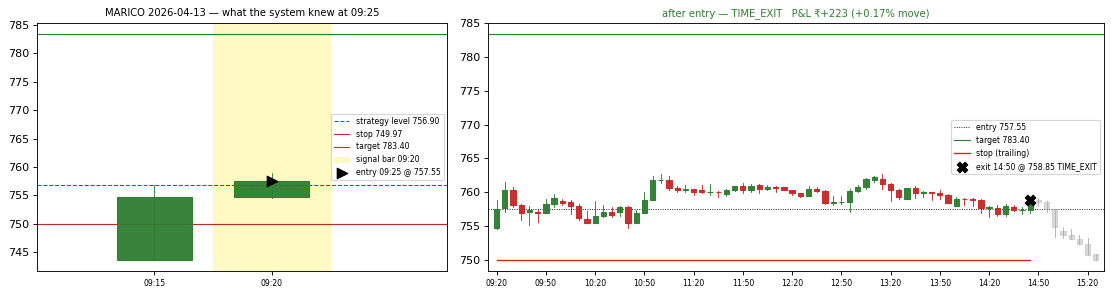


2026-04-15  LICI   driver CAMARILLA — CAMARILLA: breakout above H4=412.25
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 413.80  (strategy level 412.25, entry +0.38% vs level)
  stop 409.66 (-1.00%)   target 427.76 (+3.37%)   RR 2.58   rank 2
  votes: 7 agreeing, score 21.0, predicted win 49.6% — ADX-FILTER, CAMARILLA, DAILY-BIAS, DBL-BTM, GAP-CONT, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: BAJFINANCE (SKIP RR 0.89 < 1.5 at entry price)
  EXIT 09:50 @ 416.31 (PROFIT_LOCK_STOP)   move +0.61%   P&L ₹+1,092 net (+0.55%) on 483 shares


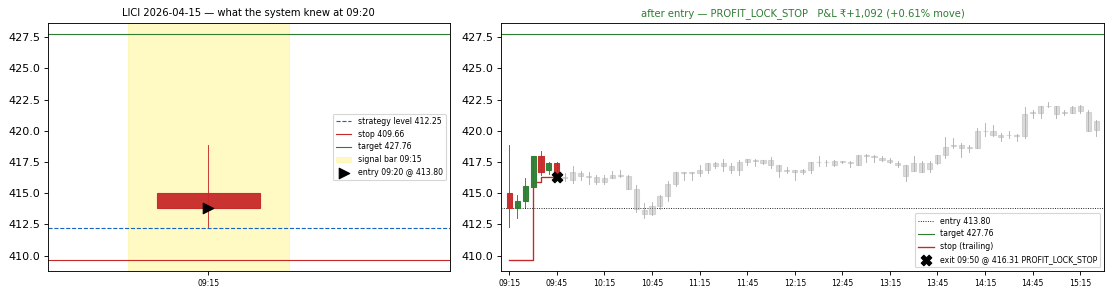


2026-04-16  ETERNAL   driver CAMARILLA — CAMARILLA: breakout above H4=250.66
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 251.96  (strategy level 250.66, entry +0.52% vs level)
  stop 249.44 (-1.00%)   target 259.95 (+3.17%)   RR 2.21   rank 2
  votes: 7 agreeing, score 21.0, predicted win 49.6% — ADX-FILTER, CAMARILLA, DAILY-BIAS, DBL-BTM, GAP-CONT, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: AUROPHARMA (SKIP viability (stop 0.29x ATR < 0.3))
  EXIT 09:40 @ 249.44 (STOP_HIT)   move -1.00%   P&L ₹-2,118 net (-1.06%) on 793 shares


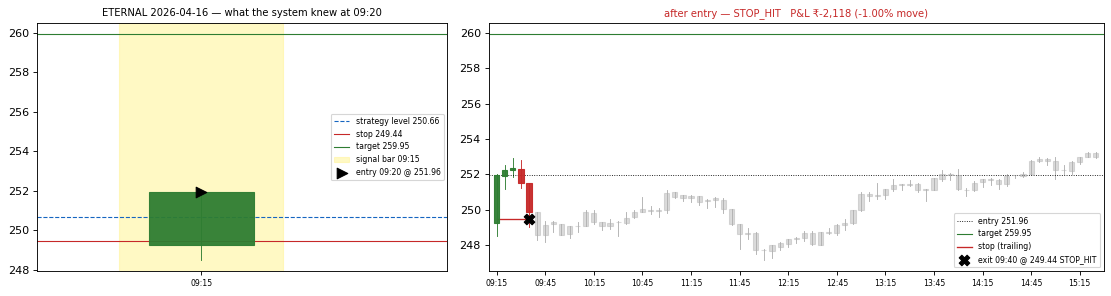


2026-04-17  NAUKRI   driver FIRST-CANDLE — FIRST-CANDLE: break above first candle high=1050.90
  signal bar 09:20 | decided on bars up to 09:20 | ENTRY 09:25 @ 1052.00  (strategy level 1050.90, entry +0.10% vs level)
  stop 1041.48 (-1.00%)   target 1072.30 (+1.93%)   RR 1.72   rank 5
  votes: 6 agreeing, score 18.0, predicted win 49.6% — ADX-FILTER, CAMARILLA, CPR, DAILY-BIAS, DBL-BTM, FIRST-CANDLE
  higher-ranked stocks skipped at this scan: NESTLEIND (FAIL Predicted win pct 50.6% in 50-55% danger zone); JSWENERGY (FAIL Predicted win pct 50.4% in 50-55% danger zone); KFINTECH (SKIP viability (stop 0.03x ATR < 0.3)); LAURUSLABS (FAIL Predicted win pct 50.2% in 50-55% danger zone)
  EXIT 09:40 @ 1041.48 (STOP_HIT)   move -1.00%   P&L ₹-2,118 net (-1.06%) on 190 shares


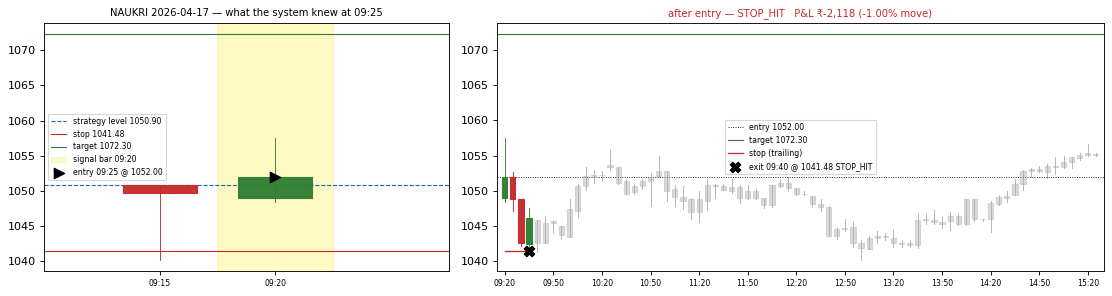


2026-04-20  ASTRAL   driver FIRST-CANDLE — FIRST-CANDLE: break above first candle high=1612.20
  signal bar 09:20 | decided on bars up to 09:20 | ENTRY 09:25 @ 1616.20  (strategy level 1612.20, entry +0.25% vs level)
  stop 1600.04 (-1.00%)   target 1676.60 (+3.74%)   RR 1.67   rank 33
  votes: 5 agreeing, score 15.0, predicted win 50.0% — ADX-FILTER, CAMARILLA, CPR, DAILY-BIAS, FIRST-CANDLE
  higher-ranked stocks skipped at this scan: GRANULES (SKIP RR 0.02 < 1.5 at entry price); APOLLOHOSP (SKIP viability (stop 0.15x ATR < 0.3)); LTF (FAIL Predicted win pct 50.1% in 50-55% danger zone); POWERINDIA (FAIL Predicted win pct 50.4% in 50-55% danger zone)
  EXIT 09:40 @ 1600.04 (STOP_HIT)   move -1.00%   P&L ₹-2,107 net (-1.06%) on 123 shares


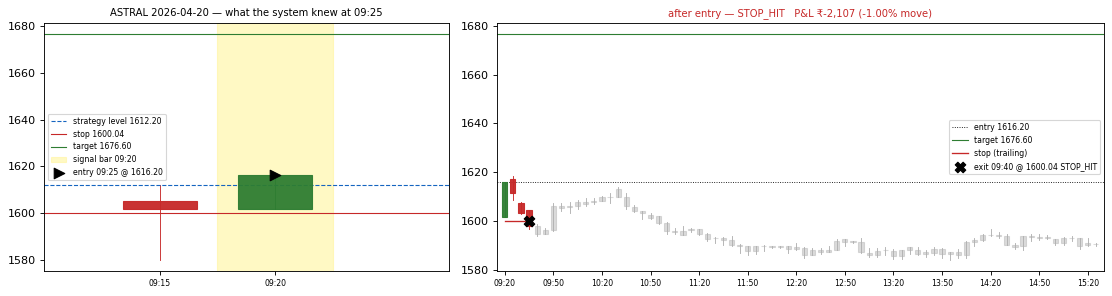


2026-04-21  PARADEEP   driver VPOC — VPOC: breakout above VAH=128.20
  signal bar 09:15 | decided on bars up to 09:20 | ENTRY 09:25 @ 128.80  (strategy level 128.20, entry +0.47% vs level)
  stop 127.51 (-1.00%)   target 133.63 (+3.75%)   RR 2.71   rank 12
  votes: 5 agreeing, score 15.0, predicted win 49.9% — ADX-FILTER, BULL-FLAG, DAILY-BIAS, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: LICHSGFIN (FAIL Predicted win pct 50.1% in 50-55% danger zone); LLOYDSME (FAIL Predicted win pct 50.2% in 50-55% danger zone); M&M (SKIP viability (stop 0.20x ATR < 0.3)); SAIL (FAIL Predicted win pct 51.2% in 50-55% danger zone)
  EXIT 09:35 @ 129.10 (PROFIT_LOCK_STOP)   move +0.23%   P&L ₹+346 net (+0.17%) on 1552 shares


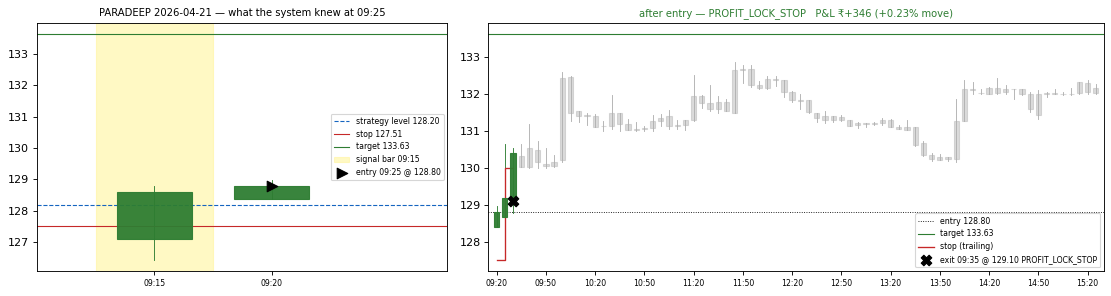


2026-04-22  ADANIGREEN   driver FIRST-CANDLE — FIRST-CANDLE: break above first candle high=1162.70
  signal bar 09:20 | decided on bars up to 09:20 | ENTRY 09:25 @ 1163.75  (strategy level 1162.70, entry +0.09% vs level)
  stop 1152.11 (-1.00%)   target 1192.10 (+2.44%)   RR 1.80   rank 24
  votes: 4 agreeing, score 12.0, predicted win 49.9% — ADX-FILTER, DAILY-BIAS, FIRST-CANDLE, SR-BREAK
  higher-ranked stocks skipped at this scan: AWL (SKIP RR 1.18 < 1.5 at entry price); ABB (SKIP RR 1.28 < 1.5 at entry price); URBANCO (FAIL Predicted win pct 50.3% in 50-55% danger zone); TORNTPOWER (FAIL Predicted win pct 51.5% in 50-55% danger zone)
  EXIT 10:30 @ 1174.10 (PROFIT_LOCK_STOP)   move +0.89%   P&L ₹+1,650 net (+0.83%) on 171 shares


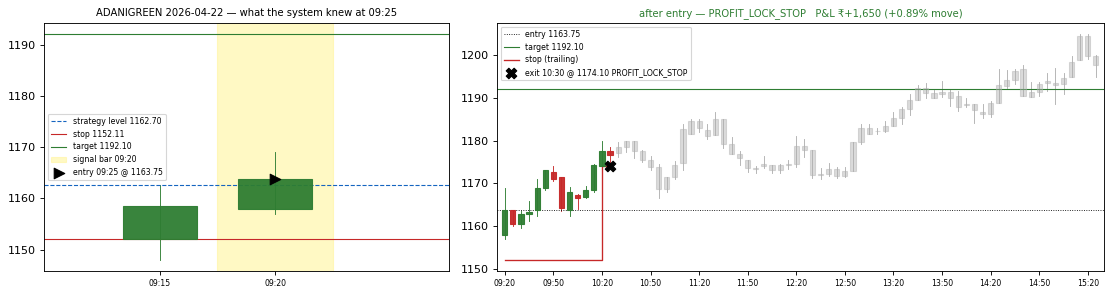


2026-04-23  MRPL   driver VPOC — VPOC: breakout above VAH=188.55
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 189.10  (strategy level 188.55, entry +0.29% vs level)
  stop 187.21 (-1.00%)   target 193.17 (+2.15%)   RR 1.75   rank 4
  votes: 5 agreeing, score 15.0, predicted win 49.8% — ADX-FILTER, DAILY-BIAS, DBL-BTM, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: WELCORP (FAIL Predicted win pct 50.2% in 50-55% danger zone); DRREDDY (SKIP price already past stop/target); WOCKPHARMA (FAIL RR=1.31 < 1.5)
  EXIT 09:40 @ 190.83 (PROFIT_LOCK_STOP)   move +0.92%   P&L ₹+1,708 net (+0.85%) on 1057 shares


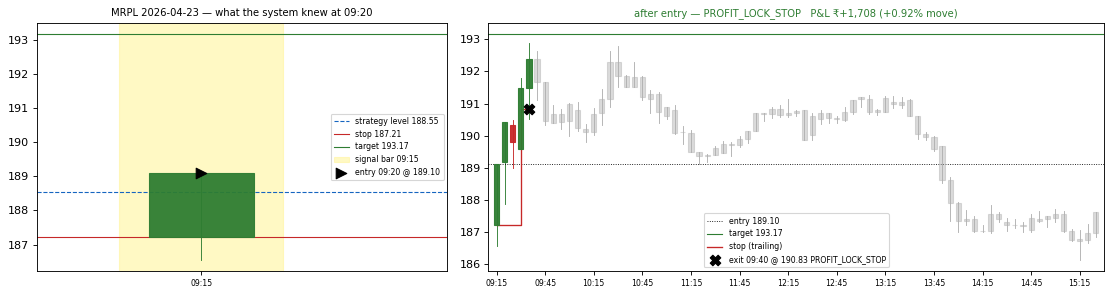


2026-04-24  MRPL   driver CAMARILLA — CAMARILLA: breakout above H4=191.33
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 192.70  (strategy level 191.33, entry +0.72% vs level)
  stop 190.77 (-1.00%)   target 198.79 (+3.16%)   RR 1.88   rank 5
  votes: 5 agreeing, score 15.0, predicted win 49.5% — ADX-FILTER, CAMARILLA, DAILY-BIAS, DBL-BTM, VPOC
  higher-ranked stocks skipped at this scan: AUBANK (FAIL Predicted win pct 50.3% in 50-55% danger zone); BDL (SKIP viability (stop 0.20x ATR < 0.3)); MARICO (SKIP viability (stop 0.22x ATR < 0.3)); HUDCO (SKIP price already past stop/target)
  EXIT 09:30 @ 193.31 (PROFIT_LOCK_STOP)   move +0.32%   P&L ₹+513 net (+0.26%) on 1037 shares


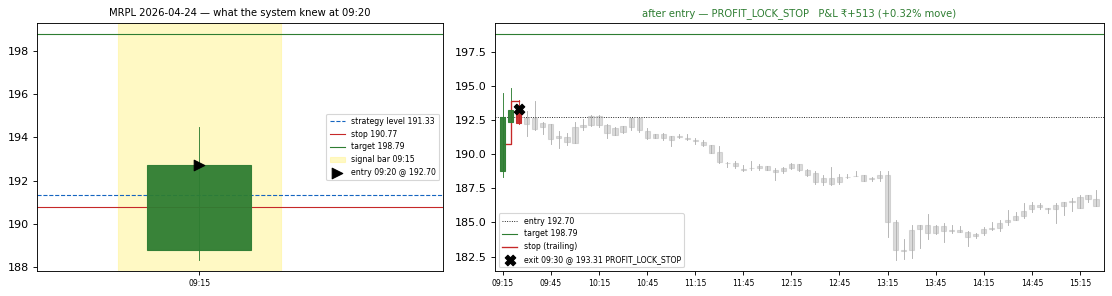


2026-04-27  ATGL   driver VPOC — VPOC: breakout above VAH=629.18
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 632.40  (strategy level 629.18, entry +0.51% vs level)
  stop 626.08 (-1.00%)   target 649.84 (+2.76%)   RR 1.71   rank 14
  votes: 5 agreeing, score 15.0, predicted win 49.3% — ADX-FILTER, DAILY-BIAS, GAP-CONT, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: POWERGRID (SKIP price already past stop/target); HFCL (SKIP RR 0.39 < 1.5 at entry price); INDUSINDBK (SKIP RR 0.22 < 1.5 at entry price); KEI (SKIP viability (stop 0.22x ATR < 0.3))
  EXIT 09:35 @ 626.08 (STOP_HIT)   move -1.00%   P&L ₹-2,116 net (-1.06%) on 316 shares


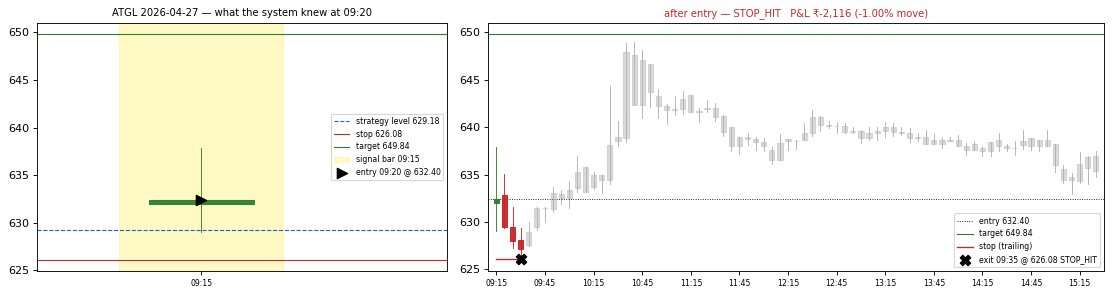


2026-04-28  GRASIM   driver CAMARILLA — CAMARILLA: breakout above H4=2817.29
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 2824.00  (strategy level 2817.29, entry +0.24% vs level)
  stop 2801.14 (-0.81%)   target 2881.86 (+2.05%)   RR 2.53   rank 1
  votes: 7 agreeing, score 21.0, predicted win 50.0% — ADX-FILTER, ASC-TRI, CAMARILLA, CPR, DAILY-BIAS, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: none
  EXIT 13:40 @ 2801.14 (STOP_HIT)   move -0.81%   P&L ₹-1,719 net (-0.87%) on 70 shares


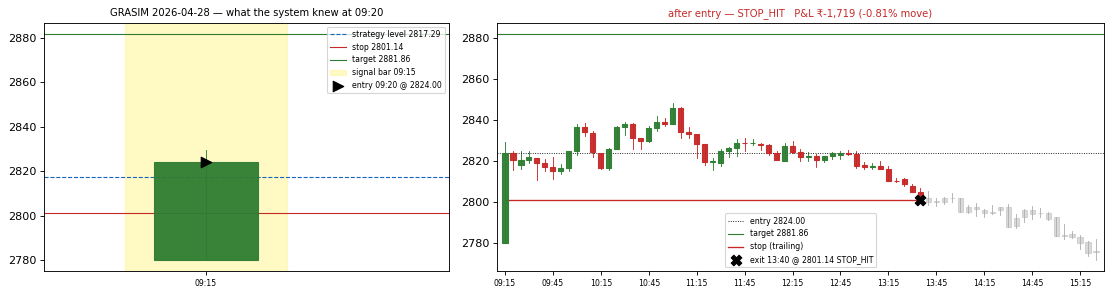


2026-04-29  BSE   driver SUPERTREND — SUPERTREND: flipped bullish, ST=3595.12
  signal bar 09:25 | decided on bars up to 09:25 | ENTRY 09:30 @ 3642.00  (strategy level 3642.00, entry +0.00% vs level)
  stop 3605.58 (-1.00%)   target 3750.14 (+2.97%)   RR 2.00   rank 22
  votes: 6 agreeing, score 15.63, predicted win 49.7% — ADX-FILTER, BULL-FLAG, DAILY-BIAS, PDH-PDL, SUPERTREND, VPOC
  higher-ranked stocks skipped at this scan: BANDHANBNK (FAIL Predicted win pct 52.9% in 50-55% danger zone); EMMVEE (FAIL Predicted win pct 52.9% in 50-55% danger zone); ITC (FAIL Predicted win pct 50.4% in 50-55% danger zone); ADANIPORTS (SKIP viability (stop 0.19x ATR < 0.3))
  EXIT 14:50 @ 3640.80 (TIME_EXIT)   move -0.03%   P&L ₹-183 net (-0.09%) on 54 shares


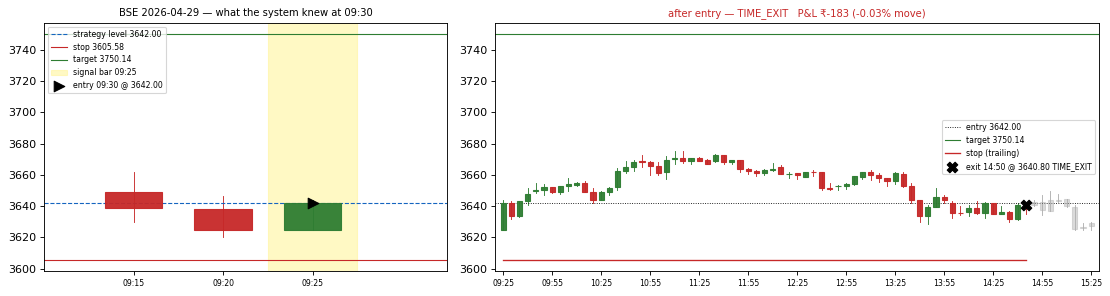


2026-04-30  M&MFIN   driver CAMARILLA — CAMARILLA: reversal at L3=318.47, target H3=324.43
  signal bar 09:30 | decided on bars up to 09:40 | ENTRY 09:45 @ 317.85  (strategy level 318.47, entry -0.19% vs level)
  stop 315.48 (-0.75%)   target 324.43 (+2.07%)   RR 2.78   rank 8
  votes: 5 agreeing, score 18.03, predicted win 47.0% — BOLLINGER, CAMARILLA, CPR, DAILY-BIAS, DBL-BTM, RSI-EXT, VPOC
  higher-ranked stocks skipped at this scan: BAJFINANCE (SKIP price already past stop/target); NAVINFLUOR (FAIL Predicted win pct 52.7% in 50-55% danger zone); HFCL (FAIL Predicted win pct 50.2% in 50-55% danger zone); BHARTIARTL (SKIP RR 1.25 < 1.5 at entry price)
  EXIT 10:15 @ 315.48 (STOP_HIT)   move -0.75%   P&L ₹-1,610 net (-0.81%) on 629 shares


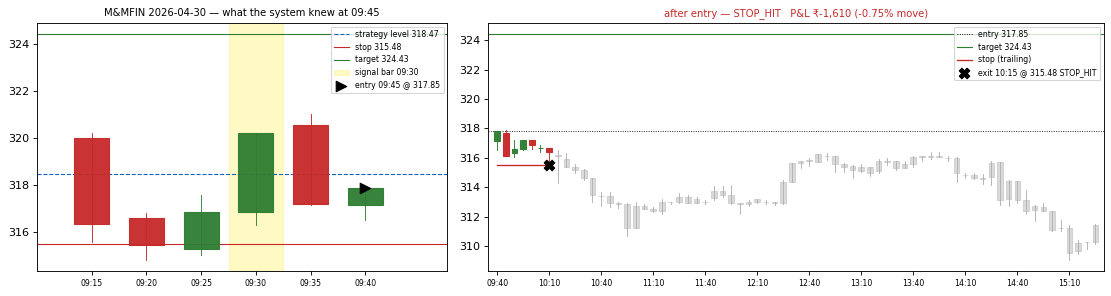

In [8]:
tc.show_month(res, "2026-04")

### May 2026

2026-05: 19 trading days, 19 trades, 10 winners, net ₹+7,483

2026-05-04  MCX   driver CAMARILLA — CAMARILLA: breakout above H4=2997.67
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 3009.10  (strategy level 2997.67, entry +0.38% vs level)
  stop 2981.34 (-0.92%)   target 3063.01 (+1.79%)   RR 1.94   rank 1
  votes: 8 agreeing, score 24.0, predicted win 49.2% — BULL-FLAG, CAMARILLA, CPR, DAILY-BIAS, DBL-BTM, GAP-CONT, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: none
  EXIT 09:35 @ 3025.80 (PROFIT_LOCK_STOP)   move +0.56%   P&L ₹+982 net (+0.49%) on 66 shares


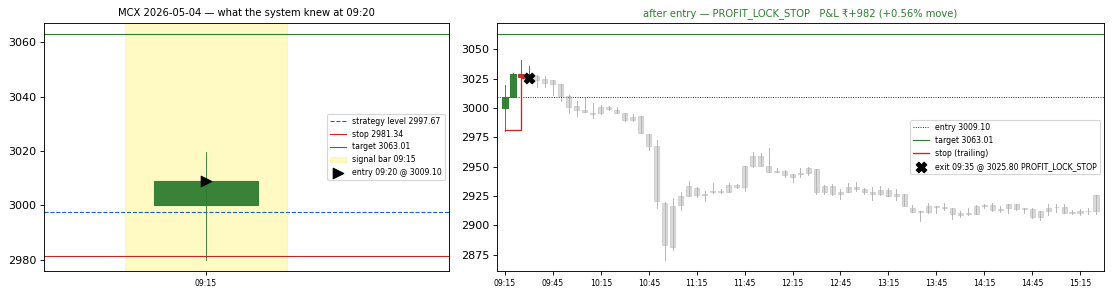


2026-05-05  ABCAPITAL   driver VPOC — VPOC: breakout above VAH=354.84
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 358.45  (strategy level 354.84, entry +1.02% vs level)
  stop 354.87 (-1.00%)   target 368.58 (+2.83%)   RR 1.87   rank 9
  votes: 4 agreeing, score 12.0, predicted win 48.5% — CPR, DAILY-BIAS, DBL-BTM, VPOC
  higher-ranked stocks skipped at this scan: IRCTC (FAIL Predicted win pct 50.9% in 50-55% danger zone); JBCHEPHARM (SKIP viability (stop 0.15x ATR < 0.3)); SYRMA (SKIP geometry (stop 2.43%, target 4.44%)); TORNTPHARM (SKIP RR 1.24 < 1.5 at entry price)
  EXIT 09:30 @ 354.87 (STOP_HIT)   move -1.00%   P&L ₹-2,113 net (-1.06%) on 557 shares


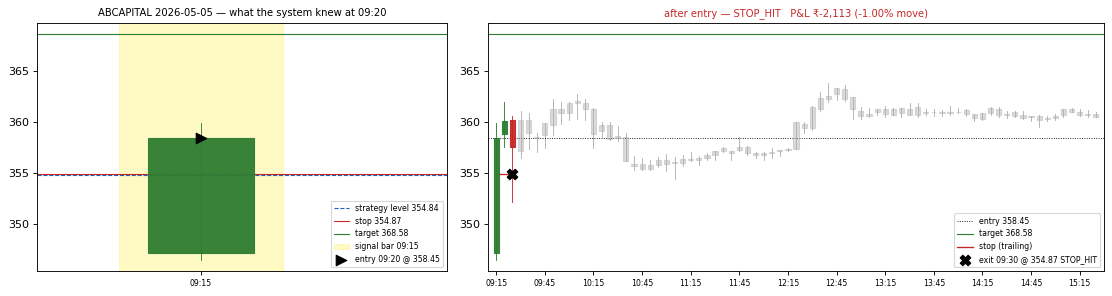


2026-05-06  NETWEB   driver CAMARILLA — CAMARILLA: breakout above H4=4338.16
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 4369.40  (strategy level 4338.16, entry +0.72% vs level)
  stop 4325.71 (-1.00%)   target 4636.48 (+6.11%)   RR 2.52   rank 1
  votes: 7 agreeing, score 21.0, predicted win 49.6% — ADX-FILTER, BULL-FLAG, CAMARILLA, DAILY-BIAS, GAP-CONT, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: none
  EXIT 09:35 @ 4427.75 (PROFIT_LOCK_STOP)   move +1.33%   P&L ₹+2,506 net (+1.27%) on 45 shares


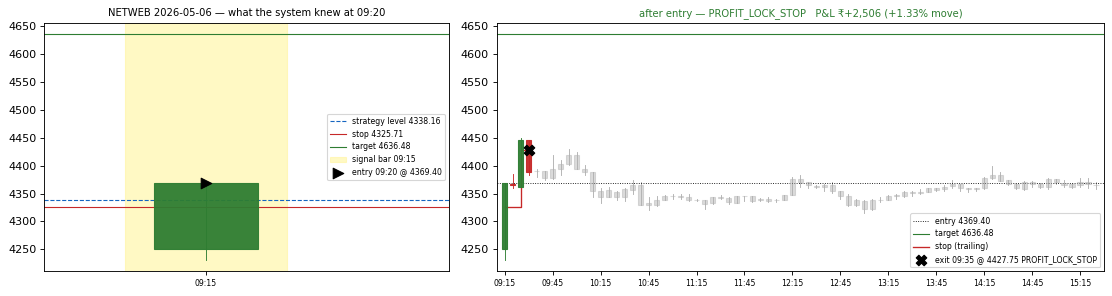


2026-05-07  BAJAJ-AUTO   driver GAP-CONT — GAP-CONT: gap 1.8%, pullback to VWAP=10467.33
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 10421.50  (strategy level 10467.33, entry -0.44% vs level)
  stop 10324.50 (-0.93%)   target 10753.00 (+3.18%)   RR 3.42   rank 1
  votes: 6 agreeing, score 18.0, predicted win 49.0% — ADX-FILTER, DAILY-BIAS, DBL-BTM, GAP-CONT, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: none
  EXIT 09:50 @ 10686.30 (PROFIT_LOCK_STOP)   move +2.54%   P&L ₹+4,911 net (+2.48%) on 19 shares


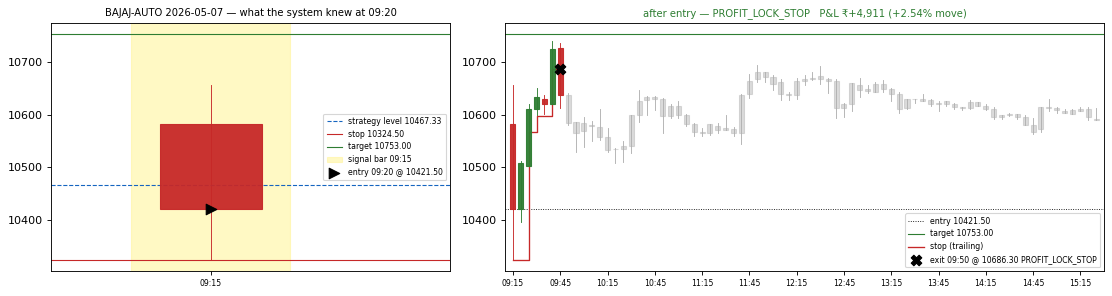


2026-05-08  BEML   driver VPOC — VPOC: breakout above VAH=2015.29
  signal bar 09:20 | decided on bars up to 09:20 | ENTRY 09:25 @ 2022.70  (strategy level 2015.29, entry +0.37% vs level)
  stop 2002.47 (-1.00%)   target 2115.71 (+4.60%)   RR 3.71   rank 11
  votes: 5 agreeing, score 15.0, predicted win 49.9% — ADX-FILTER, BULL-FLAG, DAILY-BIAS, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: CONCOR (SKIP geometry (stop 4.97%, target 16.68%)); PNBHOUSING (SKIP geometry (stop 5.14%, target 29.75%)); ANGELONE (SKIP RR 0.84 < 1.5 at entry price); APOLLOHOSP (SKIP RR 0.57 < 1.5 at entry price)
  EXIT 09:35 @ 2002.47 (STOP_HIT)   move -1.00%   P&L ₹-2,101 net (-1.06%) on 98 shares


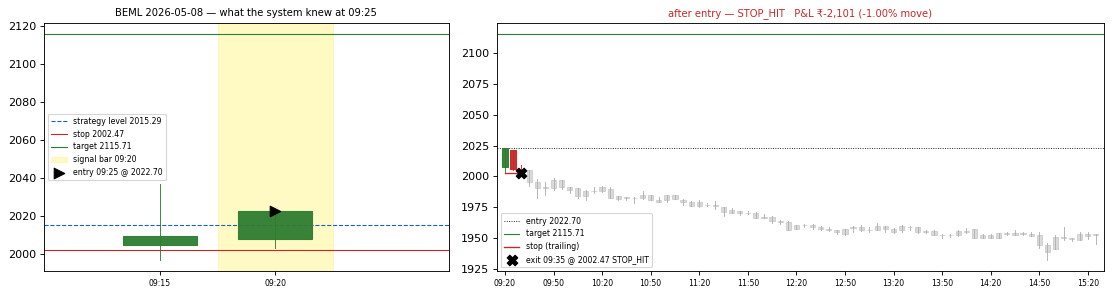


2026-05-11  MARICO   driver FIRST-CANDLE — FIRST-CANDLE: break above first candle high=833.05
  signal bar 09:20 | decided on bars up to 09:20 | ENTRY 09:25 @ 833.45  (strategy level 833.05, entry +0.05% vs level)
  stop 825.12 (-1.00%)   target 849.55 (+1.93%)   RR 1.86   rank 10
  votes: 5 agreeing, score 15.0, predicted win 50.0% — CAMARILLA, CPR, DAILY-BIAS, DBL-BTM, FIRST-CANDLE
  higher-ranked stocks skipped at this scan: TORNTPHARM (SKIP RR 0.90 < 1.5 at entry price); MAXHEALTH (SKIP price already past stop/target); SOLARINDS (FAIL Predicted win pct 50.6% in 50-55% danger zone); UNOMINDA (SKIP RR 1.31 < 1.5 at entry price)
  EXIT 14:50 @ 846.55 (TIME_EXIT)   move +1.57%   P&L ₹+3,010 net (+1.51%) on 239 shares


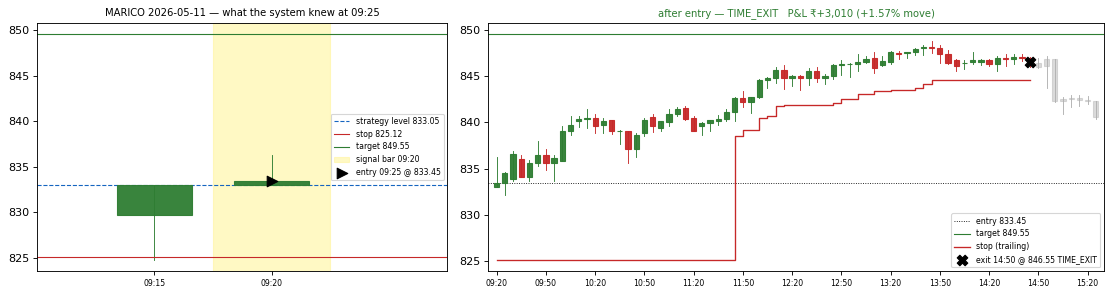


2026-05-12  PIDILITIND   driver CAMARILLA — CAMARILLA: breakout above H4=1455.17
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 1457.60  (strategy level 1455.17, entry +0.17% vs level)
  stop 1445.14 (-0.85%)   target 1495.33 (+2.59%)   RR 3.03   rank 4
  votes: 5 agreeing, score 15.0, predicted win 49.5% — ADX-FILTER, CAMARILLA, DAILY-BIAS, DBL-BTM, VPOC
  higher-ranked stocks skipped at this scan: HINDCOPPER (SKIP RR 0.65 < 1.5 at entry price); ONGC (SKIP price already past stop/target); OIL (SKIP price already past stop/target)
  EXIT 09:40 @ 1445.14 (STOP_HIT)   move -0.85%   P&L ₹-1,826 net (-0.91%) on 137 shares


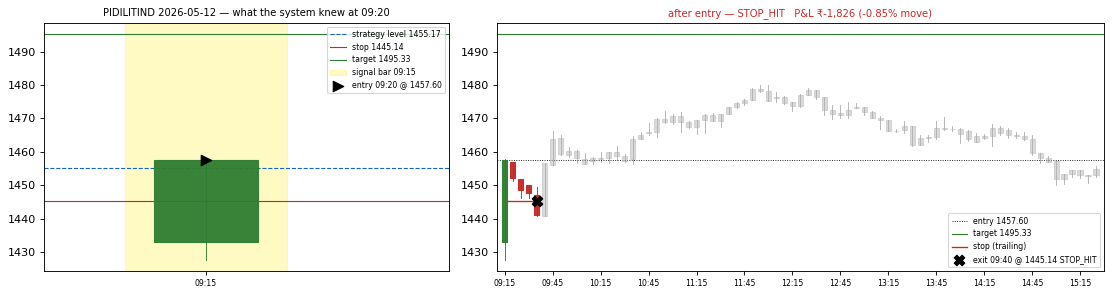


2026-05-13  HINDCOPPER   driver CAMARILLA — CAMARILLA: breakout above H4=585.07
  signal bar 09:20 | decided on bars up to 09:20 | ENTRY 09:25 @ 585.20  (strategy level 585.07, entry +0.02% vs level)
  stop 579.35 (-1.00%)   target 620.22 (+5.98%)   RR 3.93   rank 3
  votes: 5 agreeing, score 15.0, predicted win 48.5% — ADX-FILTER, CAMARILLA, DAILY-BIAS, DBL-BTM, GAP-CONT
  higher-ranked stocks skipped at this scan: CARTRADE (FAIL Predicted win pct 51.1% in 50-55% danger zone); HINDZINC (SKIP price already past stop/target)
  EXIT 09:40 @ 579.35 (STOP_HIT)   move -1.00%   P&L ₹-2,114 net (-1.06%) on 341 shares


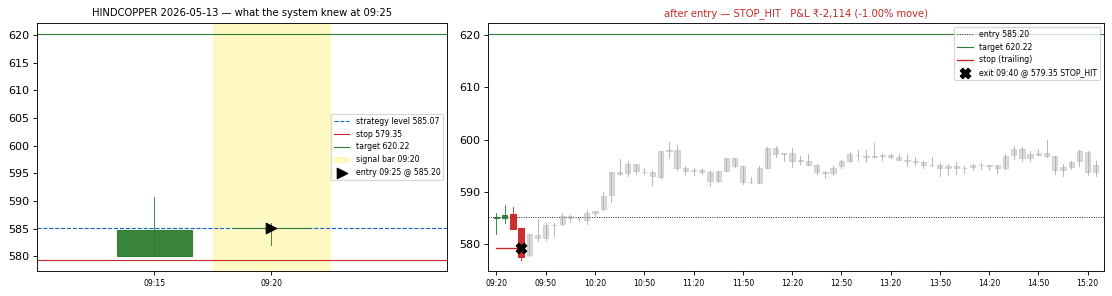


2026-05-14  AUROPHARMA   driver CAMARILLA — CAMARILLA: breakout above H4=1514.31
  signal bar 09:20 | decided on bars up to 09:20 | ENTRY 09:25 @ 1520.90  (strategy level 1514.31, entry +0.43% vs level)
  stop 1507.11 (-0.91%)   target 1543.13 (+1.46%)   RR 1.61   rank 7
  votes: 7 agreeing, score 21.0, predicted win 49.2% — ADX-FILTER, CAMARILLA, CPR, DAILY-BIAS, MACD, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: NLCINDIA (SKIP price already past stop/target); ZYDUSLIFE (SKIP price already past stop/target); ADANIENT (SKIP RR 0.22 < 1.5 at entry price); GRASIM (SKIP geometry (stop 0.21%, target 0.42%))
  EXIT 10:00 @ 1506.70 (STOP_HIT)   move -0.93%   P&L ₹-1,979 net (-0.99%) on 131 shares


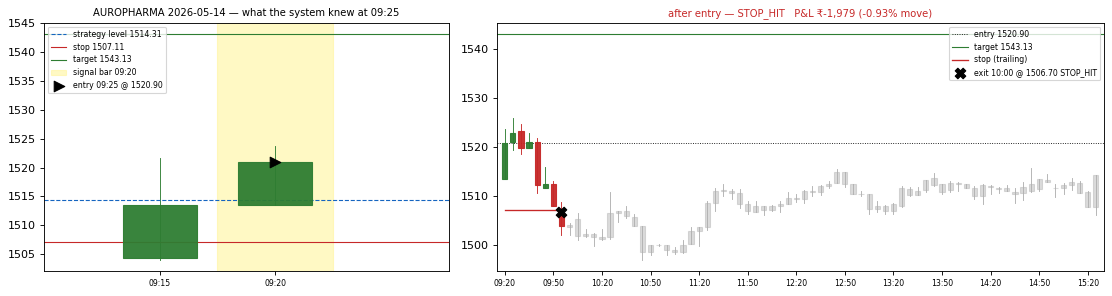


2026-05-15  KPITTECH   driver CAMARILLA — CAMARILLA: breakout above H4=718.99
  signal bar 09:20 | decided on bars up to 09:20 | ENTRY 09:25 @ 723.30  (strategy level 718.99, entry +0.60% vs level)
  stop 716.07 (-1.00%)   target 745.06 (+3.01%)   RR 2.01   rank 4
  votes: 7 agreeing, score 21.0, predicted win 49.8% — ADX-FILTER, CAMARILLA, CPR, FIRST-CANDLE, MACD, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: GESHIP (SKIP price already past stop/target); COFORGE (FAIL Predicted win pct 50.7% in 50-55% danger zone); HCLTECH (SKIP geometry (stop 3.36%, target 18.92%))
  EXIT 09:35 @ 716.07 (STOP_HIT)   move -1.00%   P&L ₹-2,115 net (-1.06%) on 276 shares


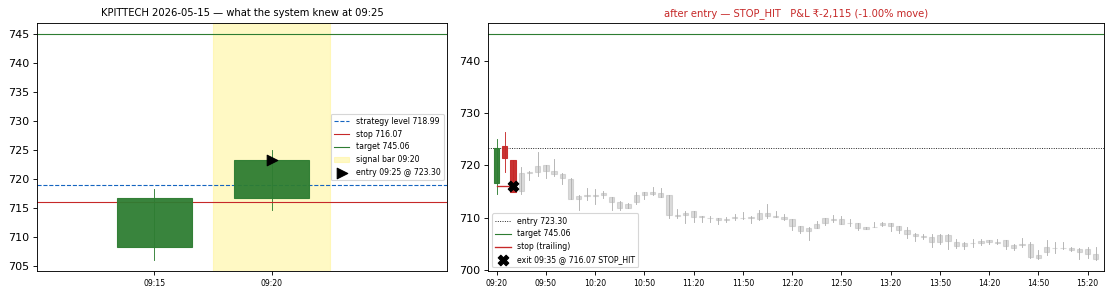


2026-05-18  COFORGE   driver FIRST-CANDLE — FIRST-CANDLE: break above first candle high=1293.20
  signal bar 09:20 | decided on bars up to 09:20 | ENTRY 09:25 @ 1294.30  (strategy level 1293.20, entry +0.09% vs level)
  stop 1281.36 (-1.00%)   target 1330.40 (+2.79%)   RR 1.83   rank 11
  votes: 5 agreeing, score 10.17, predicted win 49.2% — DAILY-BIAS, DBL-BTM, EMA-CROSS, FIRST-CANDLE, SUPERTREND
  higher-ranked stocks skipped at this scan: INDUSTOWER (SKIP RR 0.77 < 1.5 at entry price); ONESOURCE (SKIP viability (stop 0.21x ATR < 0.3)); UNOMINDA (FAIL Predicted win pct 50.9% in 50-55% danger zone); GESHIP (SKIP geometry (stop 3.27%, target 6.53%))
  EXIT 11:10 @ 1310.50 (PROFIT_LOCK_STOP)   move +1.25%   P&L ₹+2,374 net (+1.19%) on 154 shares


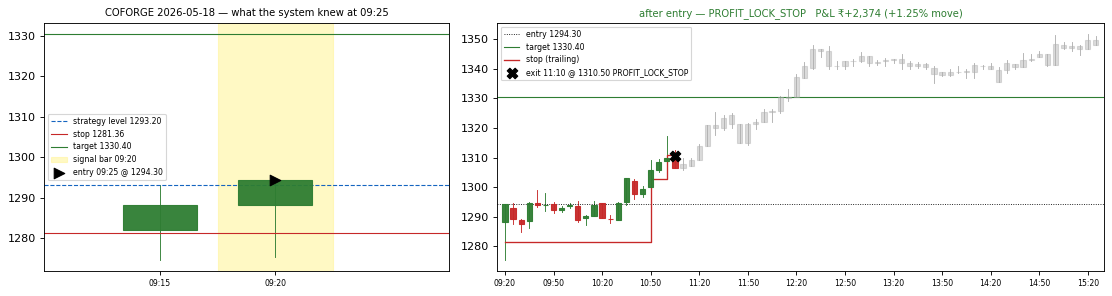


2026-05-19  URBANCO   driver FIRST-CANDLE — FIRST-CANDLE: break above first candle high=123.79
  signal bar 09:20 | decided on bars up to 09:20 | ENTRY 09:25 @ 124.12  (strategy level 123.79, entry +0.27% vs level)
  stop 122.88 (-1.00%)   target 127.95 (+3.09%)   RR 1.59   rank 4
  votes: 7 agreeing, score 18.63, predicted win 48.3% — ADX-FILTER, CPR, FIRST-CANDLE, GAP-CONT, MACD, PDH-PDL, SUPERTREND
  higher-ranked stocks skipped at this scan: SAIL (SKIP viability (stop 0.26x ATR < 0.3)); ADANIENT (SKIP price already past stop/target); PIIND (SKIP viability (stop 0.29x ATR < 0.3))
  EXIT 13:15 @ 122.88 (STOP_HIT)   move -1.00%   P&L ₹-2,117 net (-1.06%) on 1611 shares


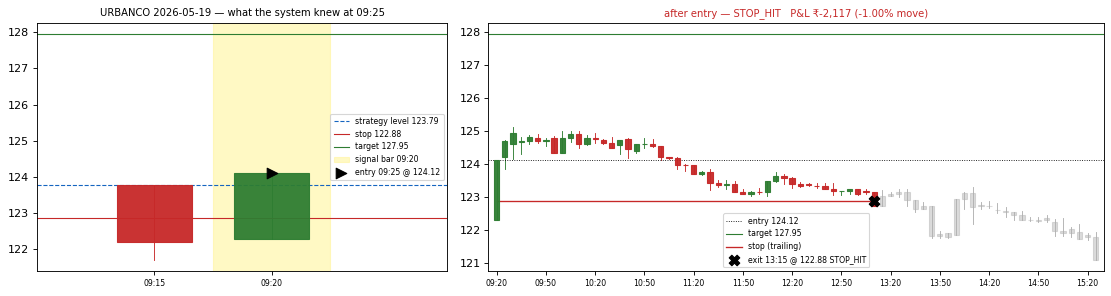


2026-05-20  MANKIND   driver CAMARILLA — CAMARILLA: breakout above H4=2513.95
  signal bar 09:15 | decided on bars up to 09:20 | ENTRY 09:25 @ 2521.20  (strategy level 2513.95, entry +0.29% vs level)
  stop 2495.99 (-1.00%)   target 2601.84 (+3.20%)   RR 2.76   rank 6
  votes: 5 agreeing, score 15.0, predicted win 47.5% — ADX-FILTER, CAMARILLA, DAILY-BIAS, GAP-CONT, MACD
  higher-ranked stocks skipped at this scan: ZENTEC (SKIP RR 0.67 < 1.5 at entry price); LAURUSLABS (SKIP price already past stop/target); ONESOURCE (SKIP RR 1.21 < 1.5 at entry price); WOCKPHARMA (FAIL Predicted win pct 50.7% in 50-55% danger zone)
  EXIT 09:35 @ 2556.80 (PROFIT_LOCK_STOP)   move +1.41%   P&L ₹+2,692 net (+1.35%) on 79 shares


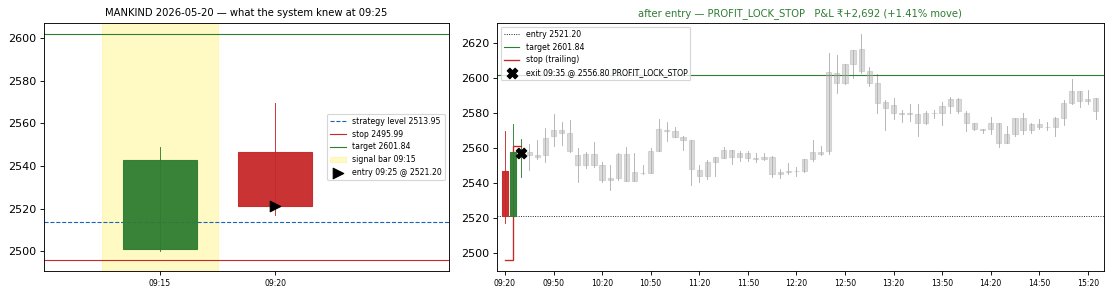


2026-05-21  CUMMINSIND   driver VPOC — VPOC: breakout above VAH=5404.55
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 5419.50  (strategy level 5404.55, entry +0.28% vs level)
  stop 5373.24 (-0.85%)   target 5621.29 (+3.72%)   RR 4.36   rank 6
  votes: 5 agreeing, score 15.0, predicted win 49.9% — ADX-FILTER, ASC-TRI, DAILY-BIAS, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: GRAPHITE (FAIL Predicted win pct 50.2% in 50-55% danger zone); GRASIM (SKIP RR 0.06 < 1.5 at entry price); IFCI (SKIP RR 0.12 < 1.5 at entry price); GMDCLTD (SKIP viability (stop 0.27x ATR < 0.3))
  EXIT 10:10 @ 5373.24 (STOP_HIT)   move -0.85%   P&L ₹-1,783 net (-0.91%) on 36 shares


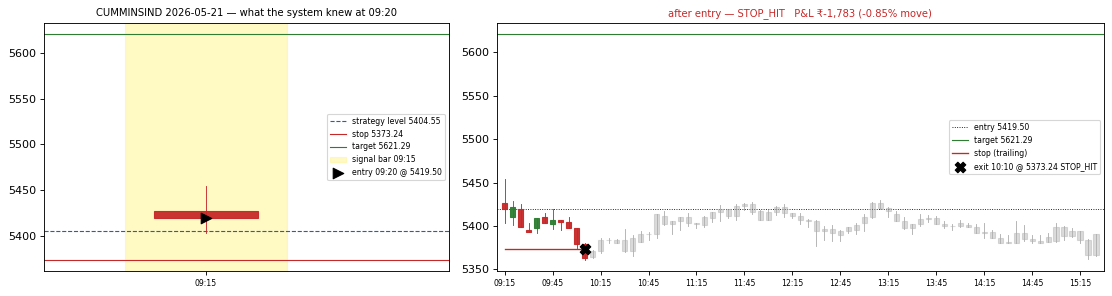


2026-05-22  GRANULES   driver FIRST-CANDLE — FIRST-CANDLE: break above first candle high=767.50
  signal bar 09:20 | decided on bars up to 09:20 | ENTRY 09:25 @ 768.05  (strategy level 767.50, entry +0.07% vs level)
  stop 760.37 (-1.00%)   target 785.40 (+2.26%)   RR 1.83   rank 4
  votes: 6 agreeing, score 15.63, predicted win 48.9% — CAMARILLA, CPR, DAILY-BIAS, FIRST-CANDLE, MACD, SUPERTREND
  higher-ranked stocks skipped at this scan: NYKAA (SKIP price already past stop/target); DIXON (FAIL Predicted win pct 50.1% in 50-55% danger zone); HFCL (SKIP viability (stop 0.04x ATR < 0.3))
  EXIT 11:10 @ 760.37 (STOP_HIT)   move -1.00%   P&L ₹-2,116 net (-1.06%) on 260 shares


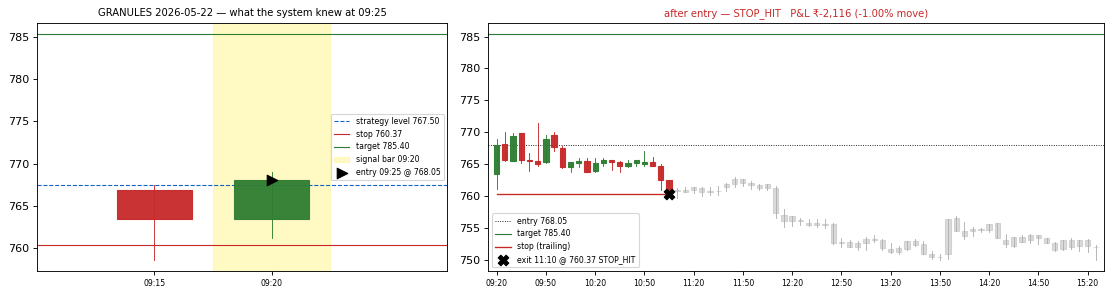


2026-05-25  TORNTPHARM   driver CAMARILLA — CAMARILLA: breakout above H4=4548.86
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 4570.00  (strategy level 4548.86, entry +0.47% vs level)
  stop 4524.30 (-1.00%)   target 4652.59 (+1.81%)   RR 1.75   rank 6
  votes: 7 agreeing, score 21.0, predicted win 50.0% — ADX-FILTER, ASC-TRI, CAMARILLA, CPR, DAILY-BIAS, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: HFCL (SKIP price already past stop/target); TMPV (SKIP geometry (stop 0.08%, target 0.44%)); ABCAPITAL (SKIP RR 0.67 < 1.5 at entry price); BAJAJ-AUTO (SKIP RR 1.03 < 1.5 at entry price)
  EXIT 09:35 @ 4621.77 (PROFIT_LOCK_STOP)   move +1.13%   P&L ₹+2,107 net (+1.07%) on 43 shares


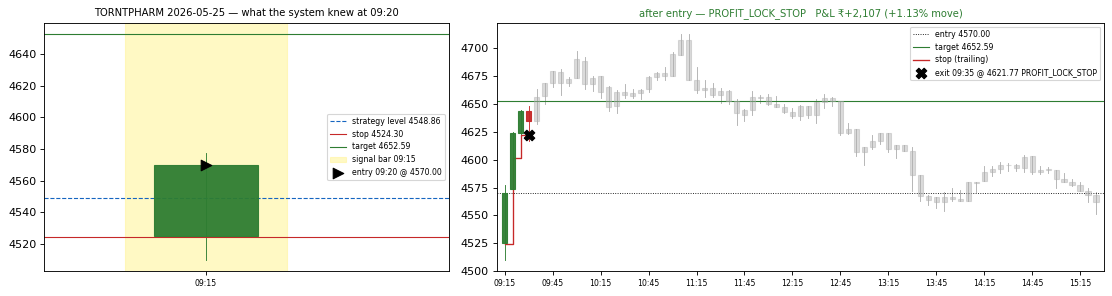


2026-05-26  ADANIPOWER   driver VPOC — VPOC: breakout above VAH=234.31
  signal bar 09:15 | decided on bars up to 09:20 | ENTRY 09:25 @ 236.82  (strategy level 234.31, entry +1.07% vs level)
  stop 234.45 (-1.00%)   target 247.72 (+4.60%)   RR 2.32   rank 10
  votes: 6 agreeing, score 18.0, predicted win 49.6% — ADX-FILTER, DAILY-BIAS, FIRST-CANDLE, MACD, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: HFCL (FAIL Predicted win pct 50.1% in 50-55% danger zone); GRANULES (FAIL Predicted win pct 50.7% in 50-55% danger zone); ACUTAAS (FAIL Predicted win pct 50.7% in 50-55% danger zone); BANDHANBNK (FAIL Predicted win pct 50.7% in 50-55% danger zone)
  EXIT 10:15 @ 241.19 (PROFIT_LOCK_STOP)   move +1.84%   P&L ₹+3,567 net (+1.78%) on 844 shares


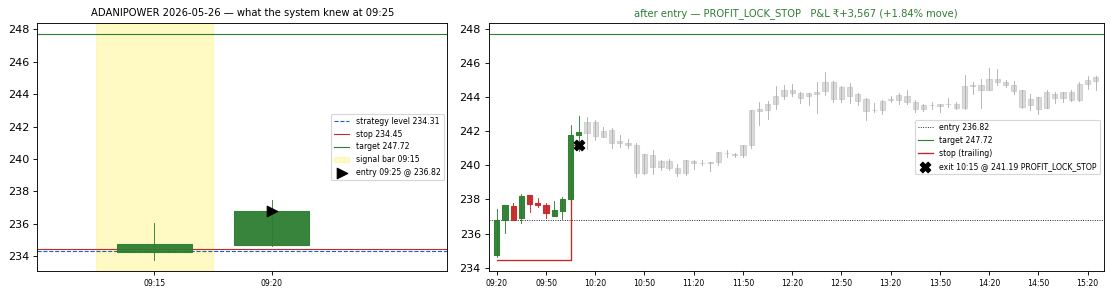


2026-05-27  JSWSTEEL   driver CAMARILLA — CAMARILLA: breakout above H4=1303.66
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 1306.10  (strategy level 1303.66, entry +0.19% vs level)
  stop 1298.63 (-0.57%)   target 1323.80 (+1.36%)   RR 2.37   rank 3
  votes: 7 agreeing, score 21.0, predicted win 50.0% — ADX-FILTER, ASC-TRI, CAMARILLA, CPR, DAILY-BIAS, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: HINDALCO (SKIP RR 0.03 < 1.5 at entry price); CUMMINSIND (SKIP RR 0.88 < 1.5 at entry price)
  EXIT 10:55 @ 1321.36 (PROFIT_LOCK_STOP)   move +1.17%   P&L ₹+2,214 net (+1.11%) on 153 shares


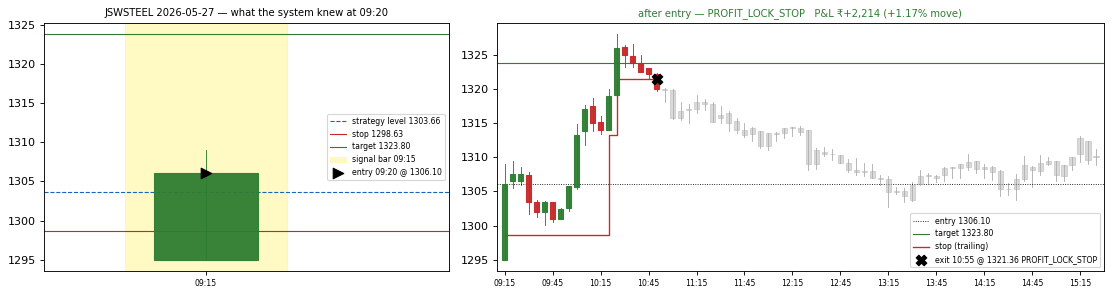


2026-05-29  IFCI   driver VPOC — VPOC: breakout above VAH=68.52
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 69.18  (strategy level 68.52, entry +0.97% vs level)
  stop 68.49 (-1.00%)   target 71.64 (+3.56%)   RR 1.82   rank 11
  votes: 5 agreeing, score 15.0, predicted win 49.8% — ADX-FILTER, DAILY-BIAS, DBL-BTM, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: HBLENGINE (SKIP price already past stop/target); POLYCAB (SKIP viability (stop 0.13x ATR < 0.3)); NAUKRI (SKIP RR 0.21 < 1.5 at entry price); NLCINDIA (SKIP viability (stop 0.06x ATR < 0.3))
  EXIT 10:00 @ 69.70 (PROFIT_LOCK_STOP)   move +0.75%   P&L ₹+1,383 net (+0.69%) on 2891 shares


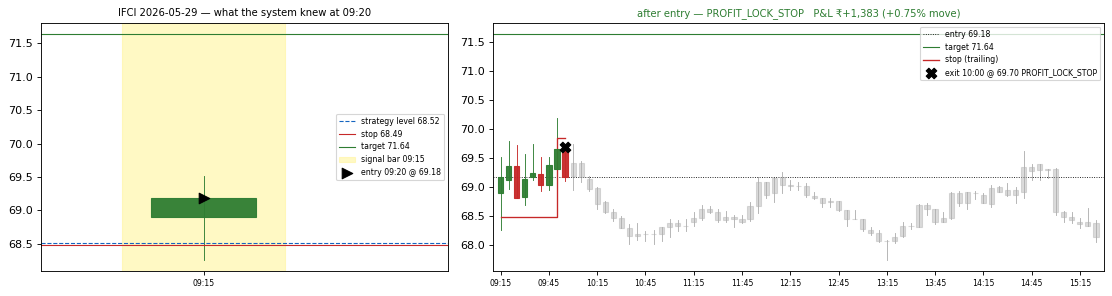

In [9]:
tc.show_month(res, "2026-05")

### June 2026

2026-06: 21 trading days, 21 trades, 11 winners, net ₹-3,825

2026-06-01  NETWEB   driver VPOC — VPOC: breakout above VAH=4731.03
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 4822.70  (strategy level 4731.03, entry +1.94% vs level)
  stop 4774.47 (-1.00%)   target 5136.63 (+6.51%)   RR 1.83   rank 2
  votes: 6 agreeing, score 18.0, predicted win 49.0% — ADX-FILTER, DAILY-BIAS, DBL-BTM, GAP-CONT, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: INDIGO (SKIP RR 1.04 < 1.5 at entry price)
  EXIT 09:30 @ 4774.47 (STOP_HIT)   move -1.00%   P&L ₹-2,096 net (-1.06%) on 41 shares


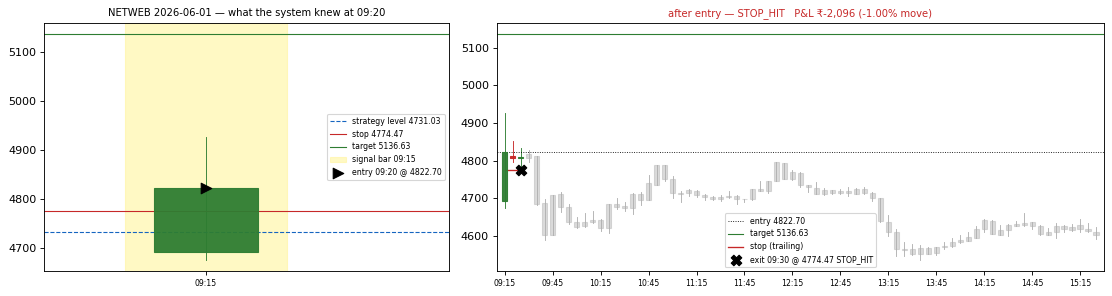


2026-06-02  TATAELXSI   driver CAMARILLA — CAMARILLA: breakout above H4=4348.07
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 4356.90  (strategy level 4348.07, entry +0.20% vs level)
  stop 4323.48 (-0.77%)   target 4446.41 (+2.05%)   RR 2.68   rank 11
  votes: 4 agreeing, score 12.0, predicted win 50.0% — ADX-FILTER, CAMARILLA, DAILY-BIAS, VPOC
  higher-ranked stocks skipped at this scan: INFY (SKIP price already past stop/target); SYRMA (FAIL Predicted win pct 50.9% in 50-55% danger zone); ANANTRAJ (FAIL Predicted win pct 50.3% in 50-55% danger zone); OFSS (FAIL Predicted win pct 50.3% in 50-55% danger zone)
  EXIT 09:35 @ 4379.99 (PROFIT_LOCK_STOP)   move +0.53%   P&L ₹+920 net (+0.47%) on 45 shares


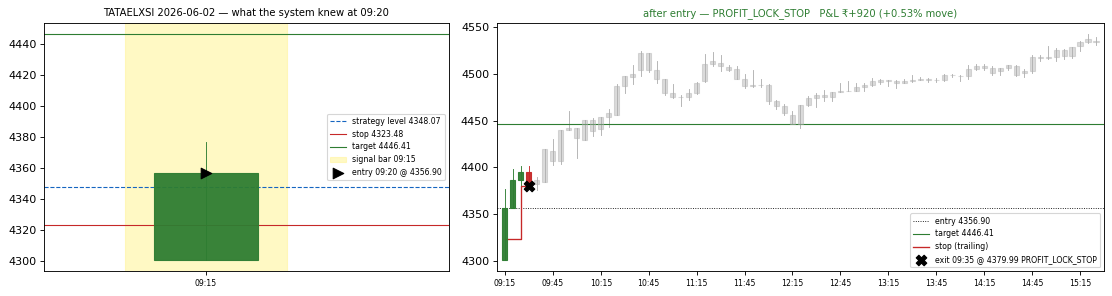


2026-06-03  ADANIPORTS   driver VPOC — VPOC: breakout above VAH=1817.80
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 1834.70  (strategy level 1817.80, entry +0.93% vs level)
  stop 1816.35 (-1.00%)   target 1869.66 (+1.91%)   RR 1.83   rank 2
  votes: 5 agreeing, score 15.0, predicted win 49.9% — ADX-FILTER, ASC-TRI, DAILY-BIAS, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: RRKABEL (FAIL Predicted win pct 50.3% in 50-55% danger zone)
  EXIT 09:55 @ 1816.35 (STOP_HIT)   move -1.00%   P&L ₹-2,119 net (-1.06%) on 109 shares


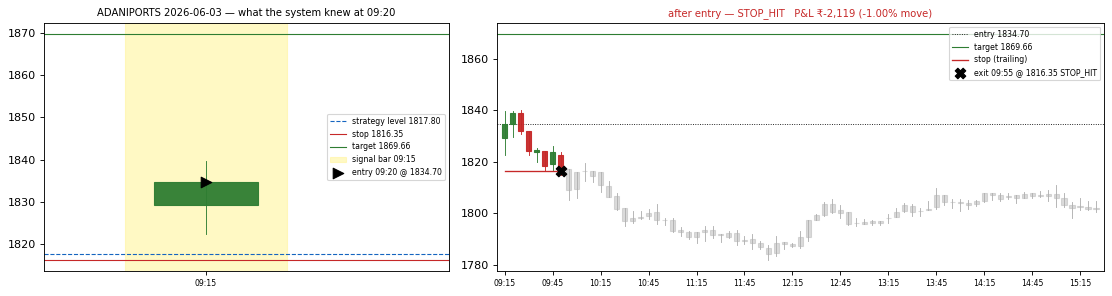


2026-06-04  SYRMA   driver VPOC — VPOC: breakout above VAH=1208.87
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 1209.00  (strategy level 1208.87, entry +0.01% vs level)
  stop 1196.91 (-1.00%)   target 1251.56 (+3.52%)   RR 2.64   rank 9
  votes: 4 agreeing, score 12.0, predicted win 48.7% — ADX-FILTER, DAILY-BIAS, DBL-BTM, VPOC
  higher-ranked stocks skipped at this scan: GRASIM (SKIP viability (stop 0.08x ATR < 0.3)); ZENTEC (FAIL Predicted win pct 50.8% in 50-55% danger zone); CEMPRO (FAIL Predicted win pct 50.9% in 50-55% danger zone); CUMMINSIND (FAIL Predicted win pct 50.7% in 50-55% danger zone)
  EXIT 09:30 @ 1213.80 (PROFIT_LOCK_STOP)   move +0.40%   P&L ₹+672 net (+0.34%) on 165 shares


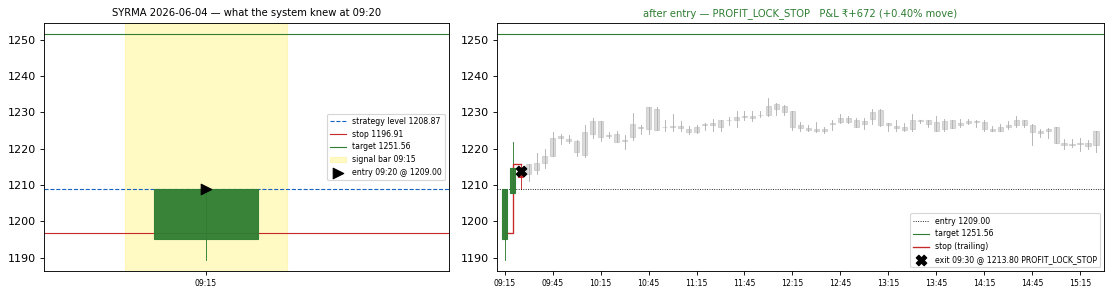


2026-06-05  JYOTICNC   driver CAMARILLA — CAMARILLA: breakout above H4=606.74
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 611.10  (strategy level 606.74, entry +0.72% vs level)
  stop 604.99 (-1.00%)   target 625.11 (+2.29%)   RR 1.56   rank 10
  votes: 5 agreeing, score 15.0, predicted win 49.9% — CAMARILLA, CPR, GAP-CONT, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: APARINDS (FAIL Predicted win pct 50.3% in 50-55% danger zone); ACUTAAS (FAIL Predicted win pct 50.2% in 50-55% danger zone); FSL (FAIL Predicted win pct 50.2% in 50-55% danger zone); APOLLOHOSP (FAIL Predicted win pct 50.7% in 50-55% danger zone)
  EXIT 09:35 @ 616.20 (PROFIT_LOCK_STOP)   move +0.83%   P&L ₹+1,547 net (+0.77%) on 327 shares


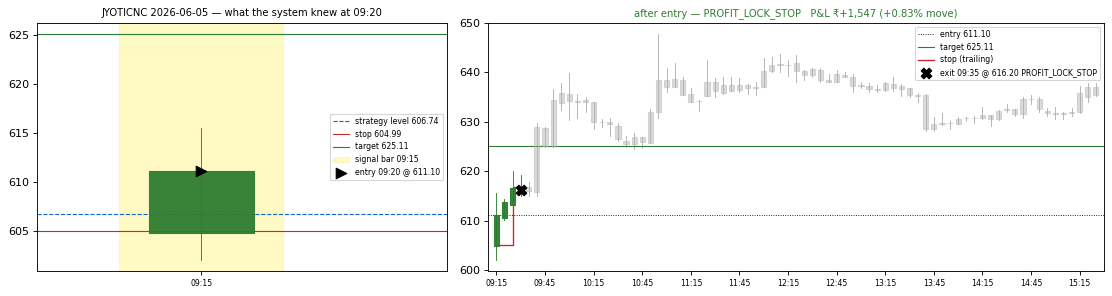


2026-06-08  TATATECH   driver CAMARILLA — CAMARILLA: reversal at L3=768.70, target H3=783.00
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 769.95  (strategy level 768.70, entry +0.16% vs level)
  stop 762.25 (-1.00%)   target 783.00 (+1.69%)   RR 1.55   rank 10
  votes: 4 agreeing, score 12.0, predicted win 49.2% — ADX-FILTER, CAMARILLA, CPR, DAILY-BIAS
  higher-ranked stocks skipped at this scan: ACUTAAS (FAIL Predicted win pct 50.7% in 50-55% danger zone); GLAND (FAIL Predicted win pct 50.9% in 50-55% danger zone); FEDERALBNK (SKIP RR 0.77 < 1.5 at entry price); SAILIFE (FAIL Predicted win pct 50.8% in 50-55% danger zone)
  EXIT 11:00 @ 777.10 (PROFIT_LOCK_STOP)   move +0.93%   P&L ₹+1,732 net (+0.87%) on 259 shares


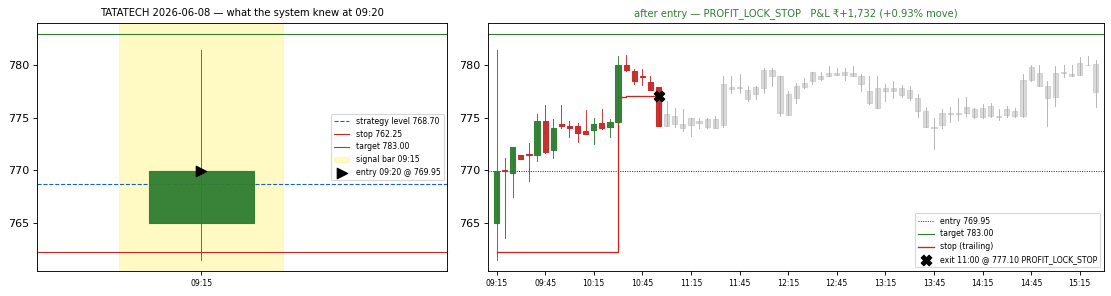


2026-06-09  MOTHERSON   driver CAMARILLA — CAMARILLA: breakout above H4=140.74
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 141.62  (strategy level 140.74, entry +0.62% vs level)
  stop 140.20 (-1.00%)   target 145.82 (+2.97%)   RR 1.95   rank 5
  votes: 5 agreeing, score 15.0, predicted win 49.0% — ADX-FILTER, CAMARILLA, DAILY-BIAS, GAP-CONT, VPOC
  higher-ranked stocks skipped at this scan: SYRMA (SKIP RR 0.54 < 1.5 at entry price); BELRISE (SKIP RR 0.86 < 1.5 at entry price); IDFCFIRSTB (SKIP RR 0.44 < 1.5 at entry price); ETERNAL (SKIP viability (stop 0.28x ATR < 0.3))
  EXIT 12:55 @ 142.72 (PROFIT_LOCK_STOP)   move +0.78%   P&L ₹+1,433 net (+0.72%) on 1412 shares


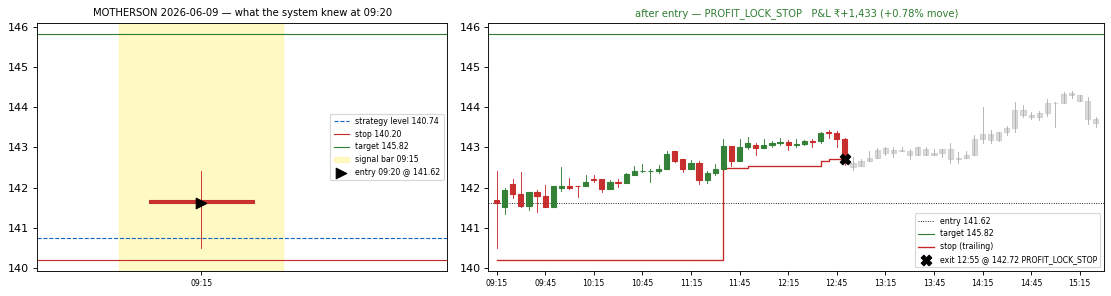


2026-06-10  SBIN   driver VPOC — VPOC: breakout above VAH=1007.41
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 1008.35  (strategy level 1007.41, entry +0.09% vs level)
  stop 1001.84 (-0.65%)   target 1028.10 (+1.96%)   RR 3.03   rank 9
  votes: 4 agreeing, score 12.0, predicted win 48.7% — ADX-FILTER, DAILY-BIAS, DBL-BTM, VPOC
  higher-ranked stocks skipped at this scan: PIDILITIND (FAIL Predicted win pct 50.9% in 50-55% danger zone); PIRAMALFIN (FAIL Predicted win pct 50.8% in 50-55% danger zone); CEMPRO (SKIP viability (stop 0.19x ATR < 0.3)); COLPAL (FAIL Predicted win pct 50.5% in 50-55% danger zone)
  EXIT 14:40 @ 1001.84 (STOP_HIT)   move -0.65%   P&L ₹-1,408 net (-0.71%) on 198 shares


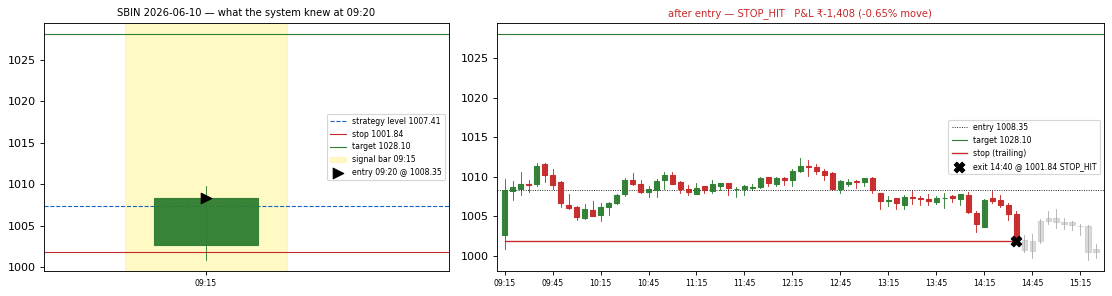


2026-06-11  SAILIFE   driver FIRST-CANDLE — FIRST-CANDLE: break above first candle high=1194.80
  signal bar 09:20 | decided on bars up to 09:20 | ENTRY 09:25 @ 1197.00  (strategy level 1194.80, entry +0.18% vs level)
  stop 1185.03 (-1.00%)   target 1229.00 (+2.67%)   RR 1.66   rank 6
  votes: 5 agreeing, score 12.63, predicted win 48.0% — DAILY-BIAS, DBL-BTM, FIRST-CANDLE, MACD, SUPERTREND
  higher-ranked stocks skipped at this scan: TEJASNET (FAIL Predicted win pct 51.1% in 50-55% danger zone); NETWEB (SKIP viability (stop 0.11x ATR < 0.3)); ADANIENT (SKIP viability (stop 0.16x ATR < 0.3)); SBIN (FAIL Predicted win pct 50.6% in 50-55% danger zone)
  EXIT 11:55 @ 1185.03 (STOP_HIT)   move -1.00%   P&L ₹-2,118 net (-1.06%) on 167 shares


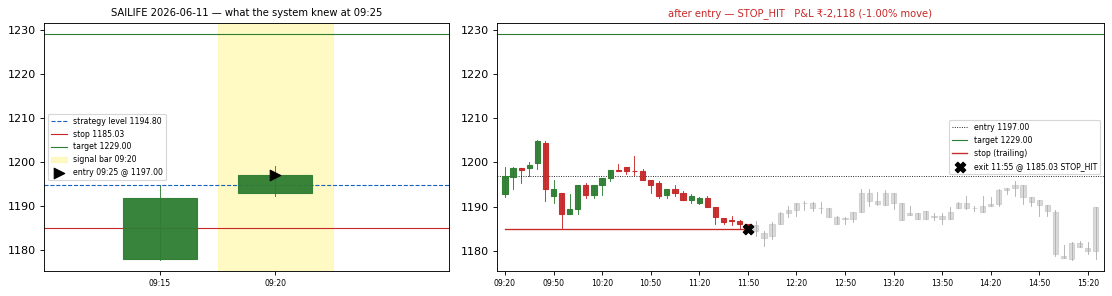


2026-06-12  BELRISE   driver CAMARILLA — CAMARILLA: breakout above H4=227.24
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 227.69  (strategy level 227.24, entry +0.20% vs level)
  stop 225.41 (-1.00%)   target 236.46 (+3.85%)   RR 3.18   rank 1
  votes: 8 agreeing, score 24.0, predicted win 49.3% — ADX-FILTER, CAMARILLA, CPR, DAILY-BIAS, DBL-BTM, GAP-CONT, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: none
  EXIT 09:45 @ 225.41 (STOP_HIT)   move -1.00%   P&L ₹-2,121 net (-1.06%) on 878 shares


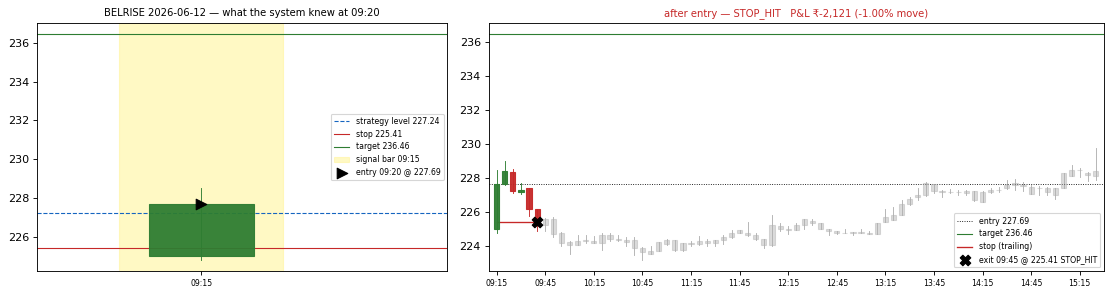


2026-06-15  INDHOTEL   driver CAMARILLA — CAMARILLA: breakout above H4=692.10
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 693.20  (strategy level 692.10, entry +0.16% vs level)
  stop 686.27 (-1.00%)   target 717.29 (+3.48%)   RR 3.26   rank 4
  votes: 7 agreeing, score 21.0, predicted win 49.6% — ADX-FILTER, ASC-TRI, CAMARILLA, DAILY-BIAS, GAP-CONT, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: BANKINDIA (SKIP RR 1.39 < 1.5 at entry price); BPCL (SKIP RR 0.75 < 1.5 at entry price); GAIL (SKIP RR 0.20 < 1.5 at entry price)
  EXIT 14:50 @ 691.95 (TIME_EXIT)   move -0.18%   P&L ₹-480 net (-0.24%) on 288 shares


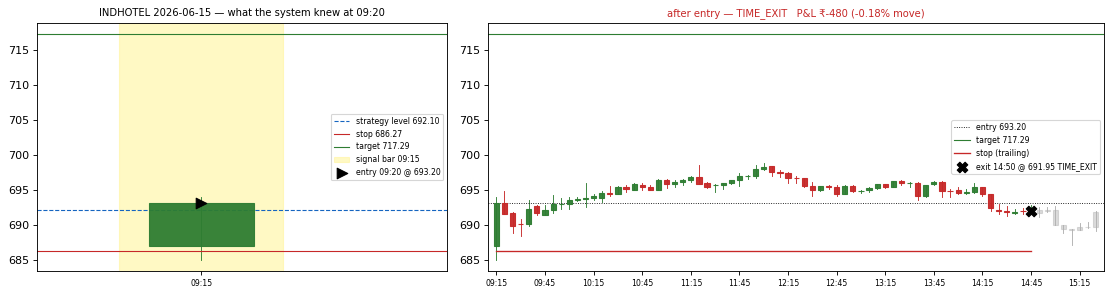


2026-06-16  CDSL   driver VPOC — VPOC: breakout above VAH=1273.00
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 1275.50  (strategy level 1273.00, entry +0.20% vs level)
  stop 1265.34 (-0.80%)   target 1295.73 (+1.59%)   RR 1.99   rank 6
  votes: 5 agreeing, score 15.0, predicted win 49.7% — ADX-FILTER, CPR, DAILY-BIAS, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: GMRAIRPORT (SKIP RR 1.11 < 1.5 at entry price); CEMPRO (SKIP RR 0.03 < 1.5 at entry price); ADANIENT (SKIP viability (stop 0.04x ATR < 0.3)); TATACAP (SKIP RR 0.16 < 1.5 at entry price)
  EXIT 10:15 @ 1265.34 (STOP_HIT)   move -0.80%   P&L ₹-1,704 net (-0.86%) on 156 shares


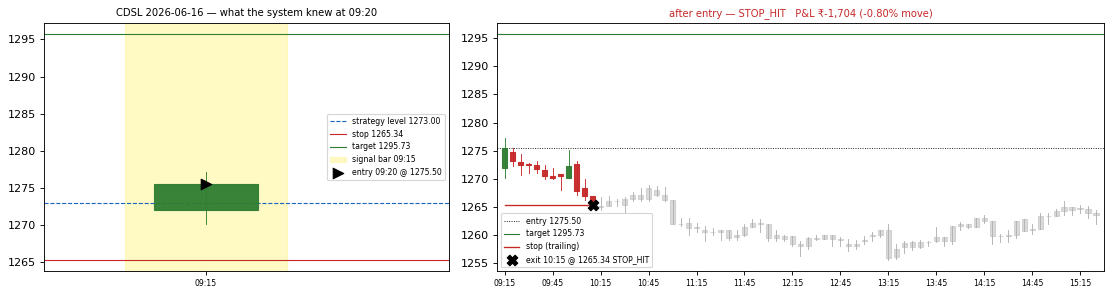


2026-06-17  COFORGE   driver VPOC — VPOC: breakout above VAH=1467.11
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 1473.30  (strategy level 1467.11, entry +0.42% vs level)
  stop 1458.57 (-1.00%)   target 1517.49 (+3.00%)   RR 1.98   rank 5
  votes: 5 agreeing, score 15.0, predicted win 49.3% — ADX-FILTER, DAILY-BIAS, GAP-CONT, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: IOC (SKIP price already past stop/target); DIXON (FAIL Predicted win pct 50.3% in 50-55% danger zone); TEJASNET (FAIL Predicted win pct 50.2% in 50-55% danger zone); KFINTECH (SKIP RR 0.44 < 1.5 at entry price)
  EXIT 09:45 @ 1490.31 (PROFIT_LOCK_STOP)   move +1.16%   P&L ₹+2,176 net (+1.09%) on 135 shares


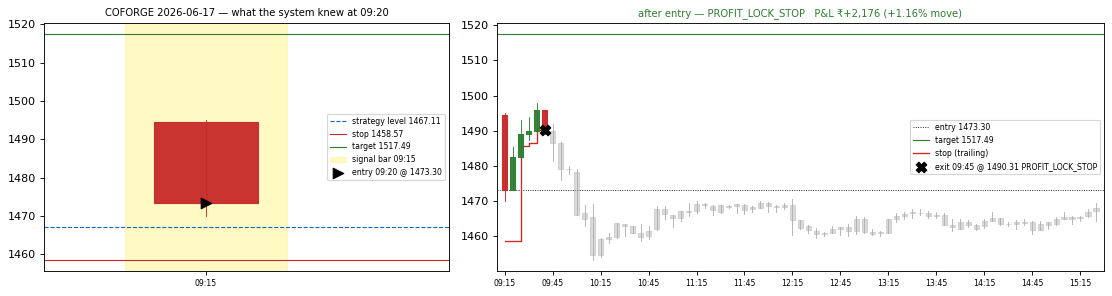


2026-06-18  SYRMA   driver VPOC — VPOC: breakout above VAH=1315.02
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 1317.00  (strategy level 1315.02, entry +0.15% vs level)
  stop 1303.83 (-1.00%)   target 1344.49 (+2.09%)   RR 1.54   rank 22
  votes: 4 agreeing, score 12.0, predicted win 48.0% — ADX-FILTER, DAILY-BIAS, GAP-CONT, VPOC
  higher-ranked stocks skipped at this scan: ADANIPORTS (FAIL Predicted win pct 50.2% in 50-55% danger zone); CPPLUS (FAIL Predicted win pct 50.2% in 50-55% danger zone); ADANIENT (SKIP geometry (stop 0.01%, target 0.02%)); ADANIENSOL (FAIL Predicted win pct 50.7% in 50-55% danger zone)
  EXIT 09:40 @ 1322.80 (PROFIT_LOCK_STOP)   move +0.44%   P&L ₹+756 net (+0.38%) on 151 shares


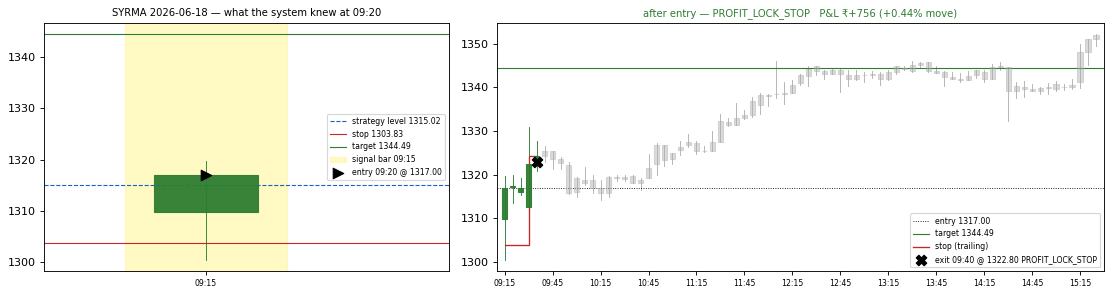


2026-06-19  ENGINERSIN   driver VPOC — VPOC: breakout above VAH=254.97
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 258.36  (strategy level 254.97, entry +1.33% vs level)
  stop 255.78 (-1.00%)   target 264.33 (+2.31%)   RR 1.69   rank 4
  votes: 5 agreeing, score 15.0, predicted win 49.8% — ADX-FILTER, DAILY-BIAS, DBL-BTM, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: HFCL (SKIP price already past stop/target); SAREGAMA (FAIL Predicted win pct 50.2% in 50-55% danger zone); CRAFTSMAN (SKIP RR 0.41 < 1.5 at entry price)
  EXIT 09:35 @ 255.78 (STOP_HIT)   move -1.00%   P&L ₹-2,116 net (-1.06%) on 774 shares


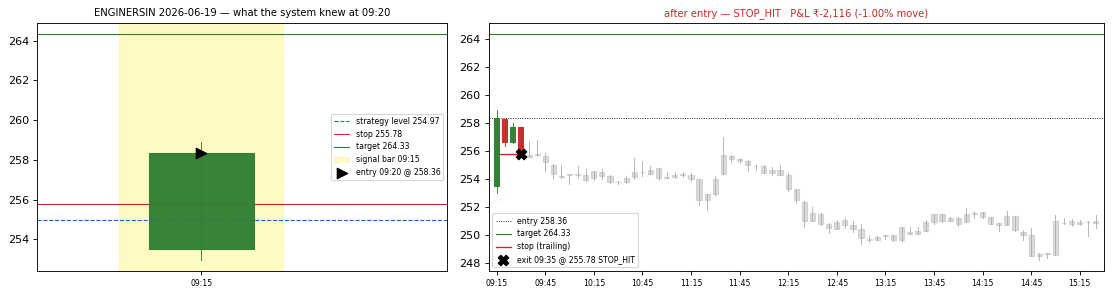


2026-06-22  TVSMOTOR   driver VPOC — VPOC: breakout above VAH=3460.80
  signal bar 09:15 | decided on bars up to 09:20 | ENTRY 09:25 @ 3464.00  (strategy level 3460.80, entry +0.09% vs level)
  stop 3441.35 (-0.65%)   target 3500.66 (+1.06%)   RR 1.62   rank 14
  votes: 5 agreeing, score 15.0, predicted win 49.8% — ADX-FILTER, DAILY-BIAS, DBL-BTM, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: ABCAPITAL (SKIP viability (stop 0.10x ATR < 0.3)); DELHIVERY (SKIP price already past stop/target); ICICIBANK (FAIL Predicted win pct 50.3% in 50-55% danger zone); BOSCHLTD (FAIL Predicted win pct 50.2% in 50-55% danger zone)
  EXIT 14:50 @ 3478.60 (TIME_EXIT)   move +0.42%   P&L ₹+713 net (+0.36%) on 57 shares


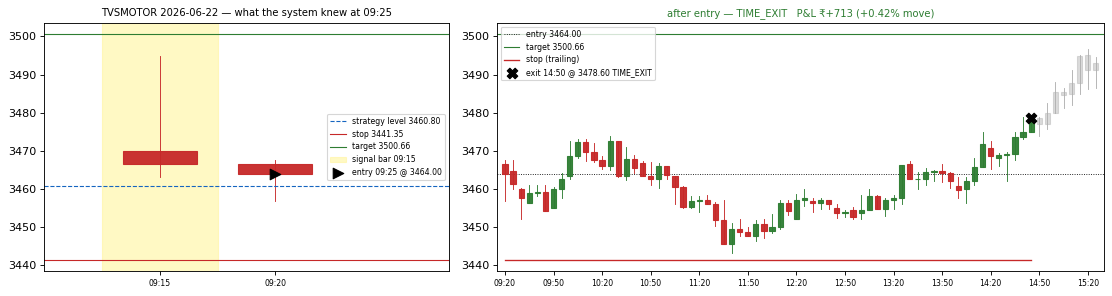


2026-06-23  WELCORP   driver CAMARILLA — CAMARILLA: breakout above H4=1420.62
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 1424.70  (strategy level 1420.62, entry +0.29% vs level)
  stop 1410.45 (-1.00%)   target 1461.88 (+2.61%)   RR 2.58   rank 27
  votes: 4 agreeing, score 12.0, predicted win 49.2% — CAMARILLA, DAILY-BIAS, GAP-CONT, VPOC
  higher-ranked stocks skipped at this scan: SYRMA (SKIP RR 0.08 < 1.5 at entry price); KIRLOSENG (SKIP geometry (stop 2.09%, target 8.37%)); ADANIENT (SKIP geometry (stop 5.94%, target 17.78%)); DIVISLAB (SKIP RR 0.85 < 1.5 at entry price)
  EXIT 09:30 @ 1431.81 (PROFIT_LOCK_STOP)   move +0.50%   P&L ₹+875 net (+0.44%) on 140 shares


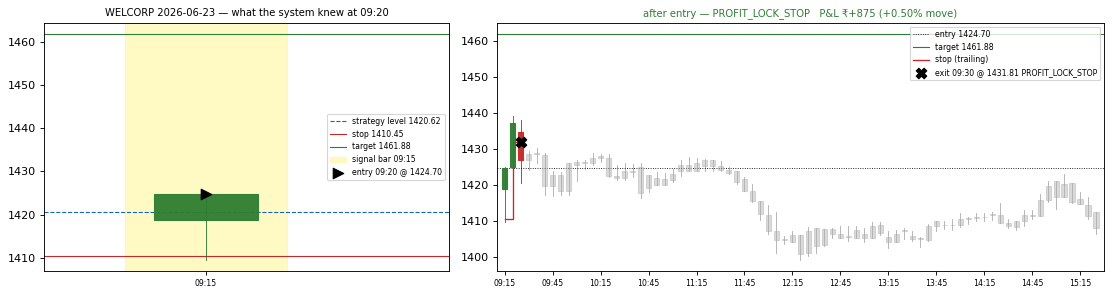


2026-06-24  ZYDUSLIFE   driver VPOC — VPOC: breakout above VAH=1121.46
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 1121.80  (strategy level 1121.46, entry +0.03% vs level)
  stop 1112.73 (-0.81%)   target 1148.79 (+2.41%)   RR 2.98   rank 6
  votes: 4 agreeing, score 12.0, predicted win 48.8% — ASC-TRI, DAILY-BIAS, DBL-BTM, VPOC
  higher-ranked stocks skipped at this scan: LUPIN (FAIL Predicted win pct 50.2% in 50-55% danger zone); PAGEIND (SKIP RR 0.83 < 1.5 at entry price); OFSS (SKIP RR 0.41 < 1.5 at entry price); APARINDS (FAIL Predicted win pct 50.9% in 50-55% danger zone)
  EXIT 09:50 @ 1112.73 (STOP_HIT)   move -0.81%   P&L ₹-1,734 net (-0.87%) on 178 shares


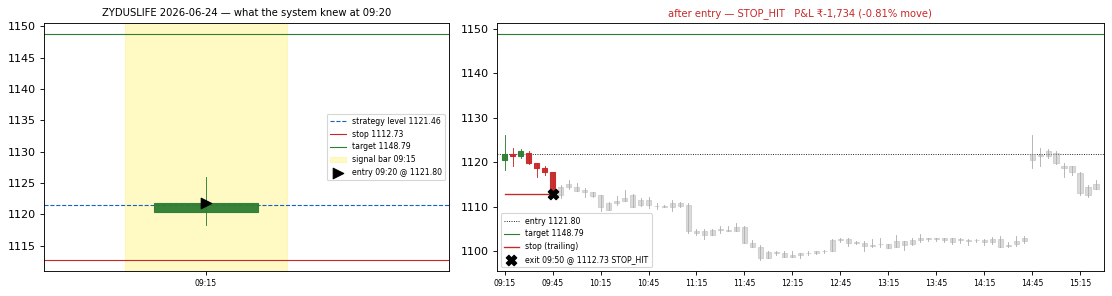


2026-06-25  ICICIBANK   driver CAMARILLA — CAMARILLA: breakout above H4=1382.47
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 1386.40  (strategy level 1382.47, entry +0.28% vs level)
  stop 1372.54 (-1.00%)   target 1422.40 (+2.60%)   RR 2.59   rank 5
  votes: 7 agreeing, score 21.0, predicted win 49.5% — ADX-FILTER, CAMARILLA, CPR, DAILY-BIAS, GAP-CONT, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: ADANIENT (SKIP RR 1.20 < 1.5 at entry price); GROWW (SKIP viability (stop 0.29x ATR < 0.3)); SYRMA (SKIP RR 0.14 < 1.5 at entry price); CPPLUS (SKIP price already past stop/target)
  EXIT 12:35 @ 1396.98 (PROFIT_LOCK_STOP)   move +0.76%   P&L ₹+1,403 net (+0.70%) on 144 shares


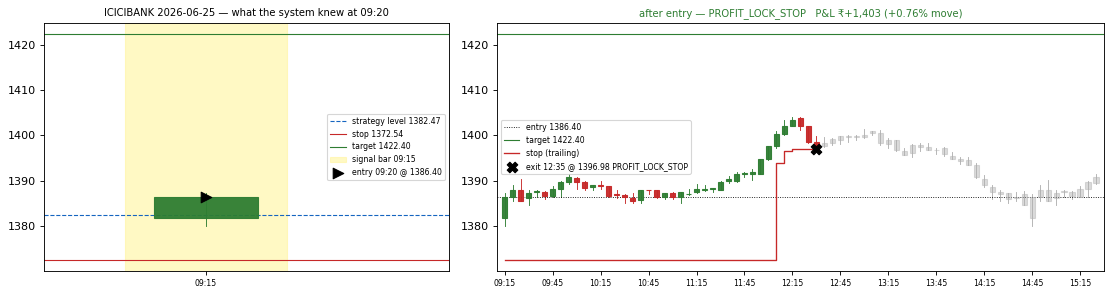


2026-06-29  SAILIFE   driver CAMARILLA — CAMARILLA: breakout above H4=1219.24
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 1226.90  (strategy level 1219.24, entry +0.63% vs level)
  stop 1214.63 (-1.00%)   target 1262.91 (+2.94%)   RR 1.94   rank 4
  votes: 6 agreeing, score 18.0, predicted win 49.9% — ADX-FILTER, CAMARILLA, DAILY-BIAS, GAP-CONT, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: WELCORP (SKIP RR 1.02 < 1.5 at entry price); CIPLA (FAIL Predicted win pct 50.3% in 50-55% danger zone); COROMANDEL (FAIL Predicted win pct 50.2% in 50-55% danger zone)
  EXIT 10:00 @ 1239.67 (PROFIT_LOCK_STOP)   move +1.04%   P&L ₹+1,961 net (+0.98%) on 163 shares


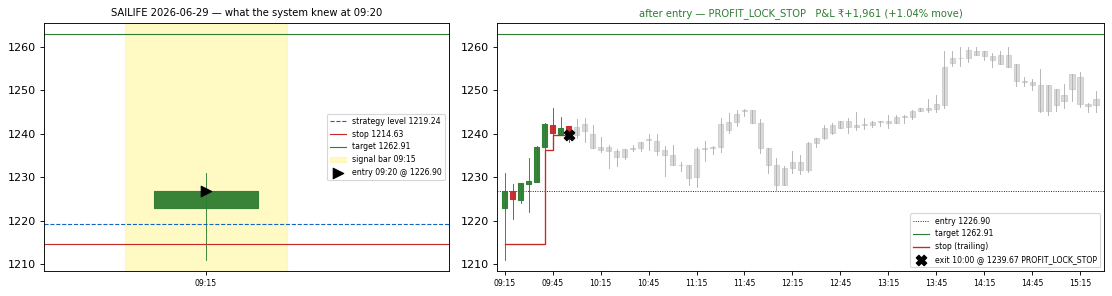


2026-06-30  GROWW   driver VPOC — VPOC: breakout above VAH=204.15
  signal bar 09:15 | decided on bars up to 09:30 | ENTRY 09:35 @ 206.10  (strategy level 204.15, entry +0.96% vs level)
  stop 204.04 (-1.00%)   target 213.12 (+3.41%)   RR 3.08   rank 10
  votes: 6 agreeing, score 18.0, predicted win 49.0% — ADX-FILTER, DAILY-BIAS, MACD, PDH-PDL, SR-BREAK, VPOC
  higher-ranked stocks skipped at this scan: CHOICEIN (SKIP geometry (stop 0.13%, target 0.26%)); HSCL (SKIP RR 0.19 < 1.5 at entry price); ZYDUSLIFE (FAIL Predicted win pct 50.6% in 50-55% danger zone); GAIL (FAIL Predicted win pct 50.1% in 50-55% danger zone)
  EXIT 13:50 @ 204.04 (STOP_HIT)   move -1.00%   P&L ₹-2,117 net (-1.06%) on 970 shares


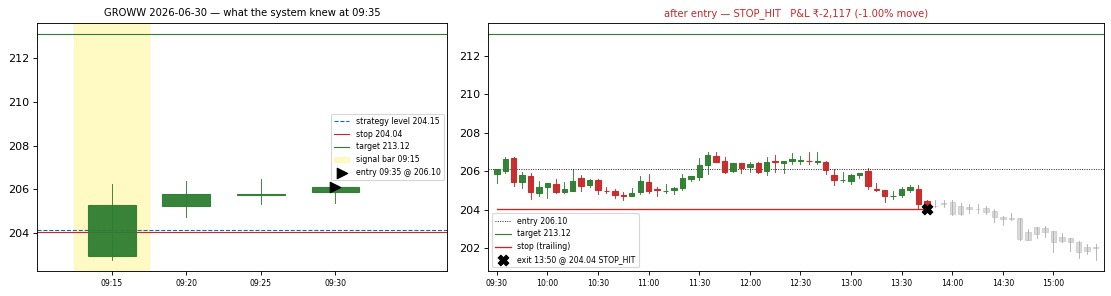

In [10]:
tc.show_month(res, "2026-06")

### July 2026

2026-07: 23 trading days, 23 trades, 9 winners, net ₹-10,429

2026-07-01  BIOCON   driver CAMARILLA — CAMARILLA: breakout above H4=423.09
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 424.85  (strategy level 423.09, entry +0.41% vs level)
  stop 420.60 (-1.00%)   target 433.98 (+2.15%)   RR 2.04   rank 1
  votes: 7 agreeing, score 21.0, predicted win 49.9% — ADX-FILTER, CAMARILLA, CPR, DAILY-BIAS, DBL-BTM, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: none
  EXIT 10:20 @ 420.60 (STOP_HIT)   move -1.00%   P&L ₹-2,117 net (-1.06%) on 470 shares


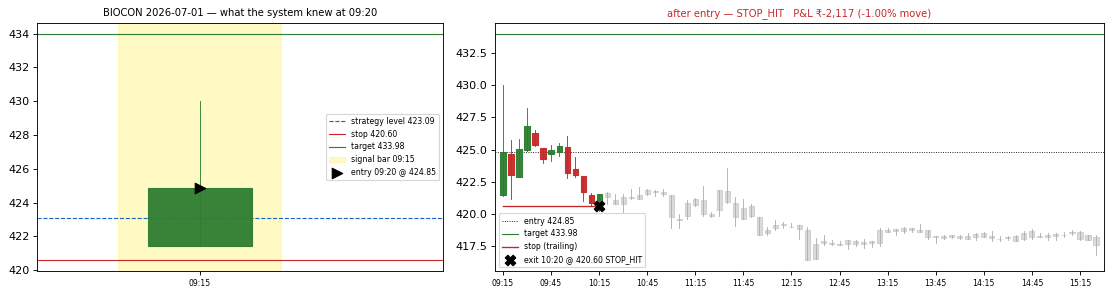


2026-07-02  SBIN   driver VPOC — VPOC: breakout above VAH=1048.91
  signal bar 09:15 | decided on bars up to 09:20 | ENTRY 09:25 @ 1050.90  (strategy level 1048.91, entry +0.19% vs level)
  stop 1044.71 (-0.59%)   target 1070.64 (+1.88%)   RR 3.19   rank 6
  votes: 7 agreeing, score 18.63, predicted win 48.6% — ADX-FILTER, ASC-TRI, DAILY-BIAS, MACD, PDH-PDL, SUPERTREND, VPOC
  higher-ranked stocks skipped at this scan: EXIDEIND (FAIL Predicted win pct 50.3% in 50-55% danger zone); NAUKRI (FAIL Predicted win pct 50.8% in 50-55% danger zone); BPCL (FAIL Predicted win pct 50.7% in 50-55% danger zone); CHOICEIN (FAIL Predicted win pct 50.8% in 50-55% danger zone)
  EXIT 14:50 @ 1053.50 (TIME_EXIT)   move +0.25%   P&L ₹+374 net (+0.19%) on 190 shares


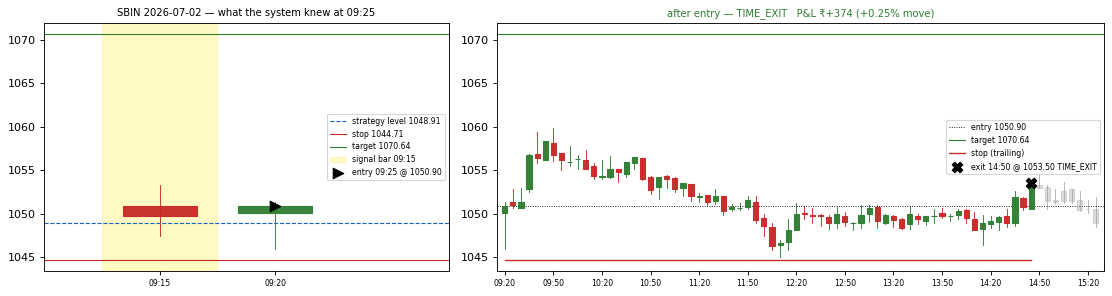


2026-07-03  CHOICEIN   driver CAMARILLA — CAMARILLA: breakout above H4=794.62
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 796.00  (strategy level 794.62, entry +0.17% vs level)
  stop 788.31 (-0.97%)   target 819.87 (+3.00%)   RR 3.10   rank 4
  votes: 7 agreeing, score 21.0, predicted win 49.5% — BULL-FLAG, CAMARILLA, CPR, DAILY-BIAS, GAP-CONT, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: MRF (SKIP price already past stop/target); LENSKART (SKIP RR 0.10 < 1.5 at entry price); LTF (SKIP price already past stop/target)
  EXIT 14:50 @ 799.10 (TIME_EXIT)   move +0.39%   P&L ₹+658 net (+0.33%) on 251 shares


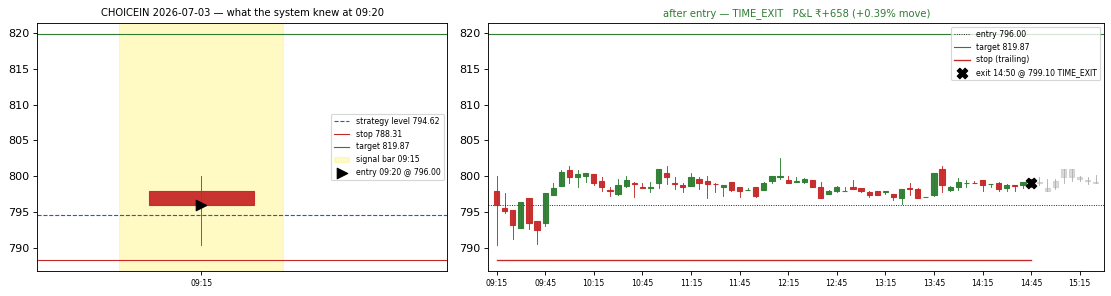


2026-07-06  CGCL   driver VPOC — VPOC: breakout above VAH=234.38
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 236.95  (strategy level 234.38, entry +1.10% vs level)
  stop 234.58 (-1.00%)   target 241.44 (+1.89%)   RR 1.69   rank 1
  votes: 7 agreeing, score 21.0, predicted win 49.6% — ADX-FILTER, BULL-FLAG, CAMARILLA, DAILY-BIAS, GAP-CONT, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: none
  EXIT 09:45 @ 234.58 (STOP_HIT)   move -1.00%   P&L ₹-2,120 net (-1.06%) on 844 shares


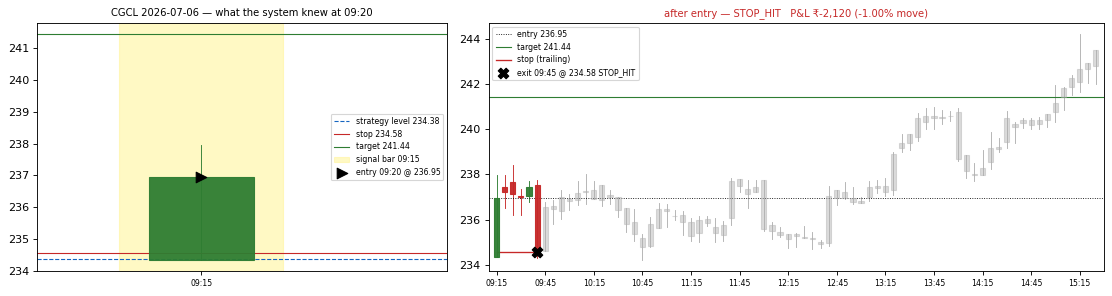


2026-07-07  BOSCHLTD   driver CAMARILLA — CAMARILLA: breakout above H4=42334.75
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 42485.00  (strategy level 42334.75, entry +0.35% vs level)
  stop 42129.88 (-0.84%)   target 43154.25 (+1.58%)   RR 1.88   rank 3
  votes: 7 agreeing, score 21.0, predicted win 49.9% — ADX-FILTER, CAMARILLA, CPR, DAILY-BIAS, DBL-BTM, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: FORTIS (SKIP RR 0.98 < 1.5 at entry price); ALKEM (SKIP price already past stop/target)
  EXIT 09:25 @ 42129.88 (STOP_HIT)   move -0.84%   P&L ₹-1,529 net (-0.90%) on 4 shares


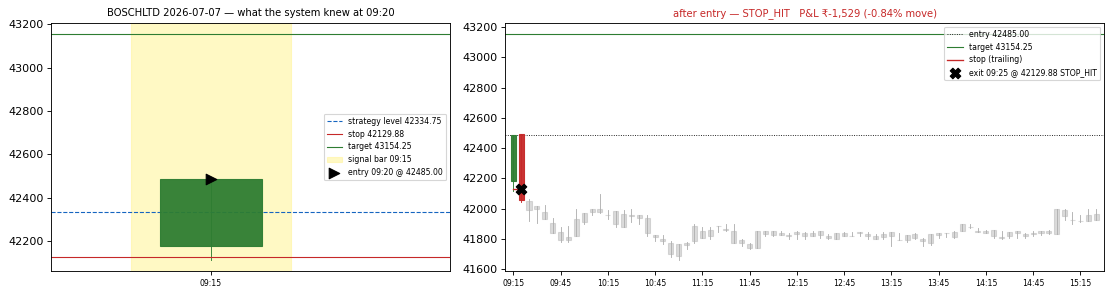


2026-07-08  ACUTAAS   driver CAMARILLA — CAMARILLA: breakout above H4=3507.60
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 3511.30  (strategy level 3507.60, entry +0.10% vs level)
  stop 3476.19 (-1.00%)   target 3718.80 (+5.91%)   RR 3.67   rank 9
  votes: 4 agreeing, score 12.0, predicted win 50.0% — ADX-FILTER, CAMARILLA, DAILY-BIAS, VPOC
  higher-ranked stocks skipped at this scan: CARTRADE (FAIL Predicted win pct 50.2% in 50-55% danger zone); EXIDEIND (SKIP viability (stop 0.26x ATR < 0.3)); TORNTPHARM (SKIP geometry (stop 0.24%, target 0.48%)); AUROPHARMA (FAIL Predicted win pct 50.9% in 50-55% danger zone)
  EXIT 09:25 @ 3476.19 (STOP_HIT)   move -1.00%   P&L ₹-2,084 net (-1.06%) on 56 shares


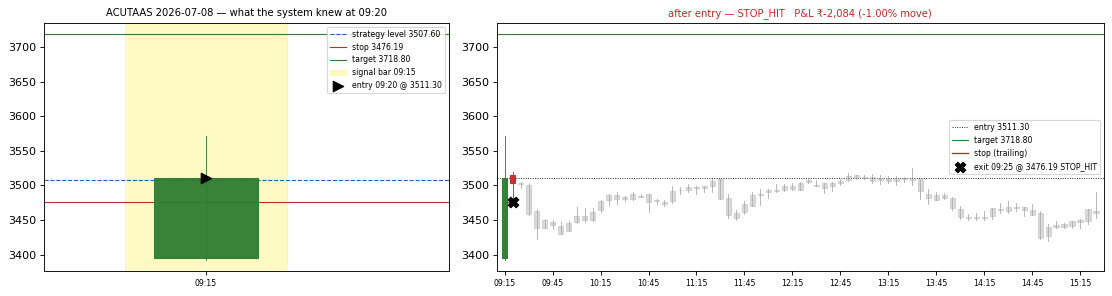


2026-07-09  KALYANKJIL   driver CAMARILLA — CAMARILLA: breakout above H4=390.07
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 397.15  (strategy level 390.07, entry +1.81% vs level)
  stop 393.18 (-1.00%)   target 420.21 (+5.81%)   RR 1.58   rank 1
  votes: 7 agreeing, score 21.0, predicted win 49.6% — ADX-FILTER, ASC-TRI, CAMARILLA, DAILY-BIAS, GAP-CONT, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: none
  EXIT 09:35 @ 407.10 (PROFIT_LOCK_STOP)   move +2.50%   P&L ₹+4,884 net (+2.44%) on 503 shares


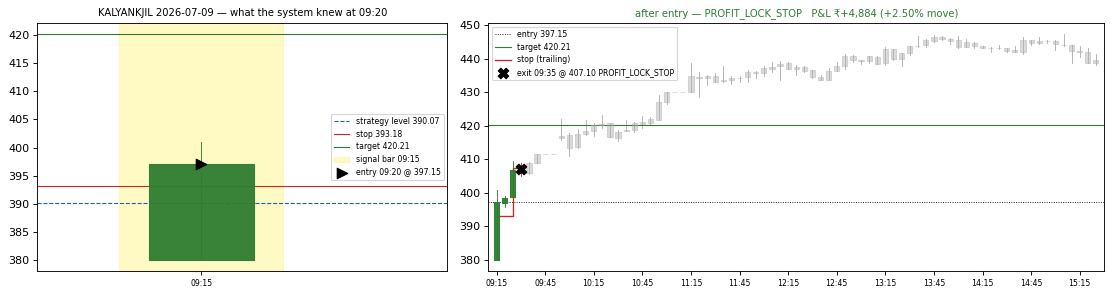


2026-07-10  OFSS   driver CAMARILLA — CAMARILLA: breakout above H4=11423.75
  signal bar 09:20 | decided on bars up to 09:20 | ENTRY 09:25 @ 11435.00  (strategy level 11423.75, entry +0.10% vs level)
  stop 11320.65 (-1.00%)   target 11935.25 (+4.37%)   RR 3.60   rank 1
  votes: 8 agreeing, score 24.0, predicted win 48.8% — ADX-FILTER, BULL-FLAG, CAMARILLA, DAILY-BIAS, GAP-CONT, MACD, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: none
  EXIT 09:35 @ 11320.65 (STOP_HIT)   move -1.00%   P&L ₹-2,061 net (-1.06%) on 17 shares


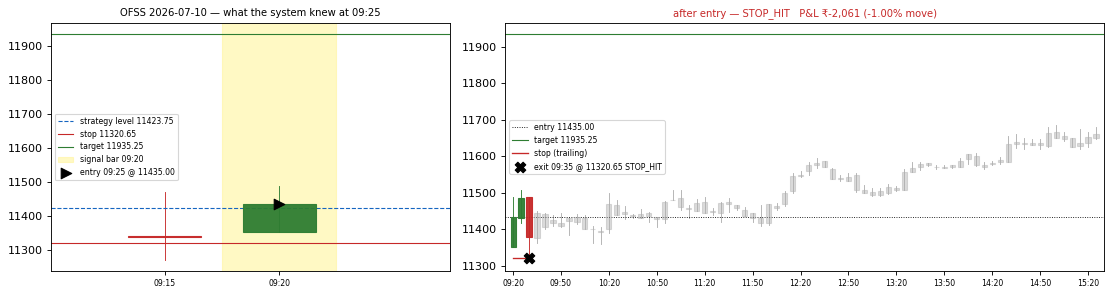


2026-07-13  MOTILALOFS   driver CAMARILLA — CAMARILLA: reversal at L3=969.35, target H3=987.45
  signal bar 09:15 | decided on bars up to 09:30 | ENTRY 09:35 @ 969.80  (strategy level 969.35, entry +0.05% vs level)
  stop 960.30 (-0.98%)   target 987.45 (+1.82%)   RR 1.86   rank 35
  votes: 4 agreeing, score 12.0, predicted win 49.9% — ASC-TRI, CAMARILLA, DAILY-BIAS, SR-BREAK
  higher-ranked stocks skipped at this scan: MFSL (FAIL Predicted win pct 50.6% in 50-55% danger zone); NYKAA (SKIP viability (stop 0.22x ATR < 0.3)); CHENNPETRO (FAIL Predicted win pct 50.7% in 50-55% danger zone); BAJAJHLDNG (SKIP RR 1.02 < 1.5 at entry price)
  EXIT 14:50 @ 979.70 (TIME_EXIT)   move +1.02%   P&L ₹+1,919 net (+0.96%) on 206 shares


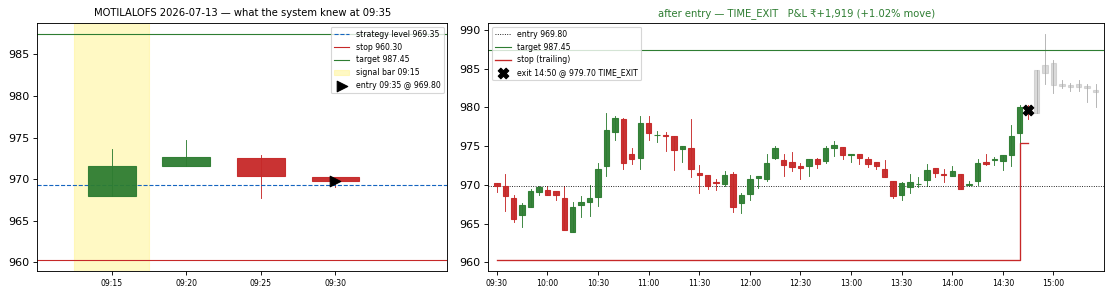


2026-07-14  HYUNDAI   driver CAMARILLA — CAMARILLA: reversal at L3=1980.34, target H3=2011.47
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 1980.90  (strategy level 1980.34, entry +0.03% vs level)
  stop 1964.77 (-0.81%)   target 2011.47 (+1.54%)   RR 1.90   rank 6
  votes: 4 agreeing, score 12.0, predicted win 49.8% — CAMARILLA, CPR, DAILY-BIAS, VPOC
  higher-ranked stocks skipped at this scan: OIL (SKIP RR 0.25 < 1.5 at entry price); IDBI (SKIP price already past stop/target); NATIONALUM (FAIL Predicted win pct 50.5% in 50-55% danger zone); BIOCON (FAIL Predicted win pct 50.1% in 50-55% danger zone)
  EXIT 12:35 @ 1964.77 (STOP_HIT)   move -0.81%   P&L ₹-1,732 net (-0.87%) on 100 shares


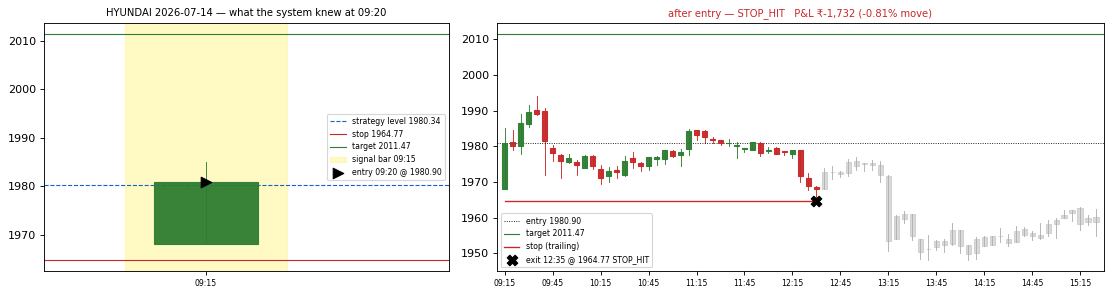


2026-07-15  BAJAJ-AUTO   driver CAMARILLA — CAMARILLA: breakout above H4=10290.83
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 10313.50  (strategy level 10290.83, entry +0.22% vs level)
  stop 10229.91 (-0.81%)   target 10534.48 (+2.14%)   RR 2.64   rank 31
  votes: 4 agreeing, score 12.0, predicted win 50.0% — ADX-FILTER, CAMARILLA, DAILY-BIAS, VPOC
  higher-ranked stocks skipped at this scan: LICI (SKIP RR 0.72 < 1.5 at entry price); ATHERENERG (SKIP RR 0.39 < 1.5 at entry price); ICICIBANK (FAIL Predicted win pct 50.3% in 50-55% danger zone); INDIGO (FAIL Predicted win pct 50.2% in 50-55% danger zone)
  EXIT 14:50 @ 10311.00 (TIME_EXIT)   move -0.02%   P&L ₹-166 net (-0.08%) on 19 shares


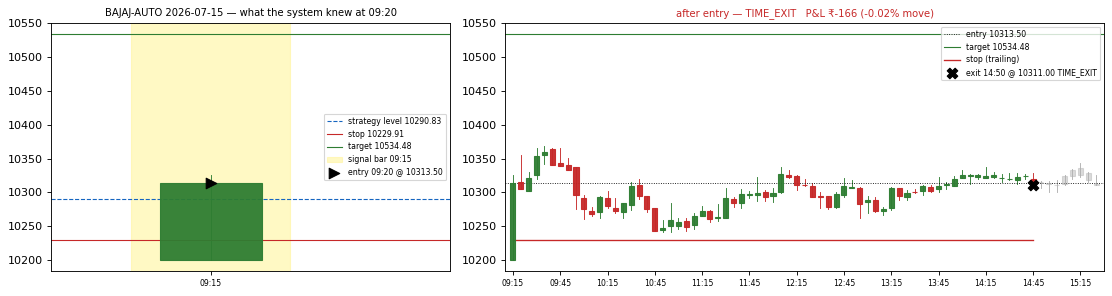


2026-07-16  PREMIERENE   driver CAMARILLA — CAMARILLA: breakout above H4=1102.30
  signal bar 09:15 | decided on bars up to 09:20 | ENTRY 09:25 @ 1106.00  (strategy level 1102.30, entry +0.34% vs level)
  stop 1096.00 (-0.90%)   target 1127.49 (+1.94%)   RR 2.15   rank 14
  votes: 5 agreeing, score 15.0, predicted win 48.0% — ADX-FILTER, CAMARILLA, DAILY-BIAS, DBL-BTM, MACD
  higher-ranked stocks skipped at this scan: EMMVEE (FAIL Predicted win pct 50.4% in 50-55% danger zone); HSCL (SKIP RR 0.08 < 1.5 at entry price); MRPL (FAIL Predicted win pct 50.4% in 50-55% danger zone); TITAN (FAIL Predicted win pct 50.7% in 50-55% danger zone)
  EXIT 13:50 @ 1096.00 (STOP_HIT)   move -0.90%   P&L ₹-1,919 net (-0.96%) on 180 shares


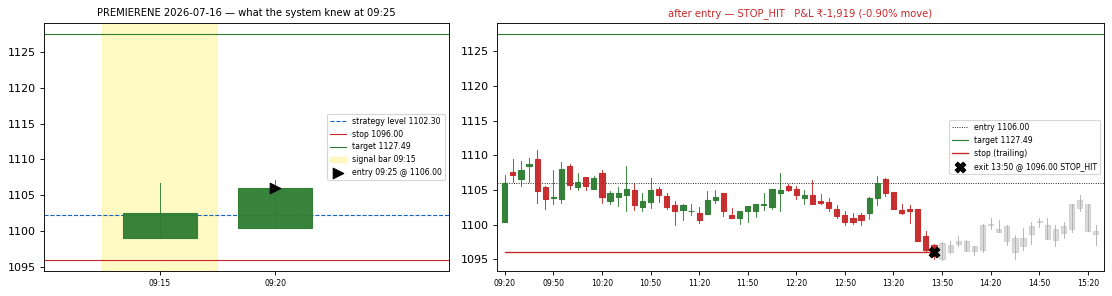


2026-07-17  BANDHANBNK   driver FIRST-CANDLE — FIRST-CANDLE: break above first candle high=214.24
  signal bar 09:20 | decided on bars up to 09:30 | ENTRY 09:35 @ 214.39  (strategy level 214.24, entry +0.07% vs level)
  stop 212.25 (-1.00%)   target 218.40 (+1.87%)   RR 1.80   rank 15
  votes: 4 agreeing, score 15.03, predicted win 46.7% — BOLLINGER, CAMARILLA, DAILY-BIAS, FIRST-CANDLE, MACD, RSI-EXT
  higher-ranked stocks skipped at this scan: ICICIBANK (FAIL Predicted win pct 50.3% in 50-55% danger zone); EXIDEIND (SKIP geometry (stop 3.39%, target 11.07%)); FEDERALBNK (FAIL Predicted win pct 51.0% in 50-55% danger zone); MARUTI (SKIP RR 0.11 < 1.5 at entry price)
  EXIT 12:05 @ 212.25 (STOP_HIT)   move -1.00%   P&L ₹-2,114 net (-1.06%) on 932 shares


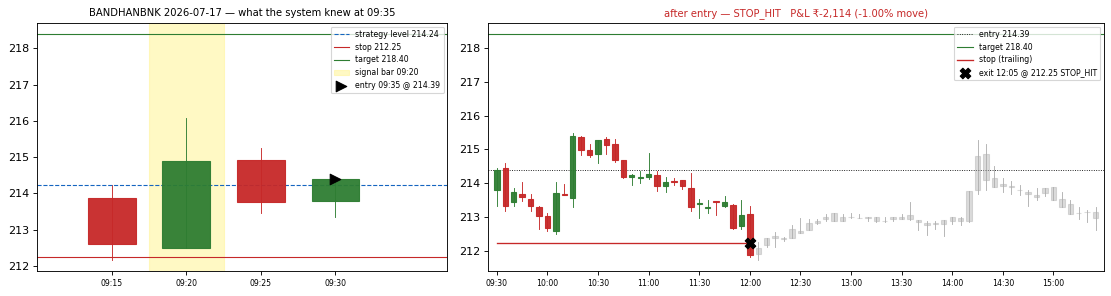


2026-07-20  JSWSTEEL   driver CAMARILLA — CAMARILLA: breakout above H4=1245.19
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 1250.00  (strategy level 1245.19, entry +0.39% vs level)
  stop 1238.10 (-0.95%)   target 1273.57 (+1.89%)   RR 1.98   rank 4
  votes: 6 agreeing, score 18.0, predicted win 49.6% — ADX-FILTER, CAMARILLA, CPR, GAP-CONT, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: RELIANCE (FAIL Predicted win pct 50.4% in 50-55% danger zone); ONGC (FAIL Predicted win pct 50.2% in 50-55% danger zone); ACUTAAS (FAIL Predicted win pct 50.2% in 50-55% danger zone)
  EXIT 09:40 @ 1257.68 (PROFIT_LOCK_STOP)   move +0.61%   P&L ₹+1,109 net (+0.55%) on 160 shares


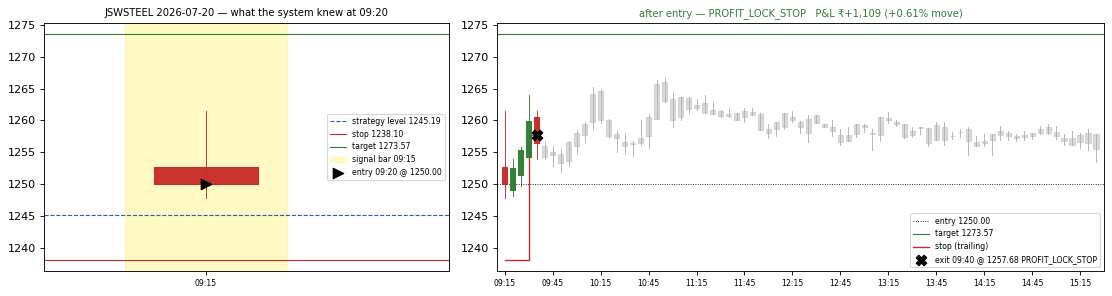


2026-07-21  IDFCFIRSTB   driver VPOC — VPOC: breakout above VAH=82.08
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 82.30  (strategy level 82.08, entry +0.27% vs level)
  stop 81.75 (-0.67%)   target 84.28 (+2.41%)   RR 3.60   rank 5
  votes: 5 agreeing, score 15.0, predicted win 49.9% — ADX-FILTER, ASC-TRI, DAILY-BIAS, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: INDUSINDBK (FAIL Predicted win pct 50.3% in 50-55% danger zone); CHENNPETRO (FAIL Predicted win pct 50.2% in 50-55% danger zone); SBILIFE (SKIP price already past stop/target); CEMPRO (FAIL Predicted win pct 50.3% in 50-55% danger zone)
  EXIT 12:10 @ 81.75 (STOP_HIT)   move -0.67%   P&L ₹-1,456 net (-0.73%) on 2430 shares


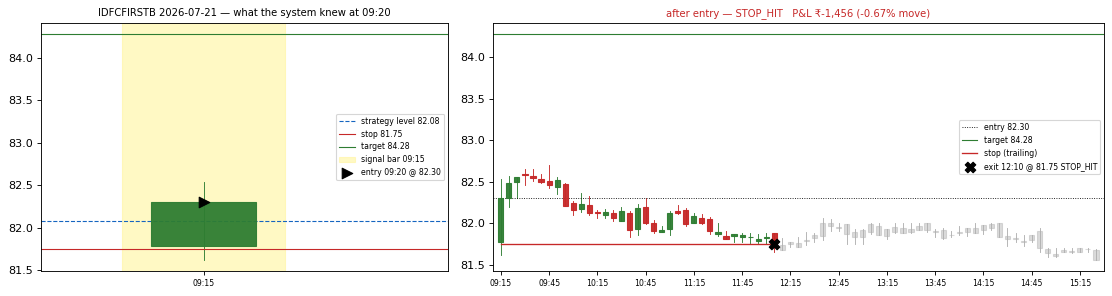


2026-07-22  LENSKART   driver FIRST-CANDLE — FIRST-CANDLE: break above first candle high=552.90
  signal bar 09:30 | decided on bars up to 09:30 | ENTRY 09:35 @ 553.90  (strategy level 552.90, entry +0.18% vs level)
  stop 548.36 (-1.00%)   target 565.90 (+2.17%)   RR 1.60   rank 2
  votes: 7 agreeing, score 18.63, predicted win 49.2% — CPR, DAILY-BIAS, FIRST-CANDLE, MACD, PDH-PDL, SR-BREAK, SUPERTREND
  higher-ranked stocks skipped at this scan: HEROMOTOCO (FAIL Predicted win pct 50.7% in 50-55% danger zone)
  EXIT 13:45 @ 558.69 (PROFIT_LOCK_STOP)   move +0.86%   P&L ₹+1,609 net (+0.80%) on 361 shares


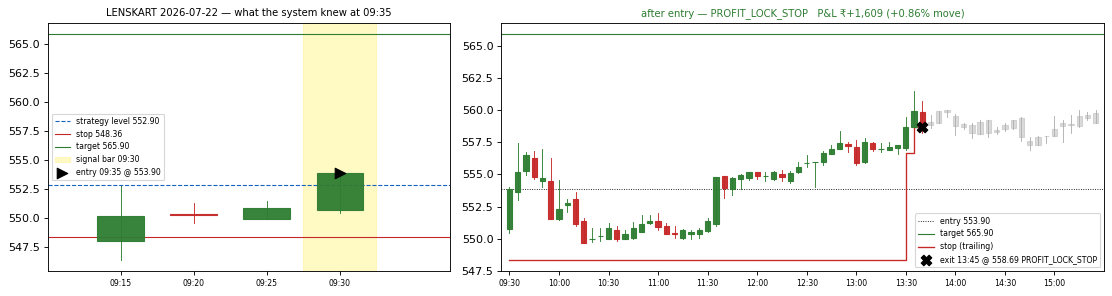


2026-07-23  ICICIBANK   driver FIRST-CANDLE — FIRST-CANDLE: break above first candle high=1439.60
  signal bar 09:20 | decided on bars up to 09:25 | ENTRY 09:30 @ 1440.70  (strategy level 1439.60, entry +0.08% vs level)
  stop 1432.50 (-0.57%)   target 1453.80 (+0.91%)   RR 1.60   rank 29
  votes: 4 agreeing, score 12.0, predicted win 50.0% — DAILY-BIAS, DBL-BTM, FIRST-CANDLE, VPOC
  higher-ranked stocks skipped at this scan: OIL (FAIL Predicted win pct 50.3% in 50-55% danger zone); NUVAMA (FAIL Predicted win pct 50.9% in 50-55% danger zone); HEG (FAIL Predicted win pct 50.4% in 50-55% danger zone); ONGC (FAIL Predicted win pct 50.3% in 50-55% danger zone)
  EXIT 12:40 @ 1432.50 (STOP_HIT)   move -0.57%   P&L ₹-1,251 net (-0.63%) on 138 shares


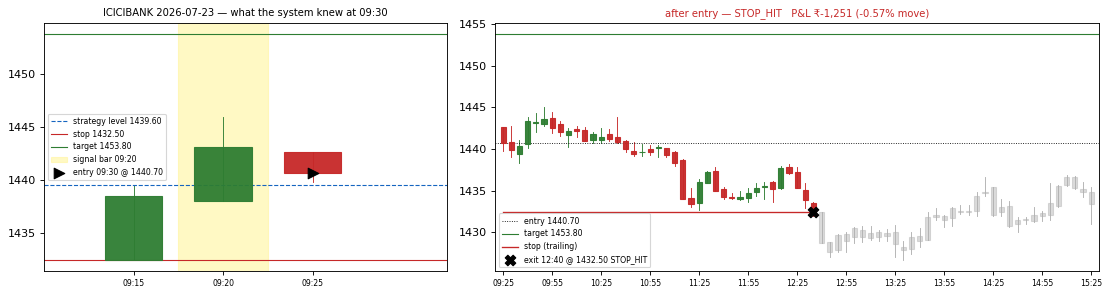


2026-07-24  NAUKRI   driver FIRST-CANDLE — FIRST-CANDLE: break above first candle high=1168.00
  signal bar 09:30 | decided on bars up to 09:40 | ENTRY 09:45 @ 1165.95  (strategy level 1168.00, entry -0.18% vs level)
  stop 1154.29 (-1.00%)   target 1204.00 (+3.26%)   RR 2.39   rank 15
  votes: 5 agreeing, score 17.53, predicted win 49.0% — BOLLINGER, CAMARILLA, DAILY-BIAS, FIRST-CANDLE, ORB-15, REL-STR
  higher-ranked stocks skipped at this scan: NUVAMA (FAIL Predicted win pct 50.4% in 50-55% danger zone); UNITDSPR (FAIL Predicted win pct 50.6% in 50-55% danger zone); EXIDEIND (SKIP RR 0.32 < 1.5 at entry price); HCLTECH (SKIP RR 1.22 < 1.5 at entry price)
  EXIT 10:10 @ 1154.29 (STOP_HIT)   move -1.00%   P&L ₹-2,113 net (-1.06%) on 171 shares


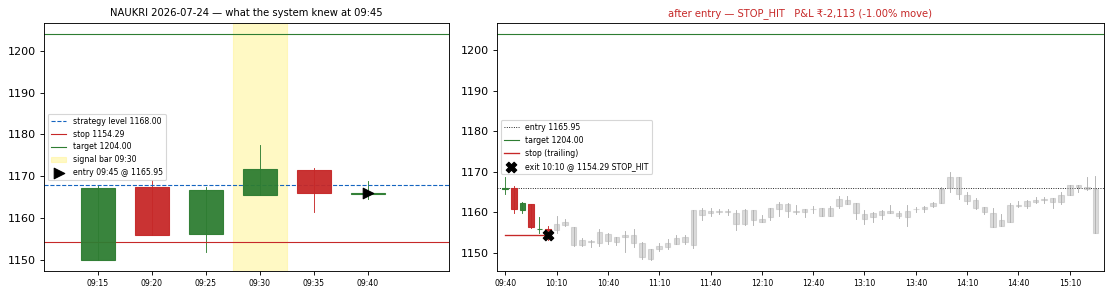


2026-07-27  TATACONSUM   driver CAMARILLA — CAMARILLA: breakout above H4=1112.62
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 1115.80  (strategy level 1112.62, entry +0.28% vs level)
  stop 1104.64 (-1.00%)   target 1153.88 (+3.41%)   RR 2.82   rank 40
  votes: 4 agreeing, score 12.0, predicted win 49.0% — ADX-FILTER, CAMARILLA, GAP-CONT, VPOC
  higher-ranked stocks skipped at this scan: BPCL (SKIP price already past stop/target); IDFCFIRSTB (SKIP price already past stop/target); SBICARD (SKIP RR 0.33 < 1.5 at entry price); ALKEM (SKIP RR 0.44 < 1.5 at entry price)
  EXIT 09:30 @ 1104.64 (STOP_HIT)   move -1.00%   P&L ₹-2,117 net (-1.06%) on 179 shares


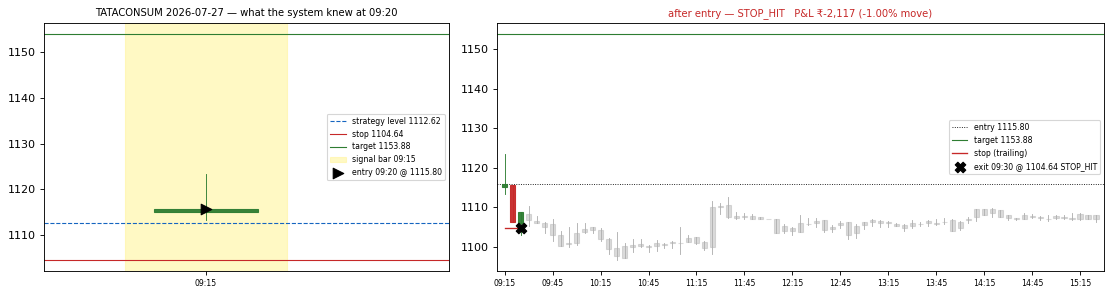


2026-07-28  RRKABEL   driver CAMARILLA — CAMARILLA: breakout above H4=2640.46
  signal bar 09:15 | decided on bars up to 09:25 | ENTRY 09:30 @ 2653.00  (strategy level 2640.46, entry +0.47% vs level)
  stop 2626.47 (-1.00%)   target 2781.37 (+4.84%)   RR 2.69   rank 18
  votes: 6 agreeing, score 18.0, predicted win 49.9% — ADX-FILTER, CAMARILLA, DAILY-BIAS, GAP-CONT, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: MARICO (SKIP RR 0.64 < 1.5 at entry price); COFORGE (FAIL Predicted win pct 50.1% in 50-55% danger zone); PERSISTENT (FAIL Predicted win pct 50.1% in 50-55% danger zone); SAGILITY (SKIP viability (stop 0.05x ATR < 0.3))
  EXIT 09:45 @ 2673.57 (PROFIT_LOCK_STOP)   move +0.78%   P&L ₹+1,423 net (+0.72%) on 75 shares


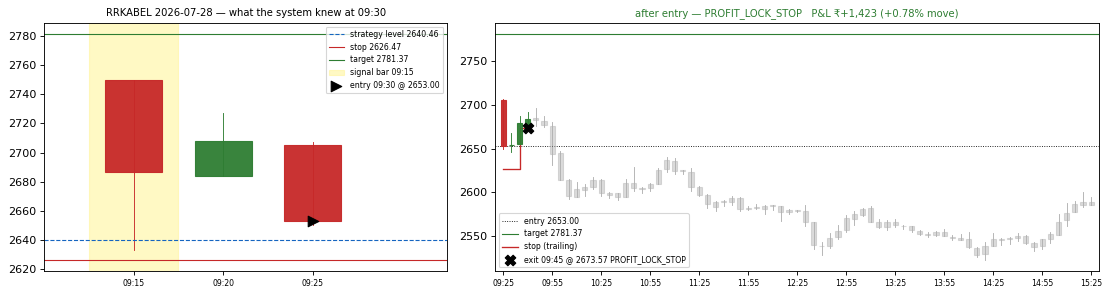


2026-07-29  DIVISLAB   driver CAMARILLA — CAMARILLA: breakout above H4=7495.85
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 7511.00  (strategy level 7495.85, entry +0.20% vs level)
  stop 7460.93 (-0.67%)   target 7635.55 (+1.66%)   RR 2.49   rank 1
  votes: 7 agreeing, score 21.0, predicted win 49.9% — ADX-FILTER, CAMARILLA, CPR, DAILY-BIAS, DBL-BTM, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: none
  EXIT 09:40 @ 7550.06 (PROFIT_LOCK_STOP)   move +0.52%   P&L ₹+897 net (+0.46%) on 26 shares


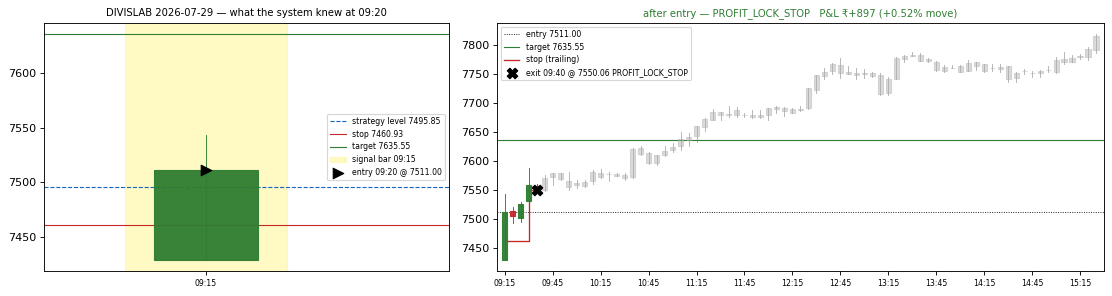


2026-07-30  AUROPHARMA   driver VPOC — VPOC: breakout above VAH=1597.71
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 1606.40  (strategy level 1597.71, entry +0.54% vs level)
  stop 1594.60 (-0.73%)   target 1624.40 (+1.12%)   RR 1.53   rank 11
  votes: 5 agreeing, score 15.0, predicted win 49.8% — ADX-FILTER, DAILY-BIAS, DBL-BTM, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: IIFL (SKIP RR 0.15 < 1.5 at entry price); SBILIFE (FAIL Predicted win pct 50.2% in 50-55% danger zone); SUNPHARMA (FAIL Predicted win pct 50.4% in 50-55% danger zone); INFY (SKIP RR 1.50 < 1.5 at entry price)
  EXIT 09:25 @ 1594.60 (STOP_HIT)   move -0.73%   P&L ₹-1,582 net (-0.79%) on 124 shares


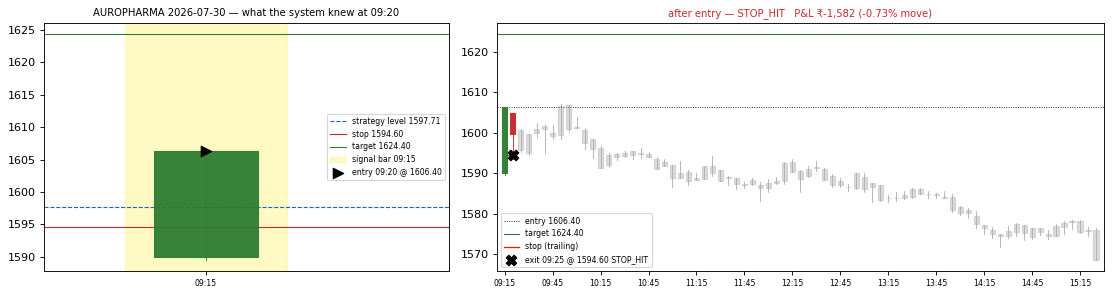


2026-07-31  IFCI   driver GAP-CONT — GAP-CONT: gap 1.4%, pullback to VWAP=74.60
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 74.64  (strategy level 74.60, entry +0.05% vs level)
  stop 73.89 (-1.00%)   target 76.10 (+1.96%)   RR 1.85   rank 42
  votes: 4 agreeing, score 12.0, predicted win 49.4% — ADX-FILTER, GAP-CONT, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: HINDALCO (SKIP RR 1.17 < 1.5 at entry price); APOLLOHOSP (SKIP RR 0.92 < 1.5 at entry price); BAJAJFINSV (SKIP RR 0.31 < 1.5 at entry price); NYKAA (SKIP geometry (stop 6.75%, target 13.39%))
  EXIT 09:35 @ 75.08 (PROFIT_LOCK_STOP)   move +0.59%   P&L ₹+1,059 net (+0.53%) on 2679 shares


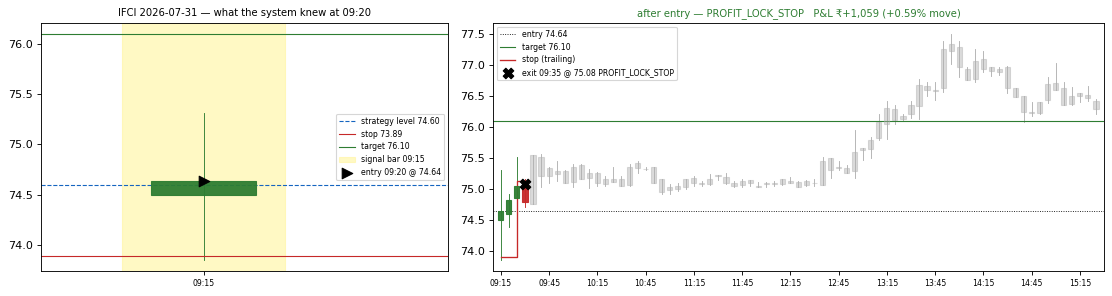

In [11]:
tc.show_month(res, "2026-07")

### August 2026

2026-08: 21 trading days, 21 trades, 12 winners, net ₹-1,134

2026-08-03  JSWSTEEL   driver CAMARILLA — CAMARILLA: breakout above H4=1281.58
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 1284.40  (strategy level 1281.58, entry +0.22% vs level)
  stop 1276.49 (-0.62%)   target 1301.92 (+1.36%)   RR 2.21   rank 2
  votes: 7 agreeing, score 21.0, predicted win 49.9% — ASC-TRI, CAMARILLA, CPR, DAILY-BIAS, DBL-BTM, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: UNOMINDA (SKIP geometry (stop 0.02%, target 0.49%))
  EXIT 09:55 @ 1276.00 (STOP_HIT)   move -0.65%   P&L ₹-1,421 net (-0.71%) on 155 shares


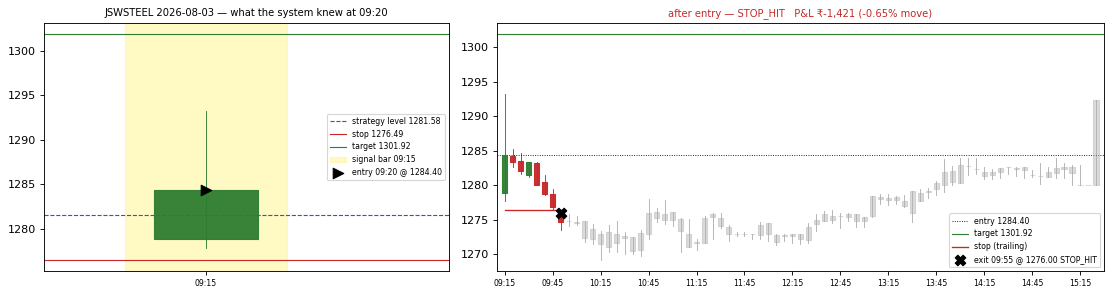


2026-08-04  ITC   driver FIRST-CANDLE — FIRST-CANDLE: break above first candle high=286.50
  signal bar 09:20 | decided on bars up to 09:20 | ENTRY 09:25 @ 286.70  (strategy level 286.50, entry +0.07% vs level)
  stop 284.70 (-0.70%)   target 290.10 (+1.19%)   RR 1.70   rank 9
  votes: 5 agreeing, score 17.53, predicted win 46.7% — BOLLINGER, DAILY-BIAS, DBL-BTM, FIRST-CANDLE, MACD, VPOC
  higher-ranked stocks skipped at this scan: WELCORP (FAIL Predicted win pct 50.3% in 50-55% danger zone); HINDZINC (SKIP viability (stop 0.28x ATR < 0.3)); CANBK (FAIL Predicted win pct 50.7% in 50-55% danger zone); KEI (FAIL Predicted win pct 50.1% in 50-55% danger zone)
  EXIT 14:50 @ 286.90 (TIME_EXIT)   move +0.07%   P&L ₹+20 net (+0.01%) on 697 shares


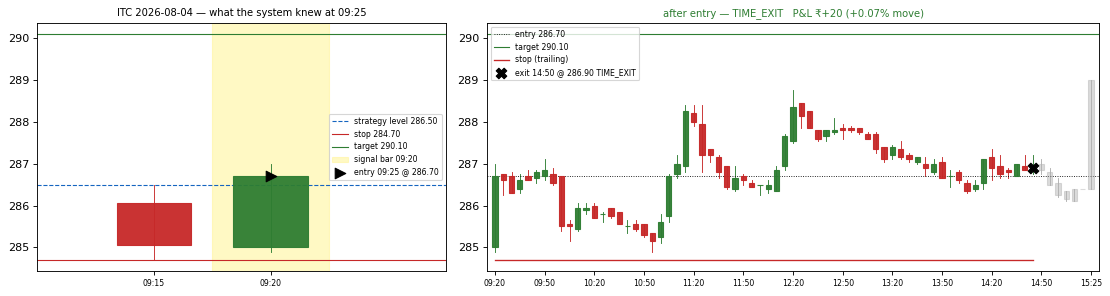


2026-08-05  AEGISLOG   driver CAMARILLA — CAMARILLA: breakout above H4=1376.07
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 1386.10  (strategy level 1376.07, entry +0.73% vs level)
  stop 1372.24 (-1.00%)   target 1420.40 (+2.47%)   RR 1.62   rank 46
  votes: 4 agreeing, score 12.0, predicted win 49.2% — CAMARILLA, DAILY-BIAS, GAP-CONT, VPOC
  higher-ranked stocks skipped at this scan: NHPC (SKIP RR 1.14 < 1.5 at entry price); WELCORP (FAIL Predicted win pct 50.3% in 50-55% danger zone); ANANTRAJ (FAIL Predicted win pct 50.2% in 50-55% danger zone); ASHOKLEY (SKIP RR 0.64 < 1.5 at entry price)
  EXIT 09:35 @ 1400.70 (PROFIT_LOCK_STOP)   move +1.05%   P&L ₹+1,982 net (+0.99%) on 144 shares


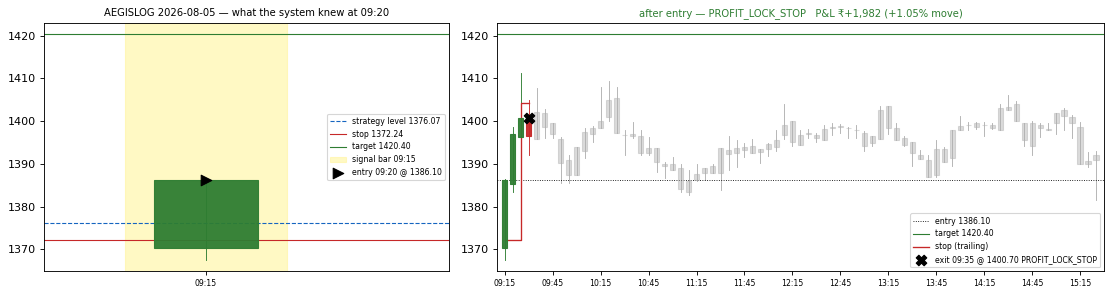


2026-08-06  TATASTEEL   driver CAMARILLA — CAMARILLA: reversal at L3=192.14, target H3=193.84
  signal bar 09:20 | decided on bars up to 09:25 | ENTRY 09:30 @ 192.30  (strategy level 192.14, entry +0.08% vs level)
  stop 191.29 (-0.53%)   target 193.84 (+0.80%)   RR 1.52   rank 13
  votes: 5 agreeing, score 15.0, predicted win 49.5% — ADX-FILTER, CAMARILLA, DAILY-BIAS, DBL-BTM, VPOC
  higher-ranked stocks skipped at this scan: POLICYBZR (SKIP viability (stop 0.26x ATR < 0.3)); HAL (SKIP price already past stop/target); CIPLA (FAIL Predicted win pct 50.5% in 50-55% danger zone); BANDHANBNK (SKIP geometry (stop 4.70%, target 21.92%))
  EXIT 10:05 @ 191.29 (STOP_HIT)   move -0.53%   P&L ₹-1,170 net (-0.59%) on 1040 shares


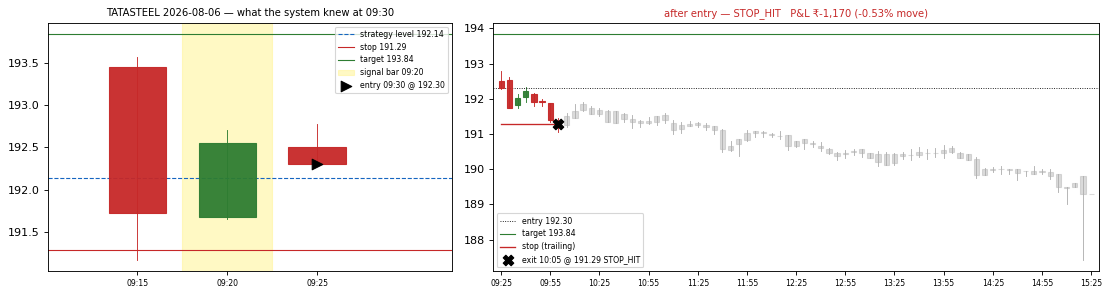


2026-08-07  HDFCAMC   driver FIRST-CANDLE — FIRST-CANDLE: break above first candle high=2541.40
  signal bar 09:20 | decided on bars up to 09:20 | ENTRY 09:25 @ 2541.90  (strategy level 2541.40, entry +0.02% vs level)
  stop 2521.20 (-0.81%)   target 2581.80 (+1.57%)   RR 1.93   rank 6
  votes: 6 agreeing, score 15.63, predicted win 49.1% — CAMARILLA, CPR, FIRST-CANDLE, MACD, SUPERTREND, VPOC
  higher-ranked stocks skipped at this scan: NESTLEIND (FAIL Predicted win pct 50.1% in 50-55% danger zone); FLUOROCHEM (FAIL Predicted win pct 50.4% in 50-55% danger zone); KALYANKJIL (SKIP RR 0.32 < 1.5 at entry price); ENRIN (SKIP price already past stop/target)
  EXIT 14:50 @ 2548.00 (TIME_EXIT)   move +0.24%   P&L ₹+356 net (+0.18%) on 78 shares


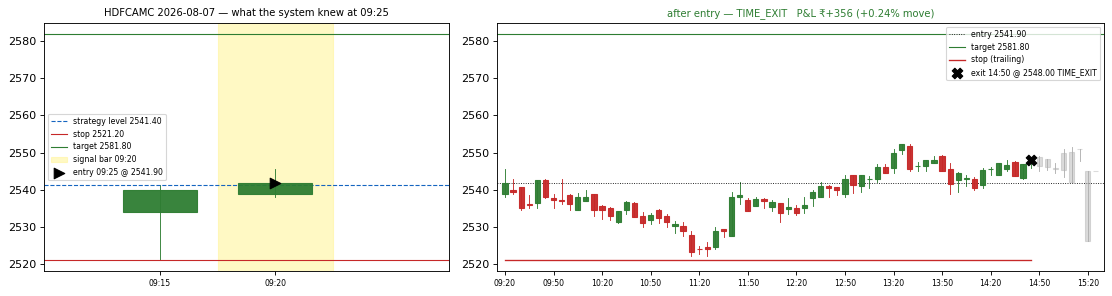


2026-08-10  WOCKPHARMA   driver VPOC — VPOC: breakout above VAH=2025.38
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 2039.00  (strategy level 2025.38, entry +0.67% vs level)
  stop 2019.70 (-0.95%)   target 2070.78 (+1.56%)   RR 1.65   rank 6
  votes: 5 agreeing, score 15.0, predicted win 49.8% — ADX-FILTER, DAILY-BIAS, DBL-BTM, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: CHOICEIN (SKIP RR 0.76 < 1.5 at entry price); GLAND (SKIP price already past stop/target); CPPLUS (SKIP RR 0.17 < 1.5 at entry price); MPHASIS (SKIP viability (stop 0.07x ATR < 0.3))
  EXIT 11:35 @ 2019.70 (STOP_HIT)   move -0.95%   P&L ₹-2,011 net (-1.01%) on 98 shares


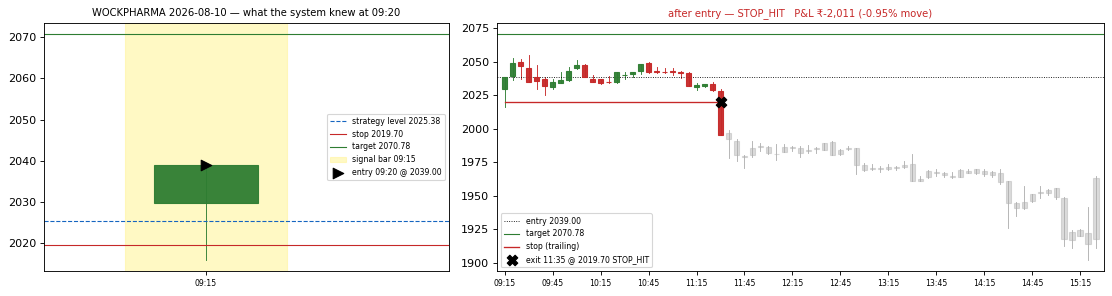


2026-08-11  ATGL   driver VPOC — VPOC: breakout above VAH=664.86
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 666.65  (strategy level 664.86, entry +0.27% vs level)
  stop 660.53 (-0.92%)   target 676.32 (+1.45%)   RR 1.58   rank 17
  votes: 4 agreeing, score 12.0, predicted win 49.2% — CPR, GAP-CONT, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: OIL (SKIP RR 0.13 < 1.5 at entry price); BOSCHLTD (SKIP RR 0.18 < 1.5 at entry price); GLAND (SKIP price already past stop/target); HCLTECH (FAIL Predicted win pct 50.2% in 50-55% danger zone)
  EXIT 10:20 @ 670.30 (PROFIT_LOCK_STOP)   move +0.55%   P&L ₹+975 net (+0.49%) on 300 shares


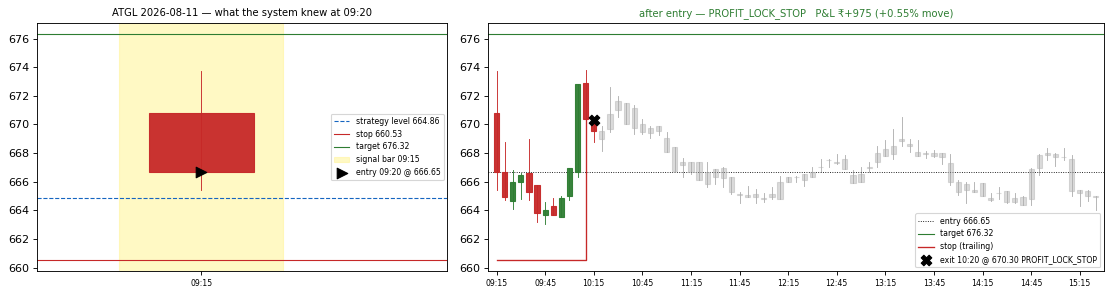


2026-08-12  AUBANK   driver FIRST-CANDLE — FIRST-CANDLE: break above first candle high=1071.80
  signal bar 09:20 | decided on bars up to 09:20 | ENTRY 09:25 @ 1071.90  (strategy level 1071.80, entry +0.01% vs level)
  stop 1062.00 (-0.92%)   target 1091.40 (+1.82%)   RR 1.97   rank 14
  votes: 5 agreeing, score 15.0, predicted win 49.2% — ADX-FILTER, CAMARILLA, DAILY-BIAS, FIRST-CANDLE, MACD
  higher-ranked stocks skipped at this scan: UNIONBANK (SKIP RR 1.04 < 1.5 at entry price); APARINDS (FAIL Predicted win pct 50.3% in 50-55% danger zone); LALPATHLAB (FAIL Predicted win pct 50.4% in 50-55% danger zone); PNB (FAIL Predicted win pct 51.3% in 50-55% danger zone)
  EXIT 13:55 @ 1077.29 (PROFIT_LOCK_STOP)   move +0.50%   P&L ₹+883 net (+0.44%) on 186 shares


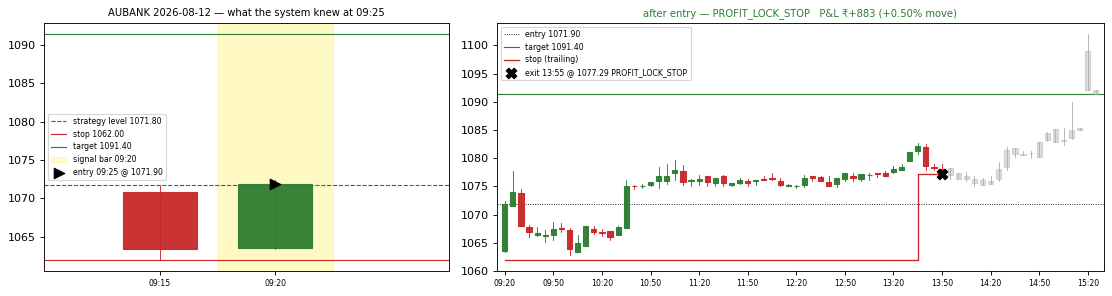


2026-08-13  COCHINSHIP   driver FIRST-CANDLE — FIRST-CANDLE: break above first candle high=1516.90
  signal bar 09:20 | decided on bars up to 09:20 | ENTRY 09:25 @ 1517.50  (strategy level 1516.90, entry +0.04% vs level)
  stop 1502.33 (-1.00%)   target 1550.70 (+2.19%)   RR 1.90   rank 9
  votes: 6 agreeing, score 18.0, predicted win 49.5% — CPR, DAILY-BIAS, FIRST-CANDLE, MACD, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: CONCOR (SKIP RR 1.07 < 1.5 at entry price); FLUOROCHEM (FAIL Predicted win pct 50.1% in 50-55% danger zone); ASTRAL (FAIL Predicted win pct 53.5% in 50-55% danger zone); HSCL (FAIL Predicted win pct 50.7% in 50-55% danger zone)
  EXIT 10:25 @ 1529.22 (PROFIT_LOCK_STOP)   move +0.77%   P&L ₹+1,415 net (+0.71%) on 131 shares


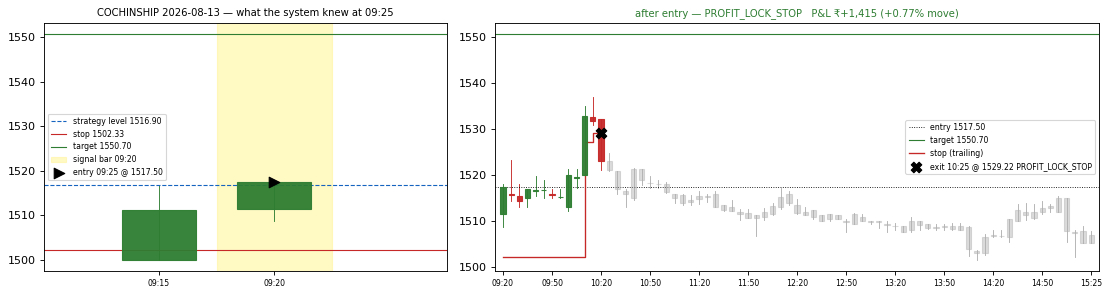


2026-08-14  PAGEIND   driver CAMARILLA — CAMARILLA: breakout above H4=37468.75
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 37665.00  (strategy level 37468.75, entry +0.52% vs level)
  stop 37288.35 (-1.00%)   target 39366.25 (+4.52%)   RR 2.54   rank 16
  votes: 4 agreeing, score 12.0, predicted win 49.0% — ADX-FILTER, CAMARILLA, GAP-CONT, VPOC
  higher-ranked stocks skipped at this scan: BHEL (SKIP price already past stop/target); POONAWALLA (SKIP RR 0.66 < 1.5 at entry price); WIPRO (SKIP geometry (stop 0.02%, target 0.03%)); HEG (FAIL Predicted win pct 50.7% in 50-55% danger zone)
  EXIT 10:50 @ 37288.35 (STOP_HIT)   move -1.00%   P&L ₹-1,998 net (-1.06%) on 5 shares


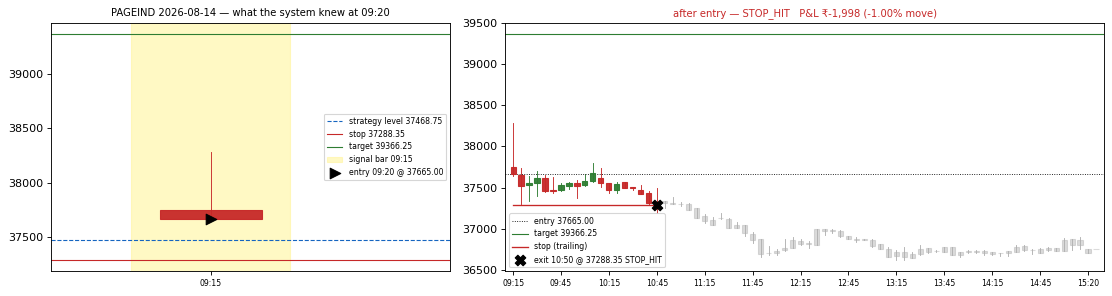


2026-08-17  GESHIP   driver FIRST-CANDLE — FIRST-CANDLE: break above first candle high=1288.60
  signal bar 09:20 | decided on bars up to 09:20 | ENTRY 09:25 @ 1289.60  (strategy level 1288.60, entry +0.08% vs level)
  stop 1276.70 (-1.00%)   target 1319.20 (+2.30%)   RR 1.82   rank 20
  votes: 4 agreeing, score 12.0, predicted win 49.8% — CAMARILLA, FIRST-CANDLE, MACD, VPOC
  higher-ranked stocks skipped at this scan: UNOMINDA (FAIL Predicted win pct 50.7% in 50-55% danger zone); ETERNAL (SKIP geometry (stop 5.08%, target 12.65%)); BEL (FAIL Predicted win pct 50.9% in 50-55% danger zone); EICHERMOT (SKIP geometry (stop 3.69%, target 9.11%))
  EXIT 10:05 @ 1276.50 (STOP_HIT)   move -1.02%   P&L ₹-2,150 net (-1.08%) on 155 shares


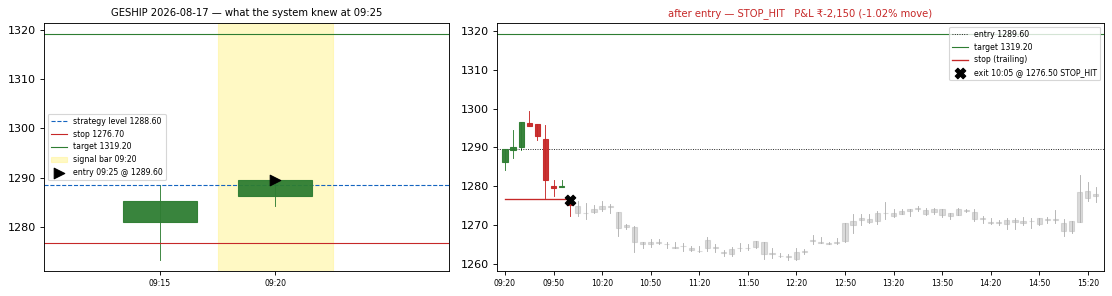


2026-08-18  SAILIFE   driver CAMARILLA — CAMARILLA: breakout above H4=1443.82
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 1450.10  (strategy level 1443.82, entry +0.43% vs level)
  stop 1435.60 (-1.00%)   target 1491.45 (+2.85%)   RR 2.27   rank 20
  votes: 4 agreeing, score 12.0, predicted win 50.0% — ADX-FILTER, CAMARILLA, DAILY-BIAS, VPOC
  higher-ranked stocks skipped at this scan: OIL (SKIP viability (stop 0.27x ATR < 0.3)); WELCORP (FAIL Predicted win pct 50.3% in 50-55% danger zone); HYUNDAI (FAIL Predicted win pct 50.9% in 50-55% danger zone); DIXON (FAIL Predicted win pct 50.9% in 50-55% danger zone)
  EXIT 09:40 @ 1462.20 (PROFIT_LOCK_STOP)   move +0.83%   P&L ₹+1,538 net (+0.77%) on 137 shares


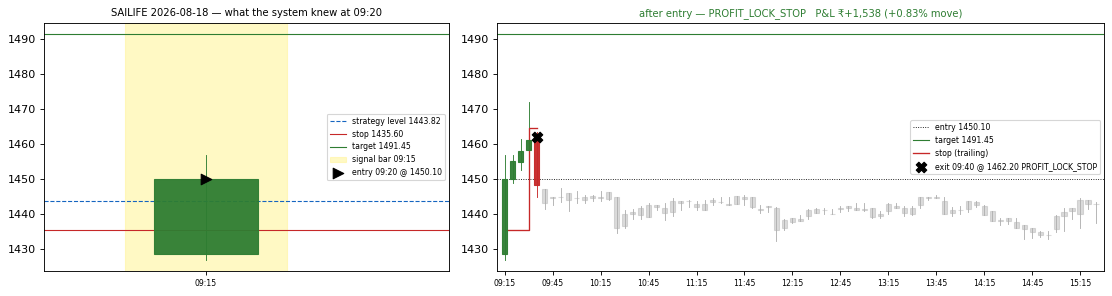


2026-08-19  ETERNAL   driver FIRST-CANDLE — FIRST-CANDLE: break above first candle high=319.20
  signal bar 09:20 | decided on bars up to 09:20 | ENTRY 09:25 @ 319.40  (strategy level 319.20, entry +0.06% vs level)
  stop 316.21 (-1.00%)   target 325.50 (+1.91%)   RR 1.82   rank 4
  votes: 5 agreeing, score 15.0, predicted win 48.5% — CPR, DAILY-BIAS, FIRST-CANDLE, MACD, VPOC
  higher-ranked stocks skipped at this scan: WELCORP (FAIL Predicted win pct 50.3% in 50-55% danger zone); RKFORGE (SKIP RR 0.34 < 1.5 at entry price); MANKIND (FAIL Predicted win pct 51.0% in 50-55% danger zone)
  EXIT 12:20 @ 321.14 (PROFIT_LOCK_STOP)   move +0.55%   P&L ₹+969 net (+0.48%) on 626 shares


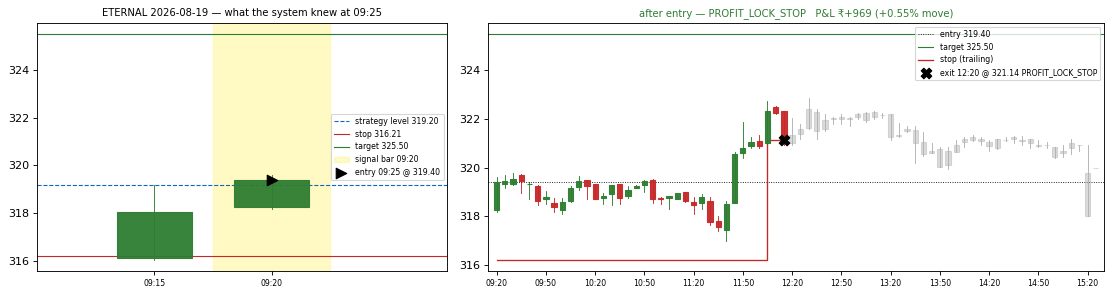


2026-08-20  ETERNAL   driver CAMARILLA — CAMARILLA: breakout above H4=323.74
  signal bar 09:15 | decided on bars up to 09:25 | ENTRY 09:30 @ 324.75  (strategy level 323.74, entry +0.31% vs level)
  stop 321.87 (-0.89%)   target 331.22 (+1.99%)   RR 2.25   rank 1
  votes: 8 agreeing, score 24.0, predicted win 49.3% — ADX-FILTER, CAMARILLA, CPR, DAILY-BIAS, DBL-BTM, GAP-CONT, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: none
  EXIT 09:55 @ 326.86 (PROFIT_LOCK_STOP)   move +0.65%   P&L ₹+1,177 net (+0.59%) on 615 shares


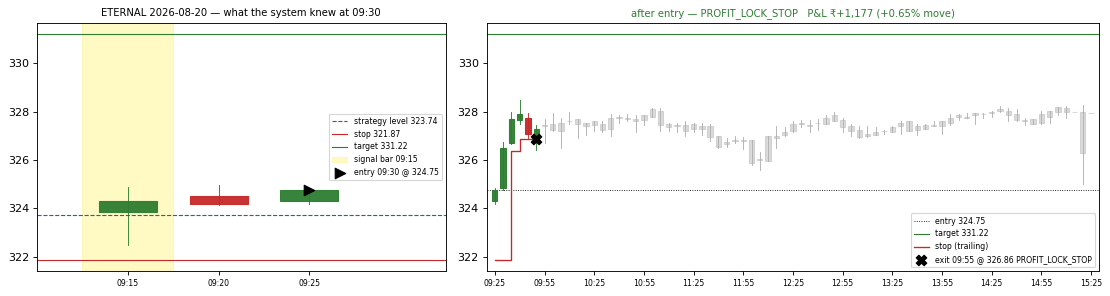


2026-08-21  MUTHOOTFIN   driver CAMARILLA — CAMARILLA: breakout above H4=3018.18
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 3020.10  (strategy level 3018.18, entry +0.06% vs level)
  stop 2994.09 (-0.86%)   target 3114.54 (+3.13%)   RR 3.63   rank 3
  votes: 6 agreeing, score 18.0, predicted win 49.7% — ADX-FILTER, CAMARILLA, DBL-BTM, GAP-CONT, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: WELCORP (SKIP price already past stop/target); HINDZINC (SKIP price already past stop/target)
  EXIT 11:35 @ 3039.72 (PROFIT_LOCK_STOP)   move +0.65%   P&L ₹+1,175 net (+0.59%) on 66 shares


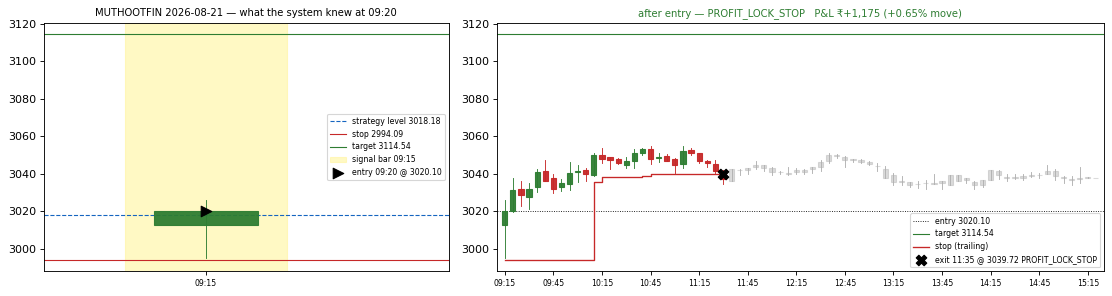


2026-08-24  SHRIRAMFIN   driver FIRST-CANDLE — FIRST-CANDLE: break above first candle high=1135.00
  signal bar 09:20 | decided on bars up to 09:20 | ENTRY 09:25 @ 1135.80  (strategy level 1135.00, entry +0.07% vs level)
  stop 1124.44 (-1.00%)   target 1164.00 (+2.48%)   RR 1.84   rank 14
  votes: 6 agreeing, score 15.63, predicted win 49.3% — CAMARILLA, DAILY-BIAS, FIRST-CANDLE, MACD, SR-BREAK, SUPERTREND
  higher-ranked stocks skipped at this scan: LTF (FAIL Predicted win pct 50.3% in 50-55% danger zone); RRKABEL (SKIP RR 1.47 < 1.5 at entry price); JINDALSTEL (SKIP geometry (stop 0.01%, target 0.34%)); RBLBANK (SKIP viability (stop 0.15x ATR < 0.3))
  EXIT 11:05 @ 1124.44 (STOP_HIT)   move -1.00%   P&L ₹-2,119 net (-1.06%) on 176 shares


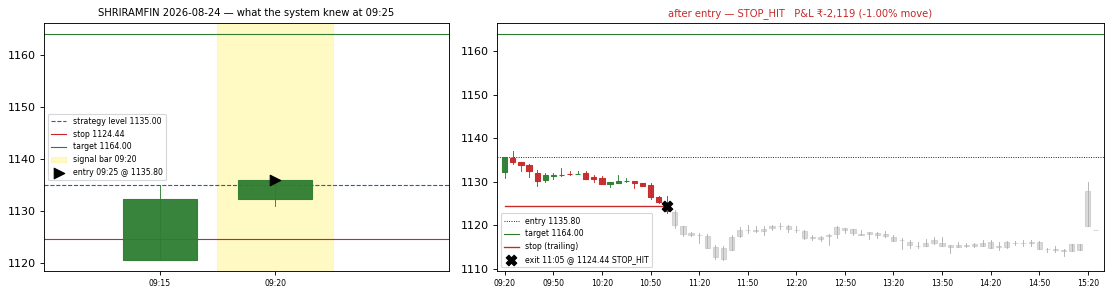


2026-08-25  SBICARD   driver FIRST-CANDLE — FIRST-CANDLE: break above first candle high=650.95
  signal bar 09:25 | decided on bars up to 09:25 | ENTRY 09:30 @ 651.70  (strategy level 650.95, entry +0.12% vs level)
  stop 646.50 (-0.80%)   target 659.85 (+1.25%)   RR 1.57   rank 24
  votes: 4 agreeing, score 12.0, predicted win 49.9% — CPR, DAILY-BIAS, FIRST-CANDLE, VPOC
  higher-ranked stocks skipped at this scan: HDFCAMC (SKIP geometry (stop 0.14%, target 0.44%)); LODHA (SKIP RR 1.43 < 1.5 at entry price); SWIGGY (SKIP geometry (stop 2.19%, target 4.37%)); MFSL (FAIL Predicted win pct 50.3% in 50-55% danger zone)
  EXIT 11:45 @ 646.50 (STOP_HIT)   move -0.80%   P&L ₹-1,710 net (-0.86%) on 306 shares


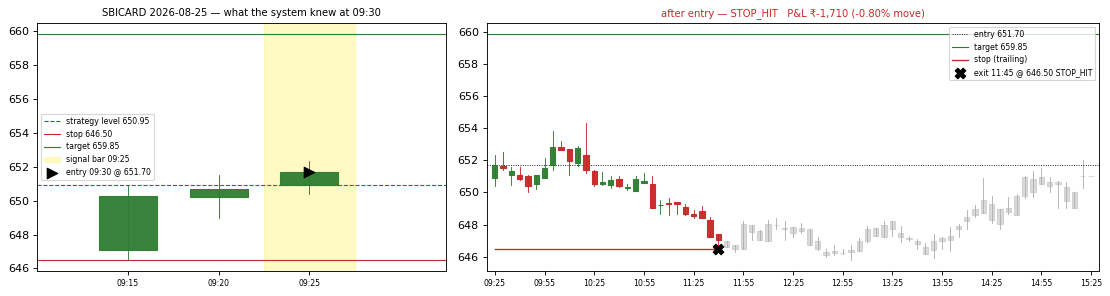


2026-08-26  INDIGO   driver VPOC — VPOC: breakout above VAH=5222.50
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 5260.50  (strategy level 5222.50, entry +0.73% vs level)
  stop 5219.96 (-0.77%)   target 5354.36 (+1.78%)   RR 2.32   rank 35
  votes: 4 agreeing, score 12.0, predicted win 47.6% — ADX-FILTER, CPR, GAP-CONT, VPOC
  higher-ranked stocks skipped at this scan: LTF (SKIP viability (stop 0.21x ATR < 0.3)); BANKINDIA (FAIL Predicted win pct 50.4% in 50-55% danger zone); COFORGE (FAIL Predicted win pct 50.3% in 50-55% danger zone); DEVYANI (FAIL Predicted win pct 50.3% in 50-55% danger zone)
  EXIT 14:50 @ 5256.00 (TIME_EXIT)   move -0.09%   P&L ₹-291 net (-0.15%) on 38 shares


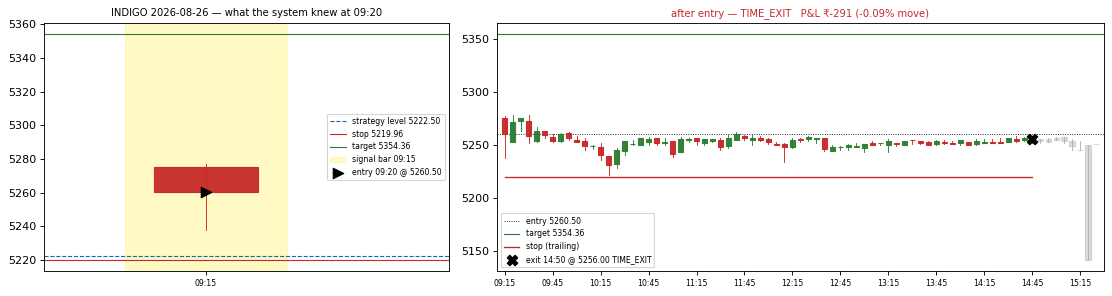


2026-08-27  ANTHEM   driver VPOC — VPOC: breakout above VAH=923.08
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 928.70  (strategy level 923.08, entry +0.61% vs level)
  stop 920.63 (-0.87%)   target 951.52 (+2.46%)   RR 2.83   rank 1
  votes: 6 agreeing, score 18.0, predicted win 49.5% — ADX-FILTER, BULL-FLAG, DAILY-BIAS, DBL-BTM, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: none
  EXIT 09:55 @ 936.50 (PROFIT_LOCK_STOP)   move +0.84%   P&L ₹+1,557 net (+0.78%) on 215 shares


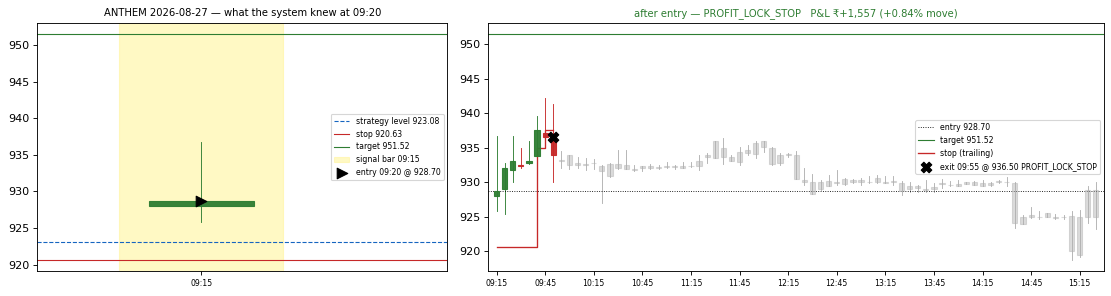


2026-08-28  CONCOR   driver CAMARILLA — CAMARILLA: breakout above H4=506.50
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 507.70  (strategy level 506.50, entry +0.24% vs level)
  stop 502.62 (-1.00%)   target 533.39 (+5.06%)   RR 3.24   rank 19
  votes: 4 agreeing, score 12.0, predicted win 49.0% — ADX-FILTER, CAMARILLA, GAP-CONT, VPOC
  higher-ranked stocks skipped at this scan: OFSS (SKIP RR 1.29 < 1.5 at entry price); ATHERENERG (SKIP RR 0.98 < 1.5 at entry price); PERSISTENT (FAIL Predicted win pct 50.2% in 50-55% danger zone); KALYANKJIL (SKIP geometry (stop 0.04%, target 0.08%))
  EXIT 10:05 @ 512.60 (PROFIT_LOCK_STOP)   move +0.96%   P&L ₹+1,805 net (+0.90%) on 393 shares


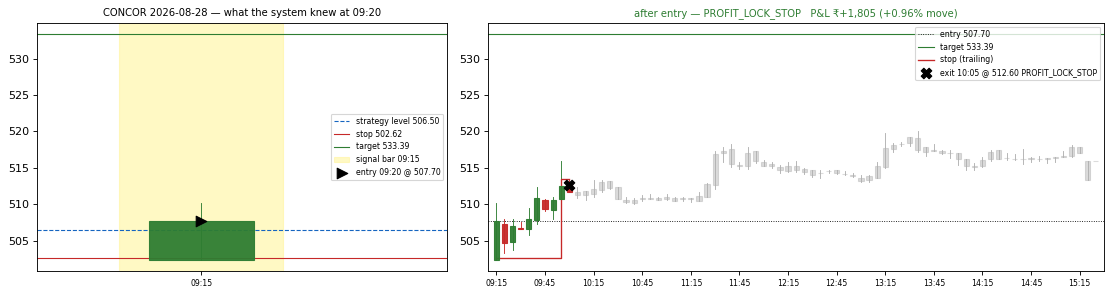


2026-08-31  OIL   driver CAMARILLA — CAMARILLA: breakout above H4=489.89
  signal bar 09:15 | decided on bars up to 09:20 | ENTRY 09:25 @ 492.15  (strategy level 489.89, entry +0.46% vs level)
  stop 487.23 (-1.00%)   target 503.97 (+2.40%)   RR 2.04   rank 2
  votes: 7 agreeing, score 21.0, predicted win 50.0% — ADX-FILTER, ASC-TRI, CAMARILLA, DAILY-BIAS, DBL-BTM, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: BEML (SKIP RR 0.46 < 1.5 at entry price)
  EXIT 10:00 @ 487.23 (STOP_HIT)   move -1.00%   P&L ₹-2,117 net (-1.06%) on 406 shares


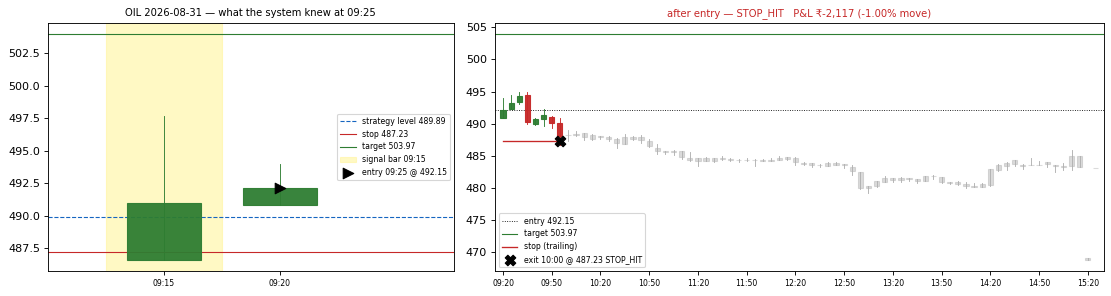

In [12]:
tc.show_month(res, "2026-08")

### September 2026

2026-09: 13 trading days, 13 trades, 6 winners, net ₹+4,114

2026-09-01  KPITTECH   driver FIRST-CANDLE — FIRST-CANDLE: break above first candle high=589.65
  signal bar 09:20 | decided on bars up to 09:20 | ENTRY 09:25 @ 590.70  (strategy level 589.65, entry +0.18% vs level)
  stop 584.79 (-1.00%)   target 606.95 (+2.75%)   RR 1.68   rank 13
  votes: 5 agreeing, score 12.63, predicted win 48.4% — ADX-FILTER, FIRST-CANDLE, MACD, SUPERTREND, VPOC
  higher-ranked stocks skipped at this scan: SAILIFE (FAIL Predicted win pct 50.2% in 50-55% danger zone); BAJAJ-AUTO (FAIL Predicted win pct 50.7% in 50-55% danger zone); HCLTECH (FAIL Predicted win pct 50.1% in 50-55% danger zone); CHENNPETRO (SKIP RR 1.36 < 1.5 at entry price)
  EXIT 14:50 @ 587.70 (TIME_EXIT)   move -0.51%   P&L ₹-1,133 net (-0.57%) on 338 shares


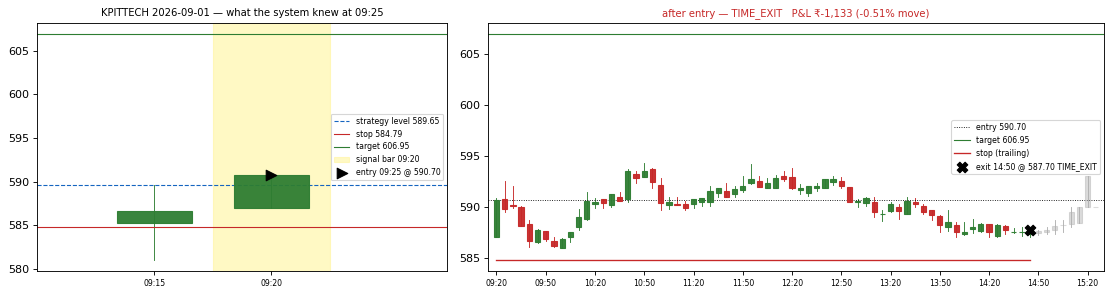


2026-09-02  NETWEB   driver FIRST-CANDLE — FIRST-CANDLE: break above first candle high=5167.50
  signal bar 09:20 | decided on bars up to 09:20 | ENTRY 09:25 @ 5183.50  (strategy level 5167.50, entry +0.31% vs level)
  stop 5131.66 (-1.00%)   target 5329.50 (+2.82%)   RR 1.51   rank 4
  votes: 4 agreeing, score 12.16, predicted win 48.0% — BOLLINGER, CAMARILLA, DAILY-BIAS, FIRST-CANDLE, SUPERTREND
  higher-ranked stocks skipped at this scan: COALINDIA (SKIP price already past stop/target); OIL (SKIP geometry (stop 0.02%, target 0.04%)); NEULANDLAB (FAIL Predicted win pct 50.9% in 50-55% danger zone)
  EXIT 09:55 @ 5131.66 (STOP_HIT)   move -1.00%   P&L ₹-2,088 net (-1.06%) on 38 shares


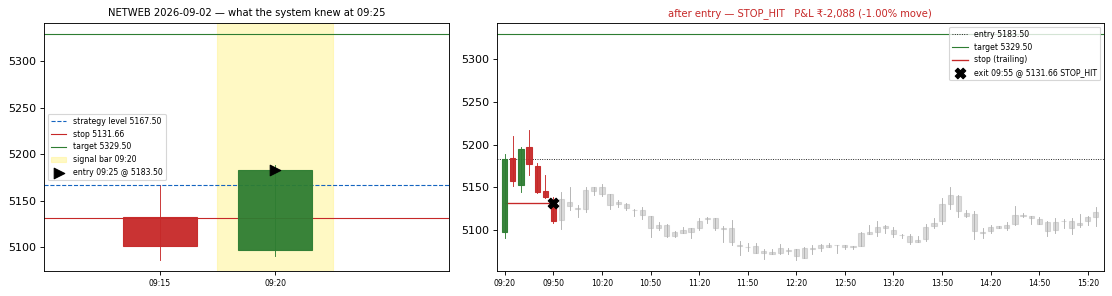


2026-09-03  RBLBANK   driver CAMARILLA — CAMARILLA: breakout above H4=398.69
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 399.30  (strategy level 398.69, entry +0.15% vs level)
  stop 395.31 (-1.00%)   target 417.29 (+4.51%)   RR 3.43   rank 2
  votes: 6 agreeing, score 18.0, predicted win 49.9% — ASC-TRI, CAMARILLA, DAILY-BIAS, GAP-CONT, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: SOLARINDS (FAIL Predicted win pct 50.3% in 50-55% danger zone)
  EXIT 10:15 @ 405.60 (PROFIT_LOCK_STOP)   move +1.58%   P&L ₹+3,029 net (+1.52%) on 500 shares


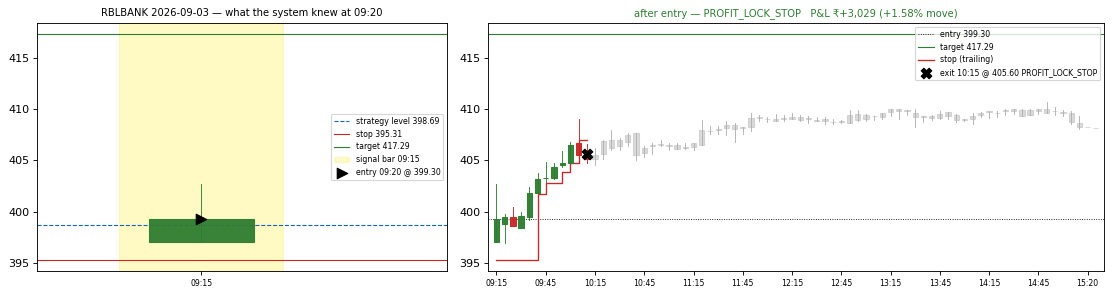


2026-09-04  FLUOROCHEM   driver CAMARILLA — CAMARILLA: breakout above H4=4772.70
  signal bar 09:15 | decided on bars up to 09:20 | ENTRY 09:25 @ 4770.00  (strategy level 4772.70, entry -0.06% vs level)
  stop 4730.35 (-0.83%)   target 4942.10 (+3.61%)   RR 4.34   rank 6
  votes: 6 agreeing, score 18.0, predicted win 49.9% — ADX-FILTER, CAMARILLA, DAILY-BIAS, GAP-CONT, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: ANGELONE (FAIL Predicted win pct 50.2% in 50-55% danger zone); LTF (FAIL Predicted win pct 50.4% in 50-55% danger zone); OFSS (FAIL Predicted win pct 50.2% in 50-55% danger zone); LENSKART (FAIL Predicted win pct 50.3% in 50-55% danger zone)
  EXIT 09:30 @ 4730.35 (STOP_HIT)   move -0.83%   P&L ₹-1,743 net (-0.89%) on 41 shares


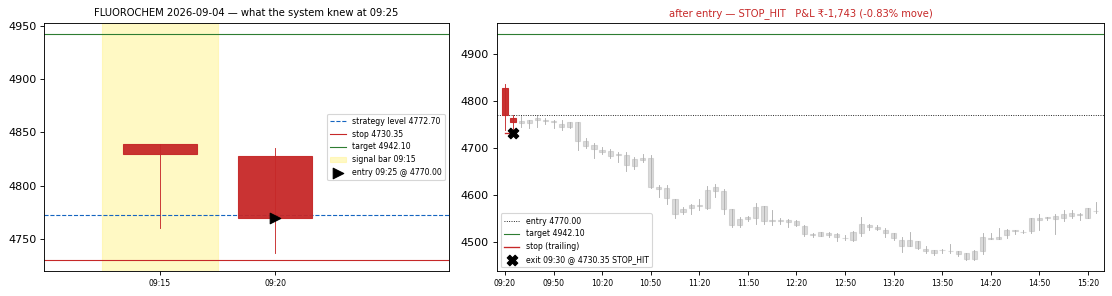


2026-09-07  CARTRADE   driver VPOC — VPOC: breakout above VAH=3040.41
  signal bar 09:20 | decided on bars up to 09:20 | ENTRY 09:25 @ 3048.60  (strategy level 3040.41, entry +0.27% vs level)
  stop 3018.11 (-1.00%)   target 3127.67 (+2.59%)   RR 1.62   rank 14
  votes: 4 agreeing, score 12.0, predicted win 49.9% — CPR, DAILY-BIAS, FIRST-CANDLE, VPOC
  higher-ranked stocks skipped at this scan: COALINDIA (SKIP viability (stop 0.14x ATR < 0.3)); WELSPUNLIV (FAIL Predicted win pct 50.4% in 50-55% danger zone); HFCL (SKIP price already past stop/target); BALRAMCHIN (FAIL Predicted win pct 51.3% in 50-55% danger zone)
  EXIT 09:40 @ 3082.91 (PROFIT_LOCK_STOP)   move +1.12%   P&L ₹+2,110 net (+1.06%) on 65 shares


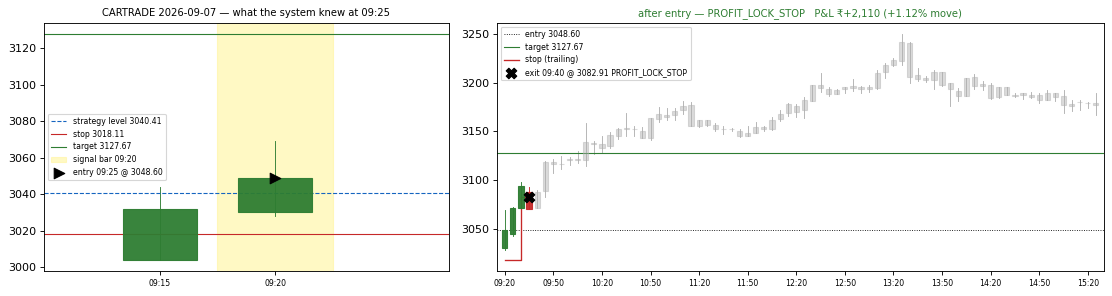


2026-09-08  BANDHANBNK   driver CAMARILLA — CAMARILLA: breakout above H4=166.57
  signal bar 09:20 | decided on bars up to 09:20 | ENTRY 09:25 @ 167.81  (strategy level 166.57, entry +0.74% vs level)
  stop 166.13 (-1.00%)   target 171.62 (+2.27%)   RR 1.52   rank 1
  votes: 8 agreeing, score 21.63, predicted win 49.4% — ADX-FILTER, CAMARILLA, FIRST-CANDLE, GAP-CONT, MACD, PDH-PDL, SUPERTREND, VPOC
  higher-ranked stocks skipped at this scan: none
  EXIT 10:15 @ 171.62 (TARGET_HIT)   move +2.27%   P&L ₹+4,417 net (+2.21%) on 1191 shares


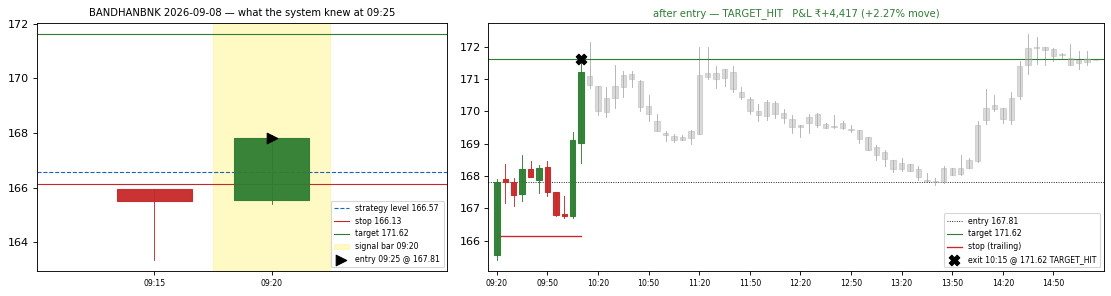


2026-09-09  OIL   driver MACD — MACD: histogram flipped positive, MACD=0.781
  signal bar 09:20 | decided on bars up to 09:20 | ENTRY 09:25 @ 499.70  (strategy level 499.70, entry +0.00% vs level)
  stop 494.70 (-1.00%)   target 512.19 (+2.50%)   RR 1.67   rank 7
  votes: 6 agreeing, score 18.0, predicted win 48.7% — ADX-FILTER, DAILY-BIAS, DBL-BTM, MACD, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: APOLLOHOSP (SKIP price already past stop/target); NAVINFLUOR (FAIL Predicted win pct 50.7% in 50-55% danger zone); PAYTM (FAIL Predicted win pct 51.0% in 50-55% danger zone); GRAPHITE (FAIL Predicted win pct 53.5% in 50-55% danger zone)
  EXIT 14:50 @ 499.30 (TIME_EXIT)   move -0.08%   P&L ₹-280 net (-0.14%) on 400 shares


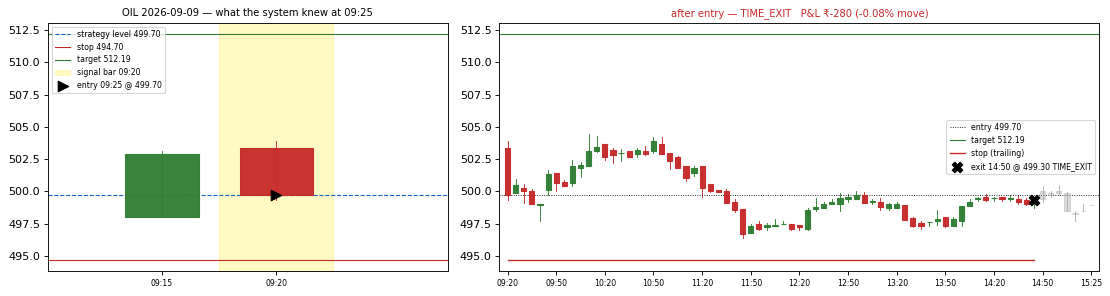


2026-09-10  JINDALSTEL   driver STOCHASTIC — STOCHASTIC: %K=10 crossed above %D from oversold
  signal bar 09:20 | decided on bars up to 09:25 | ENTRY 09:30 @ 1143.90  (strategy level 1144.60, entry -0.06% vs level)
  stop 1132.46 (-1.00%)   target 1173.21 (+2.56%)   RR 1.78   rank 20
  votes: 4 agreeing, score 14.53, predicted win 45.5% — ADX-FILTER, BOLLINGER, DAILY-BIAS, STOCHASTIC, VPOC
  higher-ranked stocks skipped at this scan: FLUOROCHEM (FAIL Predicted win pct 50.7% in 50-55% danger zone); GESHIP (SKIP RR 0.26 < 1.5 at entry price); PWL (FAIL Predicted win pct 50.1% in 50-55% danger zone); TATATECH (SKIP RR 0.07 < 1.5 at entry price)
  EXIT 14:50 @ 1135.40 (TIME_EXIT)   move -0.74%   P&L ₹-1,598 net (-0.80%) on 174 shares


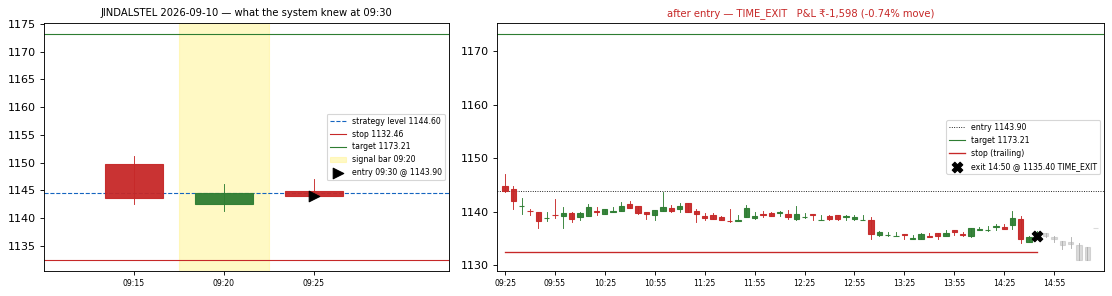


2026-09-11  IDEA   driver FIRST-CANDLE — FIRST-CANDLE: break above first candle high=15.08
  signal bar 09:30 | decided on bars up to 09:30 | ENTRY 09:35 @ 15.12  (strategy level 15.08, entry +0.27% vs level)
  stop 14.97 (-0.99%)   target 15.54 (+2.78%)   RR 1.56   rank 13
  votes: 5 agreeing, score 12.63, predicted win 48.6% — ADX-FILTER, DAILY-BIAS, FIRST-CANDLE, GAP-CONT, SUPERTREND
  higher-ranked stocks skipped at this scan: IDBI (SKIP price already past stop/target); PINELABS (FAIL Predicted win pct 50.2% in 50-55% danger zone); LICHSGFIN (FAIL Predicted win pct 51.1% in 50-55% danger zone); BANDHANBNK (FAIL Predicted win pct 50.1% in 50-55% danger zone)
  EXIT 09:50 @ 14.97 (STOP_HIT)   move -0.99%   P&L ₹-2,103 net (-1.05%) on 13227 shares


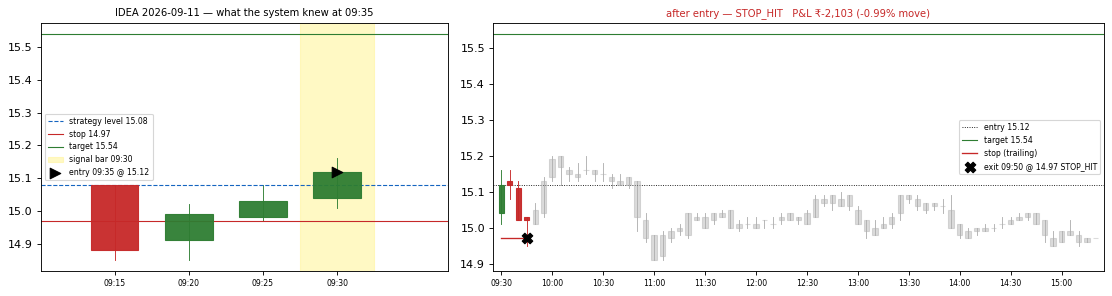


2026-09-15  SAGILITY   driver VPOC — VPOC: breakout above VAH=45.30
  signal bar 09:20 | decided on bars up to 09:20 | ENTRY 09:25 @ 45.83  (strategy level 45.30, entry +1.17% vs level)
  stop 45.37 (-1.00%)   target 46.92 (+2.38%)   RR 1.56   rank 4
  votes: 6 agreeing, score 18.0, predicted win 48.2% — ADX-FILTER, DAILY-BIAS, GAP-CONT, MACD, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: MPHASIS (FAIL Predicted win pct 50.5% in 50-55% danger zone); CYIENT (FAIL Predicted win pct 50.5% in 50-55% danger zone); PIRAMALFIN (SKIP RR 0.84 < 1.5 at entry price)
  EXIT 10:55 @ 46.13 (PROFIT_LOCK_STOP)   move +0.66%   P&L ₹+1,189 net (+0.59%) on 4363 shares


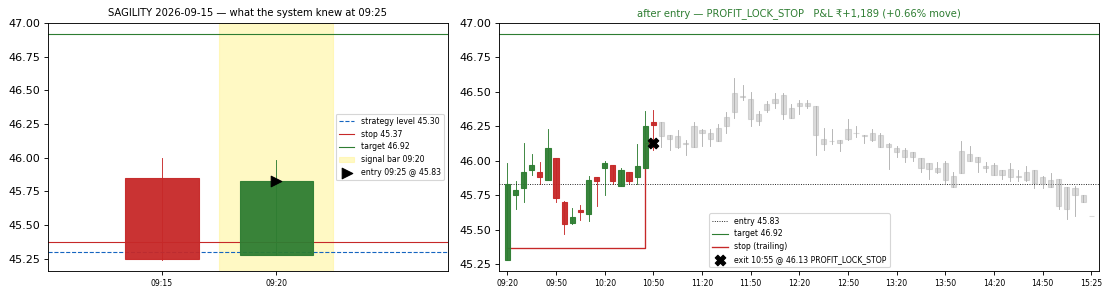


2026-09-16  GODREJCP   driver CAMARILLA — CAMARILLA: breakout above H4=867.92
  signal bar 09:20 | decided on bars up to 09:20 | ENTRY 09:25 @ 868.70  (strategy level 867.92, entry +0.09% vs level)
  stop 862.46 (-0.72%)   target 889.75 (+2.42%)   RR 3.37   rank 6
  votes: 4 agreeing, score 12.0, predicted win 48.3% — ADX-FILTER, CAMARILLA, MACD, SR-BREAK
  higher-ranked stocks skipped at this scan: YESBANK (SKIP RR 0.16 < 1.5 at entry price); FEDERALBNK (FAIL Predicted win pct 50.8% in 50-55% danger zone); PAYTM (SKIP price already past stop/target); WOCKPHARMA (FAIL Only 3 strategy agreed (need 4))
  EXIT 09:45 @ 862.46 (STOP_HIT)   move -0.72%   P&L ₹-1,555 net (-0.78%) on 230 shares


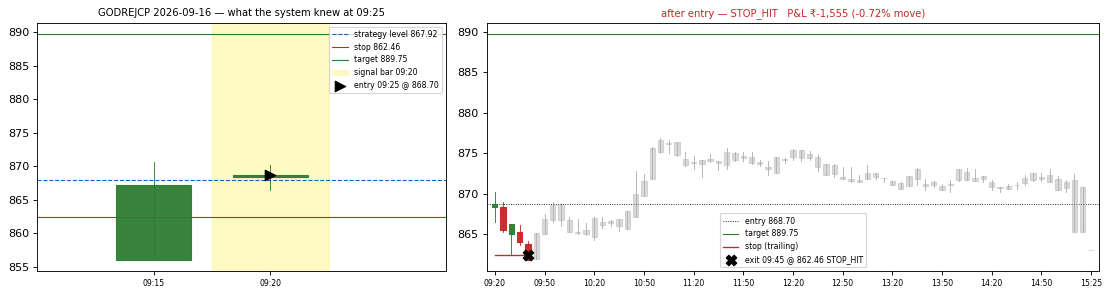


2026-09-17  GESHIP   driver VPOC — VPOC: breakout above VAH=1394.27
  signal bar 09:15 | decided on bars up to 09:15 | ENTRY 09:20 @ 1403.40  (strategy level 1394.27, entry +0.66% vs level)
  stop 1390.24 (-0.94%)   target 1424.31 (+1.49%)   RR 1.59   rank 3
  votes: 5 agreeing, score 15.0, predicted win 49.8% — ADX-FILTER, DAILY-BIAS, DBL-BTM, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: HBLENGINE (FAIL Predicted win pct 50.3% in 50-55% danger zone); SRF (SKIP RR 0.68 < 1.5 at entry price)
  EXIT 13:40 @ 1410.91 (PROFIT_LOCK_STOP)   move +0.54%   P&L ₹+946 net (+0.47%) on 142 shares


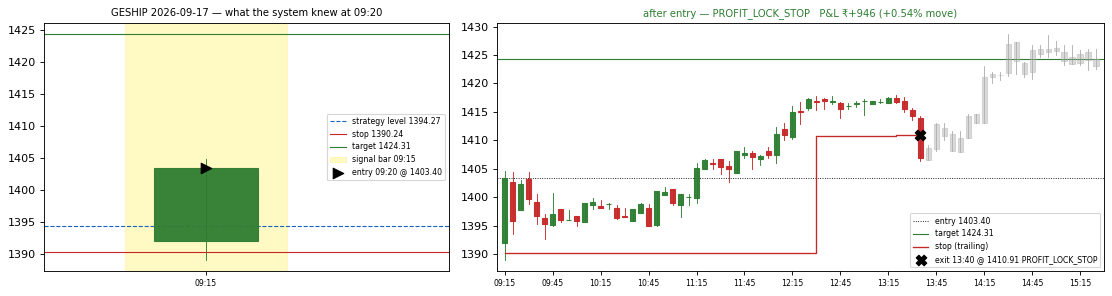


2026-09-18  BEML   driver CAMARILLA — CAMARILLA: breakout above H4=2053.01
  signal bar 09:15 | decided on bars up to 09:25 | ENTRY 09:30 @ 2064.30  (strategy level 2053.01, entry +0.55% vs level)
  stop 2043.66 (-1.00%)   target 2139.03 (+3.62%)   RR 2.28   rank 12
  votes: 6 agreeing, score 18.0, predicted win 49.9% — ADX-FILTER, CAMARILLA, DAILY-BIAS, GAP-CONT, PDH-PDL, VPOC
  higher-ranked stocks skipped at this scan: APARINDS (SKIP RR 1.22 < 1.5 at entry price); MAXHEALTH (SKIP RR 0.51 < 1.5 at entry price); PWL (FAIL Predicted win pct 51.0% in 50-55% danger zone); GVT&D (SKIP viability (stop 0.08x ATR < 0.3))
  EXIT 10:25 @ 2096.00 (PROFIT_LOCK_STOP)   move +1.54%   P&L ₹+2,923 net (+1.48%) on 96 shares


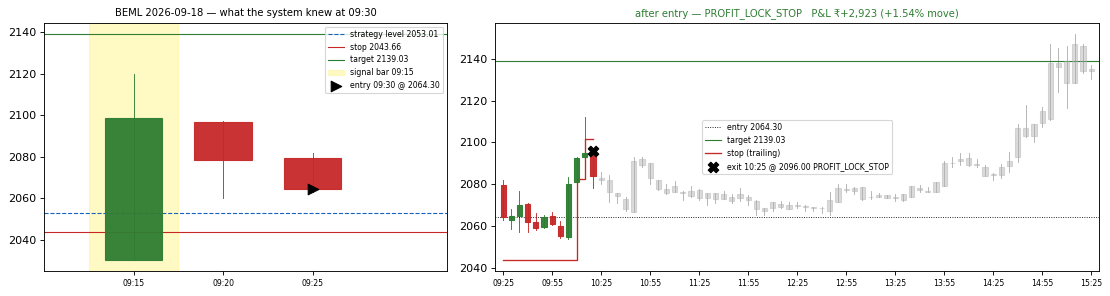

In [13]:
tc.show_month(res, "2026-09")